# **Does US Trade Policy Uncertainty Affect Global Trade? Evidence from the 2018 Trade Shock using a Continuous DiD Analysis**

**Jackie Wang**

**March 13, 2026**

# **Project 1**

## 1.1. Introduction

From the end of the Second World War, the dominant trade policy paradigm was the promotion of free trade. But recently, a strong movement has been pushing for significant changes in trade policies towards protectionism, increasing trade policy uncertainty (TPU). But to what degree does rising TPU impact the behaviour of international trade? And does business confidence, an intuitive explaination for changes in firm behaviour, serve as the mechanism for that change? 

To answer this, I exploit Caldara et al. (2020)'s monthly, US-based trade policy uncertainty index, monthly UN Comtrade bilateral import/export flow data, and the 2018 trade shock, which saw an abnormally high trend of TPU. I employ a lagged linear regression design and a continuous DiD design based on a shift-share variable with a fixed 2013 US-exposure ratio. I find that TPU, while not significantly associated with changes in export and import volumes in the short-run, sees stagnation post-shock, with imports declining by year 1 and exports, after short-run frontloading, by year 2. US-exposure acts as a powerful amplifier of US TPU, but only for export. A continuous DiD design shows that a 10 point increase in US-exposure is associated with a 6.1% decline in exports post-2018 and an insignificant change in imports. 

In analysing business confidence, a mediation analysis finds that including business confidence reduces the magnitude effect by 20% for exports, confirming it as a mechanism, but acts as a suppressor variable for imports, hinting that either imports is not driven by business confidence or that the relationship is more complex than a simple mediation.

This paper contributes to the literature by focusing on the time dynamics of US trade uncertainty shocks and investigating the role of trade proximity to the US as an amplifier of shock spillovers, while also providing evidence on the role of business sentiment on trade uncertainty shocks. Policymakers should consider that their trade proximity to the US, business confidence of domestic firms, and the time dynamics of trade responses are important factors to consider when monitoring US trade policy and managing its effects.

## 1.1.1. Literature Review

Policy uncertainty is consistently found to be associated with worse macroeconomic outcomes. Baker, Bloom, and Davis (2016) established that economic policy uncertainty suppresses investment, output, and employment but with a 4-5 quarter lag, consistent with Lu and Milkov (2026)'s frontloading findings. Subsequent studies confirm that heightened uncertainty lowers domestic and foreign investment (Zhang & Colak, 2022; Caldara et al., 2020) and reduces trade volumes (Tam, 2018; Zhou & Huwei, 2022; Yan et al. 2022; Handley & Limão, 2013) but differ heavily in mechanisms studied: Bloom (2009) suggest that policy uncertainty leads to a wait-and-see approach by firms, halting trade activities due to fears over uncertainty, while Amiti, Redding, and Weinstein (2020) suggests a short-run supply chain inelasticity due to poor substitutability and high sunk-costs. 

This paper contributes to the literature by focusing on the time dynamics of US trade uncertainty shocks and examining the role of trade proximity to the US as an amplifier of shock spillovers, thus exploring the role of trade stickniess in trade shocks, while also evaluating Bloom (2009)'s theory by exploring business sentiment's mediation for uncertainty-induced shocks.

## 1.2. Data Loading/Cleaning

### 1.2.1. Data Loading

For this analysis, I use the cross-country and bilaterla UN Comtrade bilateral trade data to represent trade behaviour.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display
from linearmodels.panel import PanelOLS
import numpy as np
import pandas as pd
from stargazer.stargazer import Stargazer
import warnings
import geopandas as gpd

# Suppress PanelOLS warnings
warnings.filterwarnings('ignore')


In [2]:
comtrade_exports = pd.read_parquet("C:/Users/ja200/OneDrive/Comtrade_Data/master_exports_2000_2026.parquet", dtype_backend='pyarrow')
comtrade_imports = pd.read_parquet("C:/Users/ja200/OneDrive/Comtrade_Data/master_imports_2000_2026.parquet", dtype_backend='pyarrow')
tpu_data = pd.read_csv("C:/Users/ja200/OneDrive/Comtrade_Data/tpu_web_latest.csv")

#change date format in TPU data
tpu_data['DATE'] = pd.to_datetime(tpu_data['DATE'], format='%Y-%m-%d')
comtrade_exports['date'] = pd.to_datetime(comtrade_exports['date'])

#convert comtrade imports date to datetime
comtrade_exports['date'] = pd.to_datetime(comtrade_exports['date'].to_numpy())
comtrade_imports['date'] = pd.to_datetime(comtrade_imports['date'].to_numpy())

#ensure both dates are at the monthly frequency
tpu_data['DATE'] = tpu_data['DATE'].dt.to_period('M').dt.to_timestamp()
comtrade_exports['date'] = comtrade_exports['date'].dt.to_period('M').dt.to_timestamp()

#set the indexes
tpu_data_indexed = tpu_data.set_index('DATE')
comtrade_exports_indexed = comtrade_exports.set_index("date")
comtrade_imports_indexed = comtrade_imports.set_index("date")

tpu_exports = pd.merge(
    tpu_data_indexed, 
    comtrade_exports_indexed, 
    left_index=True, 
    right_index=True, 
    validate='one_to_many', 
    how="right")

tpu_imports = pd.merge(
    tpu_data_indexed, 
    comtrade_imports_indexed, 
    left_index=True, 
    right_index=True, 
    validate='one_to_many', 
    how="right")

### 1.2.2. Other Datasets

I use Caldara et al. (2020)'s Trade Policy Uncertainty Index to represent TPU, and OECD's Business Confidence Index (BCI) to represent business confidence, our mechanism variable. I also use World Bank GDP data and FRED's nominal effective exchange rate (NEER) data as controls, as both variables are known to impact trade and investment behaviour.

In [3]:
#ensure both dates are at the monthly frequency
tpu_data['DATE'] = tpu_data['DATE'].dt.to_period('M').dt.to_timestamp()
comtrade_exports['date'] = comtrade_exports['date'].dt.to_period('M').dt.to_timestamp()

#set the indexes
tpu_data_indexed = tpu_data.set_index('DATE')
comtrade_exports_indexed = comtrade_exports.set_index("date")
comtrade_imports_indexed = comtrade_imports.set_index("date")

tpu_exports = pd.merge(
    tpu_data_indexed, 
    comtrade_exports_indexed, 
    left_index=True, 
    right_index=True, 
    validate='one_to_many', 
    how="right")

tpu_imports = pd.merge(
    tpu_data_indexed, 
    comtrade_imports_indexed, 
    left_index=True, 
    right_index=True, 
    validate='one_to_many', 
    how="right")

In [4]:
iso3_lookup = pd.read_csv('C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/Projects/economics-quantitative-paper/UNSD_methodology.csv', sep=';')

iso3_alpha2_dict = pd.Series(
    iso3_lookup['ISO-alpha2 Code'].values, 
    index=pd.to_numeric(iso3_lookup['M49 Code'], errors='coerce')
).dropna().to_dict()

iso_alpha3_dict = pd.Series(
    iso3_lookup['ISO-alpha3 Code'].values, 
    index=pd.to_numeric(iso3_lookup['M49 Code'], errors='coerce')
).dropna().to_dict()

#manually add missing mappings for key countries
manual_iso2 = {
    842: 'US', # USA (Comtrade specific)
    840: 'US', # USA (Standard M49)
    251: 'FR', # France
    826: 'GB', # United Kingdom
    276: 'DE', # Germany
    380: 'IT', # Italy
    124: 'CA'  # Canada
}

manual_iso3 = {
    842: 'USA', 840: 'USA', 251: 'FRA', 826: 'GBR', 276: 'DEU', 380: 'ITA', 124: 'CAN'
}
iso3_alpha2_dict.update(manual_iso2)
iso_alpha3_dict.update(manual_iso3)

tpu_exports['iso2reporter'] = tpu_exports['reporterCode'].map(iso3_alpha2_dict)
tpu_exports['iso2partner'] = tpu_exports['partnerCode'].map(iso3_alpha2_dict)


for df in [tpu_exports, tpu_imports]:
    df['reporterCode'] = pd.to_numeric(df['reporterCode'], errors='coerce')
    df['partnerCode'] = pd.to_numeric(df['partnerCode'], errors='coerce')
    
    # Perform the mapping
    df['iso2reporter'] = df['reporterCode'].map(iso3_alpha2_dict)
    df['iso2partner'] = df['partnerCode'].map(iso3_alpha2_dict)
    
    # MANUAL OVERRIDE
    df.loc[df['reporterCode'] == 251, 'iso2reporter'] = 'FR'
    df.loc[df['partnerCode'] == 842, 'iso2partner'] = 'US'
    df.loc[df['partnerCode'] == 251, 'iso2partner'] = 'FR'

#add iso3 codes as well
tpu_exports['iso3reporter'] = tpu_exports['reporterCode'].map(iso_alpha3_dict)
tpu_exports['iso3partner'] = tpu_exports['partnerCode'].map(iso_alpha3_dict)
tpu_imports['iso3reporter'] = tpu_imports['reporterCode'].map(iso_alpha3_dict)
tpu_imports['iso3partner'] = tpu_imports['partnerCode'].map(iso_alpha3_dict)

#read in bci data
bci_data = pd.read_csv("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/Projects/economics-quantitative-paper/oecd_bci_data.csv")

#convert date to datetime
bci_data["TIME_PERIOD"] = pd.to_datetime(bci_data["TIME_PERIOD"], format="%Y-%m")

#filter for only needed columns for merging
bci_data = bci_data[['REF_AREA', 'TIME_PERIOD', 'bci']].copy()

#reset index to prepare for merging
tpu_exports = tpu_exports.reset_index()
tpu_imports = tpu_imports.reset_index()

#convert pyarrow datetime to pandas datetime for merging
tpu_exports['DATE'] = pd.to_datetime(tpu_exports['DATE'])
tpu_imports['DATE'] = pd.to_datetime(tpu_imports['DATE'])

#merge bci data with exports and imports dataframes based on country and date
tpu_exports = pd.merge(
    tpu_exports, bci_data, 
    left_on=['iso3reporter', "DATE"],
    right_on=['REF_AREA', "TIME_PERIOD"],
    how='left'
).rename(columns={'bci': 'bci_reporter'})

tpu_exports = pd.merge(
    tpu_exports, bci_data,
    left_on=['iso3partner', "DATE"],
    right_on=['REF_AREA', 'TIME_PERIOD'],
    how='left', suffixes=('', '_partner')
).rename(columns={'bci': 'bci_partner'})

tpu_imports = pd.merge(
    tpu_imports, bci_data,
    left_on=['iso3reporter', "DATE"],
    right_on=['REF_AREA', "TIME_PERIOD"],
    how='left'
).rename(columns={'bci': 'bci_reporter'})

tpu_imports = pd.merge(
    tpu_imports, bci_data,
    left_on=['iso3partner', "DATE"],
    right_on=['REF_AREA', "TIME_PERIOD"],
    how='left', suffixes=('', '_partner')
).rename(columns={'bci': 'bci_partner'})

#set index back to date
tpu_exports.set_index('DATE', inplace=True)
tpu_imports.set_index('DATE', inplace=True)

I use interpolation to smooth the annual GDP for monthly trade flows. Monthly GDP is not used as it is unreliable.


In [5]:
annual_gdp = pd.read_csv("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/Projects/economics-quantitative-paper/worldbank_annual_gdp.csv")

#clean gdp data

#remove rows with "trade value" in the "Country Name" column
annual_gdp = annual_gdp[~annual_gdp['Country Name'].str.contains('Trade_flows', na=False)]

#replace '..' with NaN
annual_gdp = annual_gdp.replace('..', np.nan)

#convert gdp column to numeric
gdp_col = 'GDP (current US$) [NY.GDP.MKTP.CD]'
annual_gdp[gdp_col] = pd.to_numeric(annual_gdp[gdp_col], errors='coerce')

#drop rows with missing gdp values
annual_gdp = annual_gdp.dropna(subset=[gdp_col])

# 1. Create a date index for your annual GDP
annual_gdp['date'] = pd.to_datetime(annual_gdp['Time'].astype(int).astype(str) + '-07-01') #mid-year point

# 4. Get the list of unique countries in your GDP data
countries = annual_gdp['Country Code'].unique()

from scipy.interpolate import interp1d

# Define your GDP column name from the World Bank file
gdp_col = 'GDP (current US$) [NY.GDP.MKTP.CD]'

# Initialize columns
tpu_exports['gdp_reporter_monthly'] = np.nan
tpu_exports['gdp_partner_monthly'] = np.nan

# Get unique country codes from your GDP data
countries = annual_gdp['Country Code'].unique()

for iso3 in countries:
    # 1. Filter and Sort GDP data for this specific country
    country_gdp = annual_gdp[annual_gdp['Country Code'] == iso3].sort_values('date')
    
    # Need at least 3 points for a cubic spline
    if len(country_gdp) < 3:
        continue
        
    # 2. Create the interpolation function
    # UPDATED: Use .astype(np.int64) to avoid deprecation warning
    f = interp1d(
        country_gdp['date'].astype(np.int64), 
        country_gdp[gdp_col], 
        kind='cubic', 
        fill_value="extrapolate"
    )
    
    # 3. INTERPOLATE FOR REPORTER (Exporter)
    rep_mask = tpu_exports['iso3reporter'] == iso3
    if rep_mask.any():
        # UPDATED: Accessing index and casting to int64 safely
        trade_x_rep = tpu_exports.index[rep_mask].astype(np.int64)
        tpu_exports.loc[rep_mask, 'gdp_reporter_monthly'] = f(trade_x_rep)
        
    # 4. INTERPOLATE FOR PARTNER (Importer)
    part_mask = tpu_exports['iso3partner'] == iso3
    if part_mask.any():
        # UPDATED: Accessing index and casting to int64 safely
        trade_x_part = tpu_exports.index[part_mask].astype(np.int64)
        tpu_exports.loc[part_mask, 'gdp_partner_monthly'] = f(trade_x_part)

#repeat for imports dataframe

tpu_imports['gdp_reporter_monthly'] = np.nan
tpu_imports['gdp_partner_monthly'] = np.nan

for iso3 in countries:
    # 1. Filter and Sort GDP data for this specific country
    country_gdp = annual_gdp[annual_gdp['Country Code'] == iso3].sort_values('date')
    
    # Need at least 3 points for a cubic spline
    if len(country_gdp) < 3:
        continue
        
    # 2. Create the interpolation function
    f = interp1d(
        country_gdp['date'].astype(np.int64), 
        country_gdp[gdp_col], 
        kind='cubic', 
        fill_value="extrapolate"
    )
    
    # 3. INTERPOLATE FOR REPORTER (Exporter)
    rep_mask = tpu_imports['iso3reporter'] == iso3
    if rep_mask.any():
        trade_x_rep = tpu_imports.index[rep_mask].astype(np.int64)
        tpu_imports.loc[rep_mask, 'gdp_reporter_monthly'] = f(trade_x_rep)
        
    # 4. INTERPOLATE FOR PARTNER (Importer)
    part_mask = tpu_imports['iso3partner'] == iso3
    if part_mask.any():
        trade_x_part = tpu_imports.index[part_mask].astype(np.int64)
        tpu_imports.loc[part_mask, 'gdp_partner_monthly'] = f(trade_x_part)
        


In [6]:
#merge currency data with exports and imports dataframes; merge exchange rates both for reporter and partner countries based on ISO2 codes plus date

currency_data = pd.read_csv("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/Projects/economics-quantitative-paper/fred_currency_data_rebased.csv")
currency_data['DATE'] = pd.to_datetime(currency_data['date'])

#exports merge
tpu_exports_final = pd.merge(
    tpu_exports, currency_data,
    left_on=['iso2reporter', 'DATE'], 
    right_on=['iso2', 'DATE'],       
    how='left'
).rename(columns={'neer_rebased': 'neer_reporter', 'neer_raw': 'neer_raw_reporter'})

tpu_exports = pd.merge(
    tpu_exports_final, currency_data,
    left_on=['iso2partner', 'DATE'], 
    right_on=['iso2', 'DATE'],        
    how='left', suffixes=('', '_partner')
).rename(columns={'neer_rebased': 'neer_partner', 'neer_raw': 'neer_raw_partner'})


#imports merge
tpu_imports_final = pd.merge(
    tpu_imports, currency_data,
    left_on=['iso2reporter', 'DATE'], right_on=['iso2', 'DATE'],
    how='left'
).rename(columns={'neer_rebased': 'neer_reporter', 'neer_raw': 'neer_raw_reporter'})

tpu_imports = pd.merge(
    tpu_imports_final, currency_data,
    left_on=['iso2partner', 'DATE'], right_on=['iso2', 'DATE'],
    how='left', suffixes=('', '_partner')
).rename(columns={'neer_rebased': 'neer_partner', 'neer_raw': 'neer_raw_partner'})

#reindex dataframes by date
tpu_exports.set_index('DATE', inplace=True)
tpu_imports.set_index('DATE', inplace=True)

### 1.2.3. Data Cleaning

In [7]:
tpu_exports_for_missingness = tpu_exports.copy()
bci_data_for_missingness = bci_data.copy()

# Calculate missing observations percentage by country
tpu_reporter_counts = tpu_exports_for_missingness['iso3reporter'].value_counts().reset_index()
tpu_reporter_counts.columns = ['iso3', 'tpu_obs']

bci_counts = bci_data_for_missingness['REF_AREA'].value_counts().reset_index()
bci_counts.columns = ['iso3', 'bci_obs']


In [8]:
#drop cyprus and malta due to significant missing BCI data
tpu_exports = tpu_exports[~tpu_exports["iso3reporter"].isin(["CYP", "MLT","HRV"])]
tpu_exports = tpu_exports[~tpu_exports["iso3partner"].isin(["CYP", "MLT","HRV"])]
tpu_imports = tpu_imports[~tpu_imports["iso3reporter"].isin(["CYP", "MLT","HRV"])]
tpu_imports = tpu_imports[~tpu_imports["iso3partner"].isin(["CYP", "MLT","HRV"])]

#drop EU28 and other aggregated regions without iso3 codes
tpu_exports = tpu_exports[~tpu_exports["iso3reporter"].isin(["EU28",
"EU27_2020", "EA19"])]
tpu_exports = tpu_exports[~tpu_exports["iso3partner"].isin(["EU28",
"EU27_2020", "EA19"])]
tpu_imports = tpu_imports[~tpu_imports["iso3reporter"].isin(["EU28",
"EU27_2020", "EA19"])]
tpu_imports = tpu_imports[~tpu_imports["iso3partner"].isin(["EU28",
"EU27_2020", "EA19"])]

#drop remaining NaN values in key columns only (avoid dropping entire rows due to unused columns)
def dropna_existing(df, required_cols):
    available_cols = [col for col in required_cols if col in df.columns]
    return df.dropna(subset=available_cols)

tpu_exports = dropna_existing(
    tpu_exports,
    [
        "trade_value_usd", "TPU", "bci_reporter", "bci_partner",
        "gdp_reporter_monthly", "gdp_partner_monthly", "neer_reporter", "neer_partner",
        "iso3reporter", "iso3partner"
    ]
)
tpu_imports = dropna_existing(
    tpu_imports,
    [
        "trade_value_usd", "TPU", "bci_reporter", "bci_partner",
        "gdp_reporter_monthly", "gdp_partner_monthly", "neer_reporter", "neer_partner",
        "iso3reporter", "iso3partner"
    ]
)

#we have removed and accounted for missing values needed for analysis

In [9]:
#remove zero or negative values to avoid issues with log transformations
tpu_exports = tpu_exports[(tpu_exports['gdp_reporter_monthly'] > 0) & (tpu_exports['gdp_partner_monthly'] > 0)]
tpu_imports = tpu_imports[(tpu_imports['gdp_reporter_monthly'] > 0) & (tpu_imports['gdp_partner_monthly'] > 0)]

#set gdp to ln(gdp)
tpu_exports['ln_gdp_reporter'] = np.log(tpu_exports['gdp_reporter_monthly'])
tpu_exports['ln_gdp_partner'] = np.log(tpu_exports['gdp_partner_monthly'])
tpu_imports['ln_gdp_reporter'] = np.log(tpu_imports['gdp_reporter_monthly'])
tpu_imports['ln_gdp_partner'] = np.log(tpu_imports['gdp_partner_monthly'])

#we also log TPU amounts for regression analysis using the arcsinh transformation to handle zero values
tpu_exports['ln_TPU'] = np.arcsinh(tpu_exports['TPU'])
tpu_imports['ln_TPU'] = np.arcsinh(tpu_imports['TPU'])

#take the log of trade value
tpu_exports["log_trade_value_usd"] = np.log(tpu_exports["trade_value_usd"])
tpu_imports["log_trade_value_usd"] = np.log(tpu_imports["trade_value_usd"])

#take the log of TPU values
tpu_exports["ln_TPU"] = np.log(tpu_exports["TPU"])
tpu_imports["ln_TPU"] = np.log(tpu_imports["TPU"])

#take the log of bci values
tpu_exports["ln_bci_reporter"] = np.log(tpu_exports["bci_reporter"])
tpu_exports["ln_bci_partner"] = np.log(tpu_exports["bci_partner"])
tpu_imports["ln_bci_reporter"] = np.log(tpu_imports["bci_reporter"])
tpu_imports["ln_bci_partner"] = np.log(tpu_imports["bci_partner"])

To support my analysis, I create a US-exposure ratio to evaluate the "closeness" of a country to the US in terms of trade, defined as the average of both bilaterial partners' share of trade with the US. I hold the ratio constant at 2013 to avoid bias.

In [10]:
#create post-2018 shock variable for both trade and FDI datasets

# Handle both DatetimeIndex and regular index cases for tpu_exports and tpu_imports
if hasattr(tpu_exports.index, 'year'):
    tpu_exports["Year"] = tpu_exports.index.year
    tpu_imports["Year"] = tpu_imports.index.year
else:
    tpu_exports["Year"] = tpu_exports.index.to_series().dt.year if hasattr(tpu_exports.index, 'to_series') else pd.to_datetime(tpu_exports.index).year
    tpu_imports["Year"] = tpu_imports.index.to_series().dt.year if hasattr(tpu_imports.index, 'to_series') else pd.to_datetime(tpu_imports.index).year

# Create monthly period variable as a simple numeric YearMonth for time fixed effects
tpu_exports['YearMonth'] = tpu_exports.index.year * 100 + tpu_exports.index.month
tpu_imports['YearMonth'] = tpu_imports.index.year * 100 + tpu_imports.index.month

tpu_exports["Post_2018_Shock"] = (tpu_exports["Year"] >= 2018).astype(int)
tpu_imports["Post_2018_Shock"] = (tpu_imports["Year"] >= 2018).astype(int)

#next, we create our US proximity variable
#for this, we create a function that adds the fraction of US trade to total trade for both countries in the pair

#Calculate US trade exposure for exports (monthly data)
tpu_exports_reset = tpu_exports.reset_index()
us_trade_exports = (
    tpu_exports_reset.groupby(["iso3reporter", "iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
)
us_trade_exports = us_trade_exports.rename(columns={"trade_value_usd": "pair_trade"})

# Calculate total trade for each country (reporter and partner) by month
reporter_total_exports = (
    tpu_exports_reset.groupby(["iso3reporter", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "reporter_total_trade"})
)
partner_total_exports = (
    tpu_exports_reset.groupby(["iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "partner_total_trade"})
)

# Calculate US trade for reporter and partner
us_trade_reporter_exports = (
    tpu_exports_reset[tpu_exports_reset["iso3partner"] == "USA"]
    .groupby(["iso3reporter", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "us_trade_reporter"})
)
us_trade_partner_exports = (
    tpu_exports_reset[tpu_exports_reset["iso3reporter"] == "USA"]
    .groupby(["iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "us_trade_partner"})
)

# Merge and calculate exposure
tpu_exports_temp = tpu_exports_reset[["iso3reporter", "iso3partner", "DATE", "Year"]]
tpu_exports_temp = tpu_exports_temp.merge(reporter_total_exports, on=["iso3reporter", "DATE"], how="left")
tpu_exports_temp = tpu_exports_temp.merge(partner_total_exports, on=["iso3partner", "DATE"], how="left")
tpu_exports_temp = tpu_exports_temp.merge(us_trade_reporter_exports, on=["iso3reporter", "DATE"], how="left")
tpu_exports_temp = tpu_exports_temp.merge(us_trade_partner_exports, on=["iso3partner", "DATE"], how="left")

tpu_exports_temp["us_trade_reporter"] = tpu_exports_temp["us_trade_reporter"].fillna(0)
tpu_exports_temp["us_trade_partner"] = tpu_exports_temp["us_trade_partner"].fillna(0)

# Calculate US exposure as pre-2018 average (constant per pair)
pre_2018_exports = tpu_exports_temp[tpu_exports_temp["Year"] < 2018].copy()
# Use absolute values to measure volume, not net flows
pre_2018_exports["us_ratio_reporter"] = pre_2018_exports["us_trade_reporter"].abs() / pre_2018_exports["reporter_total_trade"].abs()
pre_2018_exports["us_ratio_partner"] = pre_2018_exports["us_trade_partner"].abs() / pre_2018_exports["partner_total_trade"].abs()
pre_2018_exports["us_exposure_temp"] = (pre_2018_exports["us_ratio_reporter"] + pre_2018_exports["us_ratio_partner"]) / 2

# Average by pair (constant value)
us_exposure_exports_pair = pre_2018_exports.groupby(["iso3reporter", "iso3partner"])["us_exposure_temp"].mean().reset_index()
us_exposure_exports_pair = us_exposure_exports_pair.rename(columns={"us_exposure_temp": "us_exposure"})

# Build 2013-locked exposure (constant per pair)
base_2013_exports = tpu_exports_temp[tpu_exports_temp["Year"] == 2013].copy()
base_2013_exports["us_ratio_reporter"] = base_2013_exports["us_trade_reporter"].abs() / base_2013_exports["reporter_total_trade"].abs()
base_2013_exports["us_ratio_partner"] = base_2013_exports["us_trade_partner"].abs() / base_2013_exports["partner_total_trade"].abs()
base_2013_exports["us_exposure_temp"] = (base_2013_exports["us_ratio_reporter"] + base_2013_exports["us_ratio_partner"]) / 2

us_exposure_exports_pair_2013 = base_2013_exports.groupby(["iso3reporter", "iso3partner"])["us_exposure_temp"].mean().reset_index()
us_exposure_exports_pair_2013 = us_exposure_exports_pair_2013.rename(columns={"us_exposure_temp": "us_exposure_2013"})

# Merge both exposure definitions into temp dataframe
tpu_exports_temp = tpu_exports_temp.merge(
    us_exposure_exports_pair,
    on=["iso3reporter", "iso3partner"],
    how="left"
)
tpu_exports_temp = tpu_exports_temp.merge(
    us_exposure_exports_pair_2013,
    on=["iso3reporter", "iso3partner"],
    how="left"
)

tpu_exports = tpu_exports_reset.merge(
    tpu_exports_temp[["iso3reporter", "iso3partner", "DATE", "us_exposure", "us_exposure_2013"]],
    on=["iso3reporter", "iso3partner", "DATE"],
    how="left"
).set_index("DATE")

# Repeat for imports
tpu_imports_reset = tpu_imports.reset_index()
us_trade_imports = (
    tpu_imports_reset.groupby(["iso3reporter", "iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
)
us_trade_imports = us_trade_imports.rename(columns={"trade_value_usd": "pair_trade"})

reporter_total_imports = (
    tpu_imports_reset.groupby(["iso3reporter", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "reporter_total_trade"})
)
partner_total_imports = (
    tpu_imports_reset.groupby(["iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "partner_total_trade"})
)

us_trade_reporter_imports = (
    tpu_imports_reset[tpu_imports_reset["iso3partner"] == "USA"]
    .groupby(["iso3reporter", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "us_trade_reporter"})
)
us_trade_partner_imports = (
    tpu_imports_reset[tpu_imports_reset["iso3reporter"] == "USA"]
    .groupby(["iso3partner", "DATE"])["trade_value_usd"]
    .sum()
    .reset_index()
    .rename(columns={"trade_value_usd": "us_trade_partner"})
)

tpu_imports_temp = tpu_imports_reset[["iso3reporter", "iso3partner", "DATE", "Year"]]
tpu_imports_temp = tpu_imports_temp.merge(reporter_total_imports, on=["iso3reporter", "DATE"], how="left")
tpu_imports_temp = tpu_imports_temp.merge(partner_total_imports, on=["iso3partner", "DATE"], how="left")
tpu_imports_temp = tpu_imports_temp.merge(us_trade_reporter_imports, on=["iso3reporter", "DATE"], how="left")
tpu_imports_temp = tpu_imports_temp.merge(us_trade_partner_imports, on=["iso3partner", "DATE"], how="left")

tpu_imports_temp["us_trade_reporter"] = tpu_imports_temp["us_trade_reporter"].fillna(0)
tpu_imports_temp["us_trade_partner"] = tpu_imports_temp["us_trade_partner"].fillna(0)

# Calculate US exposure as pre-2018 average (constant per pair)
pre_2018_imports = tpu_imports_temp[tpu_imports_temp["Year"] < 2018].copy()
# Use absolute values to measure volume, not net flows
pre_2018_imports["us_ratio_reporter"] = pre_2018_imports["us_trade_reporter"].abs() / pre_2018_imports["reporter_total_trade"].abs()
pre_2018_imports["us_ratio_partner"] = pre_2018_imports["us_trade_partner"].abs() / pre_2018_imports["partner_total_trade"].abs()
pre_2018_imports["us_exposure_temp"] = (pre_2018_imports["us_ratio_reporter"] + pre_2018_imports["us_ratio_partner"]) / 2

# Average by pair (constant value)
us_exposure_imports_pair = pre_2018_imports.groupby(["iso3reporter", "iso3partner"])["us_exposure_temp"].mean().reset_index()
us_exposure_imports_pair = us_exposure_imports_pair.rename(columns={"us_exposure_temp": "us_exposure"})

# Build 2013-locked exposure (constant per pair)
base_2013_imports = tpu_imports_temp[tpu_imports_temp["Year"] == 2013].copy()
base_2013_imports["us_ratio_reporter"] = base_2013_imports["us_trade_reporter"].abs() / base_2013_imports["reporter_total_trade"].abs()
base_2013_imports["us_ratio_partner"] = base_2013_imports["us_trade_partner"].abs() / base_2013_imports["partner_total_trade"].abs()
base_2013_imports["us_exposure_temp"] = (base_2013_imports["us_ratio_reporter"] + base_2013_imports["us_ratio_partner"]) / 2

us_exposure_imports_pair_2013 = base_2013_imports.groupby(["iso3reporter", "iso3partner"])["us_exposure_temp"].mean().reset_index()
us_exposure_imports_pair_2013 = us_exposure_imports_pair_2013.rename(columns={"us_exposure_temp": "us_exposure_2013"})

# Merge both exposure definitions into temp dataframe
tpu_imports_temp = tpu_imports_temp.merge(
    us_exposure_imports_pair,
    on=["iso3reporter", "iso3partner"],
    how="left"
)
tpu_imports_temp = tpu_imports_temp.merge(
    us_exposure_imports_pair_2013,
    on=["iso3reporter", "iso3partner"],
    how="left"
)

tpu_imports = tpu_imports_reset.merge(
    tpu_imports_temp[["iso3reporter", "iso3partner", "DATE", "us_exposure", "us_exposure_2013"]],
    on=["iso3reporter", "iso3partner", "DATE"],
    how="left"
).set_index("DATE")

#fill any remaining missing US exposure values with 0 (for pairs with no pre-2018 trade with US)
tpu_exports['us_exposure'] = tpu_exports['us_exposure'].fillna(0)
tpu_imports['us_exposure'] = tpu_imports['us_exposure'].fillna(0)
tpu_exports['us_exposure_2013'] = tpu_exports['us_exposure_2013'].fillna(tpu_exports['us_exposure'])
tpu_imports['us_exposure_2013'] = tpu_imports['us_exposure_2013'].fillna(tpu_imports['us_exposure'])

#create lagged interactions for both exposure definitions
tpu_exports['ln_TPU_x_us_exp'] = tpu_exports['ln_TPU'] * tpu_exports['us_exposure']
tpu_imports['ln_TPU_x_us_exp'] = tpu_imports['ln_TPU'] * tpu_imports['us_exposure']
tpu_exports['ln_TPU_x_us_exp_2013'] = tpu_exports['ln_TPU'] * tpu_exports['us_exposure_2013']
tpu_imports['ln_TPU_x_us_exp_2013'] = tpu_imports['ln_TPU'] * tpu_imports['us_exposure_2013']

# Create ln_neer variables for exports and imports first
tpu_exports['ln_neer_reporter'] = np.log(tpu_exports['neer_reporter'].clip(lower=1e-9))
tpu_exports['ln_neer_partner'] = np.log(tpu_exports['neer_partner'].clip(lower=1e-9))
tpu_imports['ln_neer_reporter'] = np.log(tpu_imports['neer_reporter'].clip(lower=1e-9))
tpu_imports['ln_neer_partner'] = np.log(tpu_imports['neer_partner'].clip(lower=1e-9))

# Create demeaned and standardized GDP and NEER variables for exports
tpu_exports['gdp_reporter_demean'] = tpu_exports.groupby('iso3reporter')['ln_gdp_reporter'].transform(lambda x: x - x.mean())
tpu_exports['gdp_partner_demean'] = tpu_exports.groupby('iso3partner')['ln_gdp_partner'].transform(lambda x: x - x.mean())
tpu_exports['neer_reporter_demean'] = tpu_exports.groupby('iso3reporter')['ln_neer_reporter'].transform(lambda x: x - x.mean())
tpu_exports['neer_partner_demean'] = tpu_exports.groupby('iso3partner')['ln_neer_partner'].transform(lambda x: x - x.mean())

tpu_exports['gdp_reporter_std'] = tpu_exports.groupby('iso3reporter')['gdp_reporter_demean'].transform(lambda x: x / x.std())
tpu_exports['gdp_partner_std'] = tpu_exports.groupby('iso3partner')['gdp_partner_demean'].transform(lambda x: x / x.std())
tpu_exports['neer_reporter_std'] = tpu_exports.groupby('iso3reporter')['neer_reporter_demean'].transform(lambda x: x / x.std())
tpu_exports['neer_partner_std'] = tpu_exports.groupby('iso3partner')['neer_partner_demean'].transform(lambda x: x / x.std())

# Create demeaned and standardized GDP and NEER variables for imports
tpu_imports['gdp_reporter_demean'] = tpu_imports.groupby('iso3reporter')['ln_gdp_reporter'].transform(lambda x: x - x.mean())
tpu_imports['gdp_partner_demean'] = tpu_imports.groupby('iso3partner')['ln_gdp_partner'].transform(lambda x: x - x.mean())
tpu_imports['neer_reporter_demean'] = tpu_imports.groupby('iso3reporter')['ln_neer_reporter'].transform(lambda x: x - x.mean())
tpu_imports['neer_partner_demean'] = tpu_imports.groupby('iso3partner')['ln_neer_partner'].transform(lambda x: x - x.mean())

tpu_imports['gdp_reporter_std'] = tpu_imports.groupby('iso3reporter')['gdp_reporter_demean'].transform(lambda x: x / x.std())
tpu_imports['gdp_partner_std'] = tpu_imports.groupby('iso3partner')['gdp_partner_demean'].transform(lambda x: x / x.std())
tpu_imports['neer_reporter_std'] = tpu_imports.groupby('iso3reporter')['neer_reporter_demean'].transform(lambda x: x / x.std())
tpu_imports['neer_partner_std'] = tpu_imports.groupby('iso3partner')['neer_partner_demean'].transform(lambda x: x / x.std())

#create lagged TPU variables for both datasets
#for imports/exports, we create 12 and 24 month lags; for FDI, we create 1 and 2 year lags
tpu_exports['ln_TPU_lag_12m'] = tpu_exports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(12)
tpu_exports['ln_TPU_lag_24m'] = tpu_exports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(24)
tpu_imports['ln_TPU_lag_12m'] = tpu_imports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(12)
tpu_imports['ln_TPU_lag_24m'] = tpu_imports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(24)

# interaction terms for lagged TPU with baseline and 2013-locked exposure
tpu_exports['ln_TPU_lag_12m_x_us_exp'] = tpu_exports['ln_TPU_lag_12m'] * tpu_exports['us_exposure']
tpu_exports['ln_TPU_lag_24m_x_us_exp'] = tpu_exports['ln_TPU_lag_24m'] * tpu_exports['us_exposure']
tpu_imports['ln_TPU_lag_12m_x_us_exp'] = tpu_imports['ln_TPU_lag_12m'] * tpu_imports['us_exposure']
tpu_imports['ln_TPU_lag_24m_x_us_exp'] = tpu_imports['ln_TPU_lag_24m'] * tpu_imports['us_exposure']

tpu_exports['ln_TPU_lag_12m_x_us_exp_2013'] = tpu_exports['ln_TPU_lag_12m'] * tpu_exports['us_exposure_2013']
tpu_exports['ln_TPU_lag_24m_x_us_exp_2013'] = tpu_exports['ln_TPU_lag_24m'] * tpu_exports['us_exposure_2013']
tpu_imports['ln_TPU_lag_12m_x_us_exp_2013'] = tpu_imports['ln_TPU_lag_12m'] * tpu_imports['us_exposure_2013']
tpu_imports['ln_TPU_lag_24m_x_us_exp_2013'] = tpu_imports['ln_TPU_lag_24m'] * tpu_imports['us_exposure_2013']

In [11]:
#Import REER, commodity price index, and LR interest rate data; lag REER by 3 months

# Make this cell safe to rerun by clearing previously merged macro columns
macro_cols = [
    'reer_reporter', 'reer_partner', 'reer_reporter_lag_12m', 'reer_partner_lag_12m',
     'lr_interest_rate_reporter', 'lr_interest_rate_partner',
    'commodity_price_energy', 'commodity_price_nonfuel'
]
tpu_exports = tpu_exports.drop(columns=macro_cols, errors='ignore')
tpu_imports = tpu_imports.drop(columns=macro_cols, errors='ignore')

# Ensure DATE is an explicit column (it may be an index depending on prior cell state)
if 'DATE' not in tpu_exports.columns:
    if 'DATE' in (tpu_exports.index.names or []):
        tpu_exports = tpu_exports.reset_index()
    elif 'date_x' in tpu_exports.columns:
        tpu_exports = tpu_exports.rename(columns={'date_x': 'DATE'})

if 'DATE' not in tpu_imports.columns:
    if 'DATE' in (tpu_imports.index.names or []):
        tpu_imports = tpu_imports.reset_index()
    elif 'date_x' in tpu_imports.columns:
        tpu_imports = tpu_imports.rename(columns={'date_x': 'DATE'})

tpu_exports['DATE'] = pd.to_datetime(tpu_exports['DATE'])
tpu_imports['DATE'] = pd.to_datetime(tpu_imports['DATE'])

# Read REER data - skip metadata headers (typically first 3-4 rows)
reer_data = pd.read_csv("C:\\Users\\ja200\\OneDrive\\Documents\\Programming\\Python Projects\\Projects\\economics-quantitative-paper\\imf real_exchage_rate.csv")
commodity_data = pd.read_csv("C:\\Users\\ja200\\OneDrive\\Documents\\Programming\\Python Projects\\Projects\\economics-quantitative-paper\\imf_primary_commodity_prices.csv")
interest_data = pd.read_csv("C:\\Users\\ja200\\OneDrive\\Documents\\Programming\\Python Projects\\Projects\\economics-quantitative-paper\\oecd_longrun_interest_rates.csv")

reer_data.columns = reer_data.columns.str.strip()

# Handle IMF schema differences across downloads
iso_col = next((c for c in ['Country Code', 'REF_AREA', 'iso3', 'ISO3'] if c in reer_data.columns), None)
time_col = next((c for c in ['Time', 'TIME_PERIOD', 'Year', 'year'] if c in reer_data.columns), None)
reer_col = next((c for c in reer_data.columns if ('PX.REX.REER' in c) or ('real effective exchange rate' in c.lower()) or (c.lower() in ['reer', 'obs_value'])), None)

if iso_col is None and 'COUNTRY' in reer_data.columns:
    country_lookup = (
        iso3_lookup[['Country or Area', 'ISO-alpha3 Code']]
        .dropna()
        .assign(country_key=lambda x: x['Country or Area'].astype(str).str.strip().str.lower())
        .drop_duplicates(subset=['country_key'])
    )
    country_map = dict(zip(country_lookup['country_key'], country_lookup['ISO-alpha3 Code']))

    # IMF naming variants not directly matching UN country labels
    imf_country_fixes = {
        'czech republic': 'czechia',
        'hong kong special administrative region, peoples republic of china': 'hong kong',
        'netherlands, the': 'netherlands',
        'bahrain, kingdom of': 'bahrain',
        'gambia, the': 'gambia',
        'slovak republic': 'slovakia',
        'united states': 'united states of america',
        'latvia, republic of': 'latvia',
        'china, peoples republic of': 'china',
        'united kingdom': 'united kingdom of great britain and northern ireland',
        'congo, democratic republic of the': 'democratic republic of the congo',
        'bahamas, the': 'bahamas',
        'st. kitts and nevis': 'saint kitts and nevis',
        'côte divoire': 'cote divoire',
        'st. vincent and the grenadines': 'saint vincent and the grenadines',
        'bolivia': 'bolivia (plurinational state of)',
        'equatorial guinea, republic of': 'equatorial guinea',
        'st. lucia': 'saint lucia',
        'fiji, republic of': 'fiji',
        'north macedonia, republic of': 'north macedonia',
        'lesotho, kingdom of': 'lesotho',
        'poland, republic of': 'poland',
        'iran, islamic republic of': 'iran (islamic republic of)',
        'armenia, republic of': 'armenia',
        'moldova, republic of': 'republic of moldova',
        'venezuela, república bolivariana de': 'venezuela (bolivarian republic of)',
        'croatia, republic of': 'croatia',
        'euro area (ea)': None
    }

    country_key = reer_data['COUNTRY'].astype(str).str.strip().str.lower().replace(imf_country_fixes)
    reer_data['iso3'] = country_key.map(country_map)
    iso_col = 'iso3'

if iso_col is None or time_col is None or reer_col is None:
    raise KeyError(f'Could not detect REER columns. Found: {list(reer_data.columns)}')
commodity_data = commodity_data[commodity_data['FREQUENCY'] == 'Monthly'].copy()
commodity_data = commodity_data[commodity_data['DATA_TRANSFORMATION'] == "Index"].copy()
commodity_data_non_fuel = commodity_data[commodity_data["INDICATOR"] == "Non-Fuel index, Commodity price index, Index, 2016=100"].copy()
commodity_data_energy = commodity_data[commodity_data["INDICATOR"] == "Energy index, Commodity price index, Index, 2016=100"].copy()

# Convert to datetime and harmonize keys/columns
reer_data = reer_data.rename(columns={iso_col: 'iso3', time_col: 'TIME_RAW', reer_col: 'reer'})[['iso3', 'TIME_RAW', 'reer']].copy()
reer_data = reer_data.dropna(subset=['iso3', 'TIME_RAW'])
reer_data['TIME_RAW'] = reer_data['TIME_RAW'].astype(str).str.strip()
reer_data['DATE'] = pd.to_datetime(reer_data['TIME_RAW'], errors='coerce')
year_only_mask = reer_data['DATE'].isna() & reer_data['TIME_RAW'].astype(str).str.fullmatch(r'\d{4}')
reer_data.loc[year_only_mask, 'DATE'] = pd.to_datetime(reer_data.loc[year_only_mask, 'TIME_RAW'].astype(str) + '-01-01', format='%Y-%m-%d', errors='coerce')
reer_data = reer_data.dropna(subset=['DATE'])

# Annual REER fix: merge by year so each monthly observation in that year gets the same REER value
reer_data['YEAR'] = reer_data['DATE'].dt.year
reer_data = reer_data[['iso3', 'YEAR', 'reer']].drop_duplicates(subset=['iso3', 'YEAR']).copy()

# Add merge-year helper on monthly trade data
tpu_exports['YEAR'] = pd.to_datetime(tpu_exports['DATE']).dt.year
tpu_imports['YEAR'] = pd.to_datetime(tpu_imports['DATE']).dt.year

# Merge REER for reporter and partner (iso3 + year keys)
tpu_exports = pd.merge(
    tpu_exports, reer_data,
    left_on=['iso3reporter', 'YEAR'],
    right_on=['iso3', 'YEAR'],
    how='left'
).rename(columns={'reer': 'reer_reporter'}).drop(columns=['iso3'], errors='ignore')

tpu_exports = pd.merge(
    tpu_exports, reer_data,
    left_on=['iso3partner', 'YEAR'],
    right_on=['iso3', 'YEAR'],
    how='left', suffixes=('', '_partner')
).rename(columns={'reer': 'reer_partner'}).drop(columns=['iso3'], errors='ignore')

tpu_imports = pd.merge(
    tpu_imports, reer_data,
    left_on=['iso3reporter', 'YEAR'],
    right_on=['iso3', 'YEAR'],
    how='left'
).rename(columns={'reer': 'reer_reporter'}).drop(columns=['iso3'], errors='ignore')

tpu_imports = pd.merge(
    tpu_imports, reer_data,
    left_on=['iso3partner', 'YEAR'],
    right_on=['iso3', 'YEAR'],
    how='left', suffixes=('', '_partner')
).rename(columns={'reer': 'reer_partner'}).drop(columns=['iso3'], errors='ignore')

# Drop temporary year helper after merge
tpu_exports = tpu_exports.drop(columns=['YEAR'], errors='ignore')
tpu_imports = tpu_imports.drop(columns=['YEAR'], errors='ignore')

# Lag REER by 12 months (annual data)
tpu_exports['reer_reporter_lag_12m'] = tpu_exports.groupby('iso3reporter')['reer_reporter'].shift(1)
tpu_exports['reer_partner_lag_12m'] = tpu_exports.groupby('iso3partner')['reer_partner'].shift(1)
tpu_imports['reer_reporter_lag_12m'] = tpu_imports.groupby('iso3reporter')['reer_reporter'].shift(1)
tpu_imports['reer_partner_lag_12m'] = tpu_imports.groupby('iso3partner')['reer_partner'].shift(1)

# Prepare commodity price data (non-fuel and energy are pre-separated)
# Clean and prepare non-fuel commodity prices
commodity_data_non_fuel = commodity_data_non_fuel.dropna(subset=['TIME_PERIOD']).copy()
commodity_data_non_fuel["TIME_PERIOD"] = pd.to_datetime(commodity_data_non_fuel["TIME_PERIOD"].str.replace("M", ""), format="%Y-%m", errors='coerce')
commodity_data_non_fuel = commodity_data_non_fuel.dropna(subset=['TIME_PERIOD'])
commodity_nonfuel = commodity_data_non_fuel[['TIME_PERIOD', 'OBS_VALUE']].copy()
commodity_nonfuel = commodity_nonfuel.rename(columns={'TIME_PERIOD': 'DATE', 'OBS_VALUE': 'commodity_price_nonfuel'})

# Clean and prepare energy commodity prices
commodity_data_energy = commodity_data_energy.dropna(subset=['TIME_PERIOD']).copy()
commodity_data_energy["TIME_PERIOD"] = pd.to_datetime(commodity_data_energy["TIME_PERIOD"].str.replace("M", ""), format="%Y-%m", errors='coerce')
commodity_data_energy = commodity_data_energy.dropna(subset=['TIME_PERIOD'])
commodity_energy = commodity_data_energy[['TIME_PERIOD', 'OBS_VALUE']].copy()
commodity_energy = commodity_energy.rename(columns={'TIME_PERIOD': 'DATE', 'OBS_VALUE': 'commodity_price_energy'})

# Merge non-fuel commodity prices
tpu_exports = pd.merge(tpu_exports, commodity_nonfuel, on='DATE', how='left')
tpu_imports = pd.merge(tpu_imports, commodity_nonfuel, on='DATE', how='left')

# Merge energy commodity prices
tpu_exports = pd.merge(tpu_exports, commodity_energy, on='DATE', how='left')
tpu_imports = pd.merge(tpu_imports, commodity_energy, on='DATE', how='left')

# Prepare and merge long-run interest rate data for reporter and partner
# Drop rows where TIME_PERIOD is missing first
interest_data = interest_data.dropna(subset=['TIME_PERIOD'])
interest_data = interest_data.rename(columns={'REF_AREA': 'iso3', 'OBS_VALUE': 'lr_interest_rate'})
interest_data['DATE'] = pd.to_datetime(interest_data['TIME_PERIOD'], format='%Y-%m')
interest_data = interest_data[['iso3', 'DATE', 'lr_interest_rate']].copy()

# Merge interest rates using iso3 keys
tpu_exports = pd.merge(
    tpu_exports, interest_data,
    left_on=['iso3reporter', 'DATE'],
    right_on=['iso3', 'DATE'],
    how='left'
).rename(columns={'lr_interest_rate': 'lr_interest_rate_reporter'}).drop(columns=['iso3'], errors='ignore')

tpu_exports = pd.merge(
    tpu_exports, interest_data,
    left_on=['iso3partner', 'DATE'],
    right_on=['iso3', 'DATE'],
    how='left', suffixes=('', '_partner')
).rename(columns={'lr_interest_rate': 'lr_interest_rate_partner'}).drop(columns=['iso3'], errors='ignore')

tpu_imports = pd.merge(
    tpu_imports, interest_data,
    left_on=['iso3reporter', 'DATE'],
    right_on=['iso3', 'DATE'],
    how='left'
).rename(columns={'lr_interest_rate': 'lr_interest_rate_reporter'}).drop(columns=['iso3'], errors='ignore')

tpu_imports = pd.merge(
    tpu_imports, interest_data,
    left_on=['iso3partner', 'DATE'],
    right_on=['iso3', 'DATE'],
    how='left', suffixes=('', '_partner')
).rename(columns={'lr_interest_rate': 'lr_interest_rate_partner'}).drop(columns=['iso3'], errors='ignore')

# Verify final dataframes
print(f"tpu_exports shape: {tpu_exports.shape}")
print(f"tpu_imports shape: {tpu_imports.shape}")
print(f"Non-fuel commodity rows: {len(commodity_nonfuel)}")
print(f"Energy commodity rows: {len(commodity_energy)}")

tpu_exports shape: (149084, 65)
tpu_imports shape: (150927, 65)
Non-fuel commodity rows: 410
Energy commodity rows: 410


## 1.3. Summary Statistics Tables

First, I generate a general summary statistics table for the UN Comtrade bilateral trade and OECD BCI merged dataset.

In [12]:
#create a general summary statistics table for un comtrade bilateral trade and
 # OECD BCI merged dataset
# Merge tpu exports and imports data
merged_trade_bci = pd.concat([
    tpu_exports.reset_index(),
    tpu_imports.reset_index()
], ignore_index=True)

# Set date as index
merged_trade_bci.set_index('DATE', inplace=True)

# Average trade value over the year for merging
merged_trade_bci = merged_trade_bci.groupby(
    ['iso3reporter', 'iso3partner', merged_trade_bci.index.year]
).agg({
    'trade_value_usd': 'mean',
    'bci_reporter': 'mean',
    'bci_partner': 'mean',
    'TPU': 'mean',
    'gdp_reporter_monthly': 'mean',
    'gdp_partner_monthly': 'mean',
    'neer_reporter': 'mean',
    'neer_partner': 'mean',
    
}).reset_index()

# Rename the year column
merged_trade_bci = merged_trade_bci.rename(columns={merged_trade_bci.columns[2]: 'Year'})

# Set bci as mean of reporter and partner
merged_trade_bci["bci"] = (merged_trade_bci["bci_reporter"] + merged_trade_bci["bci_partner"]) / 2

# Use trade data as base for summary statistics
merged_full_data = merged_trade_bci.copy()

# Calculate average GDP and NEER
merged_full_data["gdp"] = (merged_full_data["gdp_reporter_monthly"] + merged_full_data["gdp_partner_monthly"]) / 2
merged_full_data["neer"] = (merged_full_data["neer_reporter"] + merged_full_data["neer_partner"]) / 2

# Rename columns for clarity
merged_full_data["Trade Value (Billions USD)"] = merged_full_data["trade_value_usd"] * 1e-9
merged_full_data["Business Confidence Index"] = merged_full_data["bci"]
merged_full_data["Trade Policy Uncertainty Index"] = merged_full_data["TPU"]
merged_full_data["GDP (Billions USD)"] = merged_full_data["gdp"] * 1e-9
merged_full_data["Nominal Effective Exchange Rate (NEER)"] = merged_full_data["neer"]

# Create summary statistics table aggregated across all years
summary_stats_full_data = merged_full_data.agg({
    'Trade Policy Uncertainty Index': ['mean', 'std', 'min', 'max', 'count'],
    'Trade Value (Billions USD)': ['mean', 'std', 'min', 'max', 'count'],
    'Business Confidence Index': ['mean', 'std', 'min', 'max', 'count'],
    'GDP (Billions USD)': ['mean', 'std', 'min', 'max', 'count'],
    'Nominal Effective Exchange Rate (NEER)': ['mean', 'std', 'min', 'max', 'count']
}).round(2)

# Put brackets around standard deviation values for stargazer compliance
summary_stats_display = summary_stats_full_data.copy().astype(object)
summary_stats_display.loc['std'] = summary_stats_display.loc['std'].apply(lambda x: f'({x:.2f})')

stargazer_compliant_table = (
    summary_stats_display.style
    .set_caption("Table 1: Summary Statistics (2013-2024)")
    .format(precision=2)
    .set_table_styles([
        {'selector': 'table', 'props': [('border-top', '2px solid black'), ('border-collapse', 'collapse'), ('font-size', '8pt')]},
        {'selector': 'th', 'props': [('border-bottom', '1pt solid black'), ('padding', '8px'), ('text-align', 'center'), ('font-size', '8pt')]},
        {'selector': 'tr:last-child', 'props': [('border-bottom', '2px solid black')]},
        {'selector': 'td', 'props': [('border-left', 'none'), ('border-right', 'none'), ('padding', '8px'), ('font-size', '8pt')]}
    ])
)

# Final display
display(HTML(stargazer_compliant_table.to_html()))

,Trade Policy Uncertainty Index,Trade Value (Billions USD),Business Confidence Index,GDP (Billions USD),Nominal Effective Exchange Rate (NEER)
mean,95.79,8.39,100.11,1901.44,101.19
std,(130.22),(30.74),(1.26),(3132.04),(4.75)
min,21.23,0.00,93.91,18.74,82.47
max,630.12,493.78,104.23,24532.18,128.90
count,12790.00,12790.00,12790.00,12790.00,12790.00


The summary statistics reveal important patterns across the macroeconomic variables. Trade values show notable variation over the sample period, with changes corresponding to periods of heightened policy uncertainty.

I further divide by year to showcase the change over time of these variables.

In [13]:
#create a general summary statistics table for un comtrade bilateral trade and
 # OECD BCI merged dataset
# Merge tpu exports and imports data
merged_trade_bci = pd.concat([
    tpu_exports.reset_index(),
    tpu_imports.reset_index()
], ignore_index=True)

# Set date as index
merged_trade_bci.set_index('DATE', inplace=True)

# Average trade value over the year for merging
merged_trade_bci = merged_trade_bci.groupby(
    ['iso3reporter', 'iso3partner', merged_trade_bci.index.year]
).agg({
    'trade_value_usd': 'mean',
    'bci_reporter': 'mean',
    'bci_partner': 'mean',
    'TPU': 'mean',
    'gdp_reporter_monthly': 'mean',
    'gdp_partner_monthly': 'mean',
    'neer_reporter': 'mean',
    'neer_partner': 'mean'
}).reset_index()

# Rename the year column
merged_trade_bci = merged_trade_bci.rename(columns={merged_trade_bci.columns[2]: 'Year'})

# Set bci as mean of reporter and partner
merged_trade_bci["bci"] = (merged_trade_bci["bci_reporter"] + merged_trade_bci["bci_partner"]) / 2

# Use trade data as base for summary statistics
merged_full_data = merged_trade_bci.copy()

# Calculate average GDP and NEER
merged_full_data["gdp"] = (merged_full_data["gdp_reporter_monthly"] + merged_full_data["gdp_partner_monthly"]) / 2
merged_full_data["neer"] = (merged_full_data["neer_reporter"] + merged_full_data["neer_partner"]) / 2

# Rename columns for clarity - USE SHORTER NAMES FOR PDF
merged_full_data["Trade Value (Billions USD)"] = merged_full_data["trade_value_usd"] * 1e-9
merged_full_data["Business Confidence Index"] = merged_full_data["bci"]
merged_full_data["Trade Policy Uncertainty Index"] = merged_full_data["TPU"]
merged_full_data["GDP (Billions USD)"] = merged_full_data["gdp"] * 1e-9
merged_full_data["Nominal Effective Exchange Rate (NEER)"] = merged_full_data["neer"]

# Create summary statistics table grouped by year
summary_stats_full_data = merged_full_data.groupby("Year").agg({
    'Trade Policy Uncertainty Index': ['mean'],
    'Trade Value (Billions USD)': ['mean', 'std', 'min', 'max'],
    'Business Confidence Index': ['mean', 'std', 'min', 'max'],
    'GDP (Billions USD)': ['mean', 'std', 'min', 'max'],
    'Nominal Effective Exchange Rate (NEER)': ['mean', 'std', 'min', 'max', 'count']
}).round(2)

# Add year-on-year percent change
for col in summary_stats_full_data.columns.levels[0]:
    summary_stats_full_data[(col, 'YoY % Change')] = summary_stats_full_data[(col, 'mean')].pct_change() * 100

#put brackets around std deviations
for col in summary_stats_full_data.columns.levels[0]:
    if 'std' in summary_stats_full_data[col].columns:
        summary_stats_full_data[(col, 'std')] = summary_stats_full_data[(col, 'std')].apply(lambda x: f"({x})")

#remove NaN values from YoY % Change
summary_stats_full_data = summary_stats_full_data.copy()
summary_stats_full_data = summary_stats_full_data.map(lambda x: "" if isinstance(x, float) and pd.isna(x) else x)

#rearrange columns; place year-on-year % change after mean
new_column_order = []
for col in summary_stats_full_data.columns.levels[0]:
    new_column_order.append((col, 'mean'))
    if 'std' in summary_stats_full_data[col].columns:
        new_column_order.append((col, 'std'))
    if 'min' in summary_stats_full_data[col].columns:
        new_column_order.append((col, 'min'))
    if 'max' in summary_stats_full_data[col].columns:
        new_column_order.append((col, 'max'))
    if 'count' in summary_stats_full_data[col].columns:
        new_column_order.append((col, 'count'))
    new_column_order.append((col, 'YoY % Change'))
summary_stats_full_data = summary_stats_full_data[new_column_order]

#transpose
summary_stats_full_data = summary_stats_full_data.transpose()

stargazer_compliant_table = (
    summary_stats_full_data.style
    .set_caption("Table 2: Summary Statistics Divided by Year (2013-2024)")
    .format(precision=2)
    .set_table_styles([
        {'selector': 'table', 'props': [('border-top', '2px solid black'), ('border-collapse', 'collapse'), ('font-size', '6pt'), ('width', 'auto')]},
        {'selector': 'th', 'props': [('border-bottom', '1pt solid black'), ('padding', '2px'), ('text-align', 'center'), ('font-size', '6pt')]},
        {'selector': 'tr:last-child', 'props': [('border-bottom', '2px solid black')]},
        {'selector': 'td', 'props': [('border-left', 'none'), ('border-right', 'none'), ('padding', '2px'), ('font-size', '6pt')]},
        {'selector': 'caption', 'props': [('font-size', '7pt'), ('font-weight', 'bold')]}
    ])
)

# 3. Final display (Critical: hide the Out[] metadata)
from IPython.display import display, HTML
display(HTML(stargazer_compliant_table.to_html()))


Trade values consistently jump in years of high TPU followed by strong declines, such as in 2018, but are followed by strong declines in YoY change 1-2 years later. Thus, short-run frontloading and medium-run stagnation are key patterns in trade behaviour post-TPU shocks. The medium-run trade behaviour lines up with the pattern of business confidence, which falls as trade stagnates.


### 1.3.2. US-Specific Summary Statistics

To examine the effect of being more exposed to the US TPU shock, I generate a US-specific summary statistics table across years. I divide the dataset into US-exposed and non-US-exposed traders based on whether a country has at least 5% US-exposure

In [14]:
# Create a simple mapping of (iso3reporter, iso3partner) to us_exposure_2013
exposure_map = tpu_imports.groupby(['iso3reporter', 'iso3partner'])['us_exposure_2013'].first().to_dict()

# Apply the mapping to merged_full_data
merged_full_data['us_exposure_2013'] = merged_full_data.apply(
    lambda row: exposure_map.get((row['iso3reporter'], row['iso3partner']), 0),
    axis=1
)

# Create a binary US exposure variable based on 2013 constant exposure
merged_full_data['US Exposure Group'] = merged_full_data['us_exposure_2013'].apply(
    lambda x: "High Exposure (>=5%)" if (not pd.isna(x) and x >= 0.05) else "Low/No Exposure"
)

trade_col = 'Trade Value (Billions USD)'

def build_group_table(df, group_name):
    tbl = df.groupby("Year").agg({
        'Trade Policy Uncertainty Index': ['mean'],
        trade_col: ['mean', 'std']
    }).round(2)
    for col in tbl.columns.levels[0]:
        tbl[(col, 'YoY % Change')] = tbl[col]['mean'].pct_change() * 100
    for col in tbl.columns.levels[0]:
        if 'std' in tbl[col].columns:
            tbl[(col, 'std')] = tbl[(col, 'std')].apply(lambda x: f"({x})")
    col_order = []
    for col in tbl.columns.levels[0]:
        col_order.append((col, 'mean'))
        if 'std' in tbl[col].columns:
            col_order.append((col, 'std'))
        if 'YoY % Change' in tbl[col].columns:
            col_order.append((col, 'YoY % Change'))
    tbl = tbl[col_order]
    return tbl

table_styles = [
    {'selector': 'table', 'props': [('border-top', '2px solid black'), ('border-collapse', 'collapse'), ('width', '100%')]},
    {'selector': 'th', 'props': [('border-bottom', '1pt solid black'), ('padding', '4px 6px'), ('text-align', 'center'), ('font-size', '9px')]},
    {'selector': 'tr:last-child', 'props': [('border-bottom', '2px solid black')]},
    {'selector': 'td', 'props': [('border-left', 'none'), ('border-right', 'none'), ('padding', '3px 6px'), ('font-size', '9px')]},
]

high_df = merged_full_data[merged_full_data['US Exposure Group'] == 'High Exposure (>=5%)']
low_df  = merged_full_data[merged_full_data['US Exposure Group'] == 'Low/No Exposure']

tbl_high = build_group_table(high_df, 'High Exposure (>=5%)')
tbl_low  = build_group_table(low_df,  'Low/No Exposure')

html_high = (
    tbl_high.style
    .format(precision=2, na_rep="-")
    .set_caption("High US Exposure (≥5%)")
    .set_table_styles(table_styles)
    .set_properties(**{'font-size': '9px'})
    .to_html()
)

html_low = (
    tbl_low.style
    .format(precision=2, na_rep="-")
    .set_caption("Low / No US Exposure (<5%)")
    .set_table_styles(table_styles)
    .set_properties(**{'font-size': '9px'})
    .to_html()
)

combined_html = f"""
<h4 style="font-size:11px; margin-bottom:4px;">Table 3: Summary Statistics by US Exposure Group (2013 Baseline)</h4>
<div style="display:flex; gap:24px; align-items:flex-start;">
  <div style="flex:1;">{html_high}</div>
  <div style="flex:1;">{html_low}</div>
</div>
"""

from IPython.display import display, HTML
display(HTML(combined_html))

The US post-shock trade changes have greater magnitudes and occur sooner compared to non-US observations, where impacts for the US group are felt with greater magnitude in less time, while the impact is more spread out for the non-US group.

## 2.4. Data Visualisations

I first create a time series line plot visualising the relationship between TPU and trade value over time. 

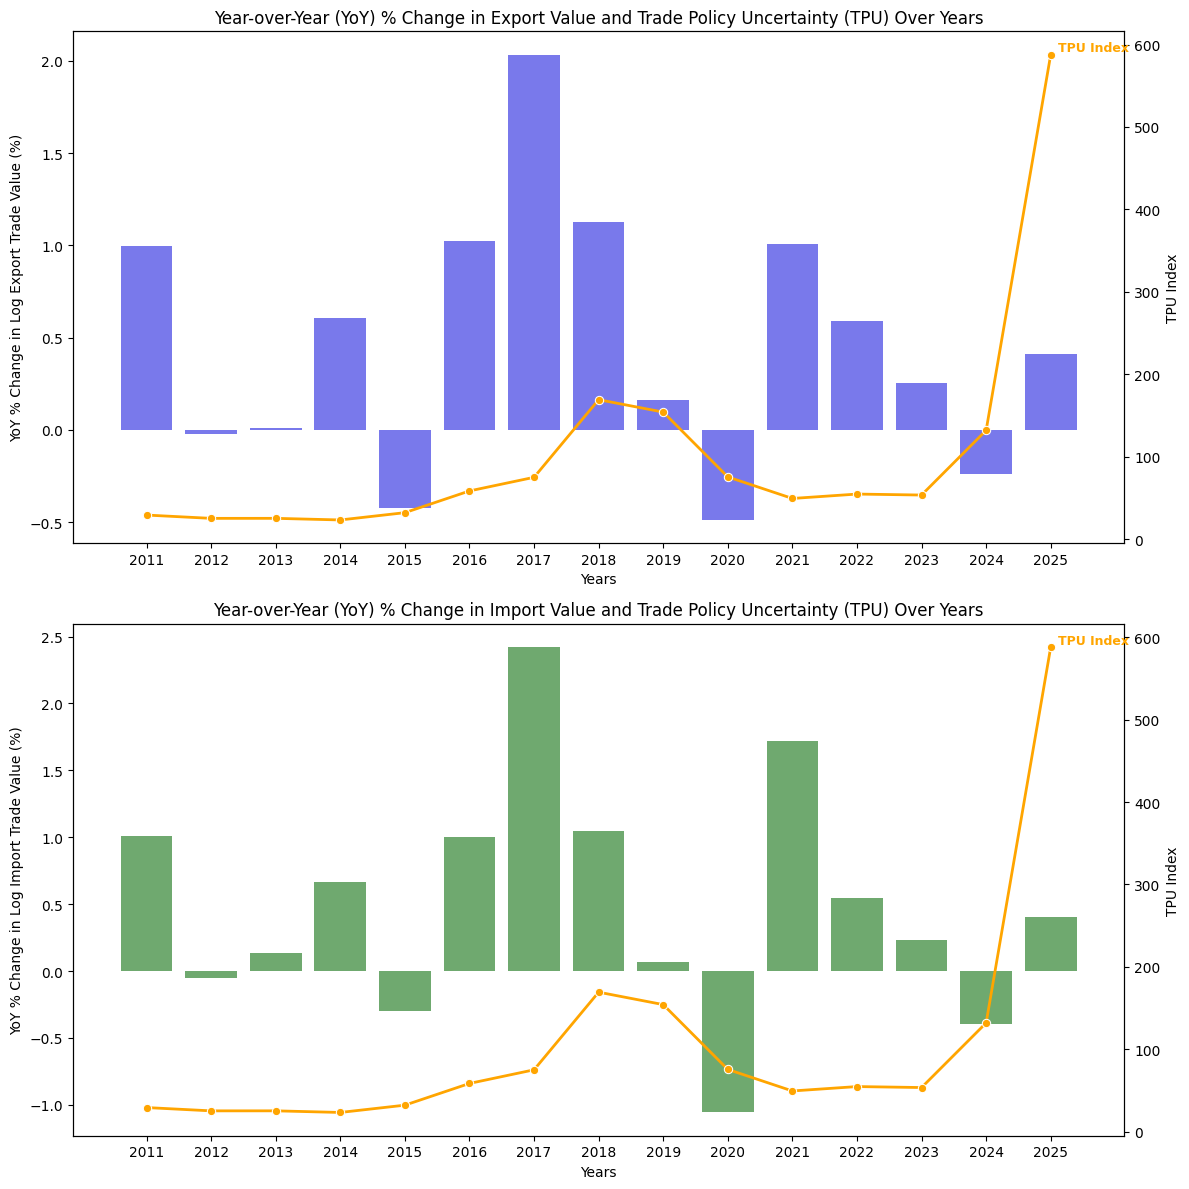

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(12, 12), sharex=False)

#sort exports and imports data by year

tpu_exports["Years"] = tpu_exports["DATE"].dt.year
tpu_imports["Years"] = tpu_imports["DATE"].dt.year

# Calculate YoY % change for exports
exports_yearly = tpu_exports.groupby('Years')['log_trade_value_usd'].mean()
exports_yoy = exports_yearly.pct_change() * 100

# Plot bars for YoY % change
years = exports_yoy.index[1:]  # Skip first NaN value
sns.barplot(x=years, y=exports_yoy.values[1:], ax=axs[0], color='blue', alpha=0.6)

# Create twin axis
axs2 = axs[0].twinx()

# Map the line plots to categorical positions
x_coords = np.arange(len(years))
tpu_values = tpu_exports.groupby('Years')['TPU'].mean()[1:]
sns.lineplot(x=x_coords, y=tpu_values.values, 
             ax=axs2, color='orange', marker='o', linewidth=2)

# Annotate lines directly
axs2.annotate('TPU Index', xy=(x_coords[-1], tpu_values.values[-1]), 
              xytext=(5, 5), textcoords='offset points',
              color='orange', fontweight='bold', va='center', ha='left', fontsize=9)

axs[0].set_title('Year-over-Year (YoY) % Change in Export Value and Trade Policy Uncertainty (TPU) Over Years')
axs[0].set_ylabel('YoY % Change in Log Export Trade Value (%)')
axs[0].set_xlabel('Years')
axs2.set_ylabel('TPU Index')

# Calculate YoY % change for imports
imports_yearly = tpu_imports.groupby('Years')['log_trade_value_usd'].mean()
imports_yoy = imports_yearly.pct_change() * 100

# Plot bars for YoY % change
years_imp = imports_yoy.index[1:]  # Skip first NaN value
sns.barplot(x=years_imp, y=imports_yoy.values[1:], ax=axs[1], color='green', alpha=0.6)

axs3 = axs[1].twinx()

# Apply the same coordinate mapping for imports
x_coords_imp = np.arange(len(years_imp))
tpu_values_imp = tpu_imports.groupby('Years')['TPU'].mean()[1:]
sns.lineplot(x=x_coords_imp, y=tpu_values_imp.values, 
             ax=axs3, color='orange', marker='o', linewidth=2)

# Annotate lines directly
axs3.annotate('TPU Index', xy=(x_coords[-1], tpu_values_imp.values[-1]), 
              xytext=(5, 5), textcoords='offset points',
              color='orange', fontweight='bold', va='center', ha='left', fontsize=9)

axs[1].set_title('Year-over-Year (YoY) % Change in Import Value and Trade Policy Uncertainty (TPU) Over Years')
axs[1].set_ylabel('YoY % Change in Log Import Trade Value (%)')
axs3.set_ylabel('TPU Index')
axs[1].set_xlabel('Years')



plt.tight_layout()
plt.show();

*Figure 1: Year-over-Year (YoY) % Change in Export Value and Import Value with Trade Policy Uncertainty (TPU) Over Years*

The 2018 TPU spike corresponded to a growth in trade value but declines 1-2 years later, likely corresponding to a strong delay in TPU shocks. In the medium-long run, trade grows again, likely as firms acclimatise to the new trade environment and adjust their strategies accordingly.

To enhance this comparison, I divide up the regions by US exposure to create a time-series plot of trade flows.


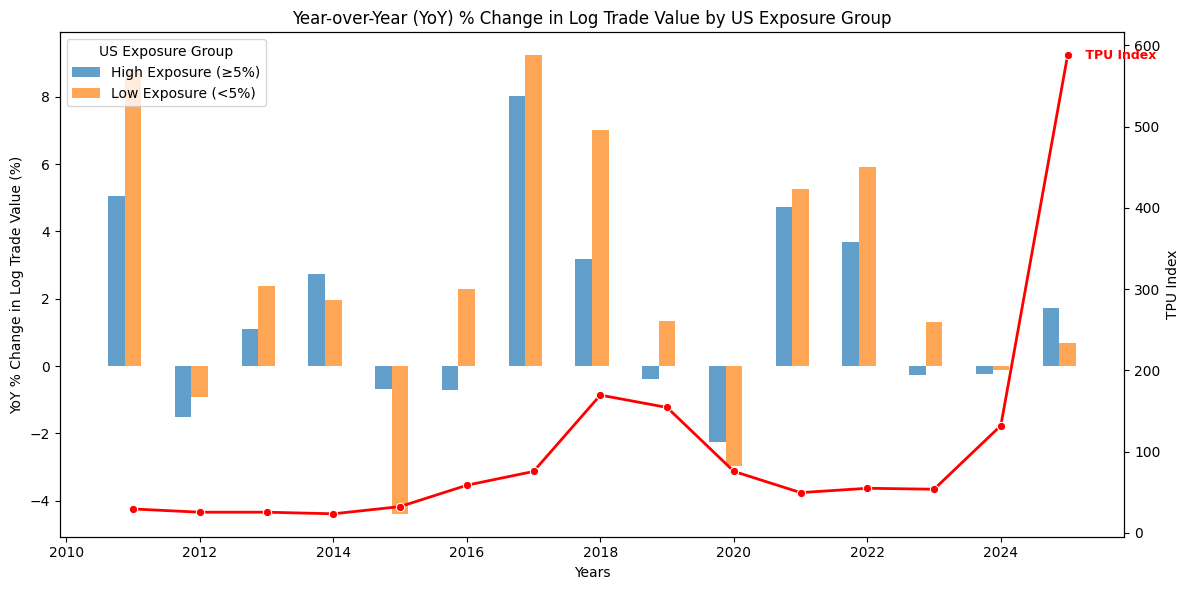

In [16]:
#recreate plot but divide up trade by US exposure groupings (5% threshold)
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Create exposure groups based on 5% threshold (same as used in cell 28)
exposure_groups = [
    ('High Exposure (≥5%)', merged_full_data[merged_full_data['us_exposure_2013'] >= 0.05]),
    ('Low Exposure (<5%)', merged_full_data[merged_full_data['us_exposure_2013'] < 0.05])
]

for i, (group_name, group_data) in enumerate(exposure_groups):
    # Calculate yearly averages
    yearly_trade = group_data.groupby('Year')['Trade Value (Billions USD)'].mean()
    yearly_tpu = group_data.groupby('Year')['Trade Policy Uncertainty Index'].mean()
    
    # Apply arcsinh transformation and calculate YoY % change
    trade_arcsinh = np.arcsinh(yearly_trade)
    trade_yoy = trade_arcsinh.pct_change() * 100
    
    x_pos = trade_yoy.index[1:] + (i - 1) * 0.25  # Offset for bar positions
    
    # Plot trade YoY % change
    ax.bar(x_pos, trade_yoy.values[1:], width=0.25, label=group_name, alpha=0.7)
    
# Plot TPU line
years = trade_yoy.index[1:]
ax2 = ax.twinx()
sns.lineplot(x=years, y=yearly_tpu.values[1:], 
             ax=ax2, color='red', marker='o', linewidth=2)
ax2.text(years[-1] + 0.2, yearly_tpu.values[-1], ' TPU Index',
            color='red', fontweight='bold', va='center', ha='left', fontsize=9)
ax.set_title('Year-over-Year (YoY) % Change in Log Trade Value by US Exposure Group')
ax.set_ylabel('YoY % Change in Log Trade Value (%)')
ax.set_xlabel('Years')
ax2.set_ylabel('TPU Index')

ax.legend(title='US Exposure Group', loc='upper left')
# Show plot
plt.tight_layout()
plt.show();

*Figure 2: Year-over-Year (YoY) % Change in Trade versus Trade Policy Uncertainty (TPU) Divided by Level of US Involvement*

There is a noticeable time-lag associated with trade but US-exposed countries see an earlier and more significant decline compared to non-US-exposed countries: US-exposed trade, for example, more than halved from 2017-2018 and went negative only a year later, which is earlier and at a greater magnitude than the non-US group.



I next consider a plot to visualise TPU against log Trade Value. I do this using a scatter plot with a fitted line to visualise the correlation between TPU and trade value. Policy uncertainty impacts real economic variables with a lag, so I lag TPU variables at 0, 12, and 24 months to test that.

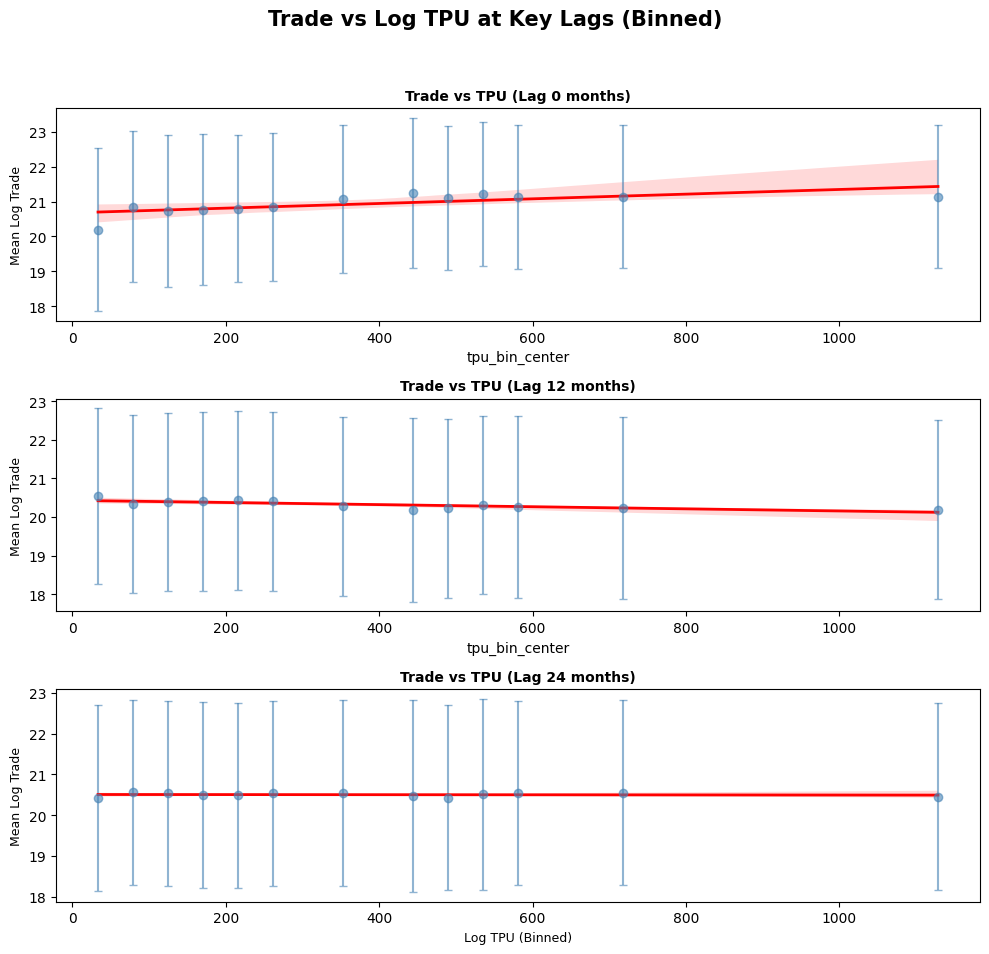

In [17]:
tpu_exports_sorted = tpu_exports.sort_index()
tpu_imports_sorted = tpu_imports.sort_index()

# Create year-month for grouping
tpu_exports_sorted['year_month'] = tpu_exports_sorted.index
tpu_imports_sorted['year_month'] = tpu_imports_sorted.index

# Group by country pair and shift
for df in [tpu_exports_sorted, tpu_imports_sorted]:
    df['TPU_lag_0'] = df.groupby(['iso3reporter', 'iso3partner'])['TPU'].transform(lambda x: x)
    df['TPU_lag_6m'] = df.groupby(['iso3reporter', 'iso3partner'])['TPU'].transform(lambda x: x.shift(6))
    df['TPU_lag_12m'] = df.groupby(['iso3reporter', 'iso3partner'])['TPU'].transform(lambda x: x.shift(12))
    df['TPU_lag_18m'] = df.groupby(['iso3reporter', 'iso3partner'])['TPU'].transform(lambda x: x.shift(18))
    df['TPU_lag_24m'] = df.groupby(['iso3reporter', 'iso3partner'])['TPU'].transform(lambda x: x.shift(24))

# Create 3x1 subplot for trade at key lags
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
fig.suptitle('Trade vs Log TPU at Key Lags (Binned)', 
             fontsize=15, fontweight='bold', y=0.98)

# Define the 3 key lags for trade
trade_lag_periods = [('TPU_lag_0', '0 months'), ('TPU_lag_12m', '12 months'), ('TPU_lag_24m', '24 months')]

# --- TRADE PLOTS ---
for idx, (lag_col, lag_label) in enumerate(trade_lag_periods):
    exp_mask = tpu_exports_sorted[lag_col].notna() & tpu_exports_sorted['log_trade_value_usd'].notna()
    imp_mask = tpu_imports_sorted[lag_col].notna() & tpu_imports_sorted['log_trade_value_usd'].notna()
    
    combined = pd.concat([
        tpu_exports_sorted.loc[exp_mask, [lag_col, 'log_trade_value_usd']],
        tpu_imports_sorted.loc[imp_mask, [lag_col, 'log_trade_value_usd']]
    ]).rename(columns={'log_trade_value_usd': 'trade_value'})
    
    combined['tpu_bin'] = pd.cut(combined[lag_col], bins=25)
    combined['tpu_bin_center'] = combined['tpu_bin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)
    
    binned = combined.groupby('tpu_bin_center', observed=True).agg({
        'trade_value': ['mean', 'std']
    }).reset_index()
    binned.columns = ['tpu_bin_center', 'trade_mean', 'trade_std']
    binned = binned.dropna()
    
    axs[idx].errorbar(binned['tpu_bin_center'], binned['trade_mean'], 
                         yerr=binned['trade_std'], fmt='o', alpha=0.6, capsize=3, 
                         markersize=6, color='steelblue')
    sns.regplot(x=binned['tpu_bin_center'], y=binned['trade_mean'], ax=axs[idx], 
                scatter=False, color='red', line_kws={'linewidth': 2})

    axs[idx].set_title(f'Trade vs TPU (Lag {lag_label})', fontsize=10, fontweight='bold')
    axs[idx].set_ylabel('Mean Log Trade', fontsize=9)
    if idx == 2: axs[idx].set_xlabel('Log TPU (Binned)', fontsize=9)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show(); # Semicolon suppresses technical object text

*Figure 3: Trade Policy Uncertainty (TPU) versus Standard Deviation from Mean of Trade Values*

Trade correlation with TPU starts positive and correlated in the first 12 months, but becomes near-flat by month 24. Thus, we see that trade spikes immediately as TPU rises but goes negative as more time passes post-shock, supporting the interpretation of a delayed TPU reaction.


I next consider the relationship between business confidence and trade policy uncertainty. To do this, I create a time-series plot to compare the progression of BCI and TPU over time. I also plot trade with BCI to visualise the relationship between business confidence and trade flows.

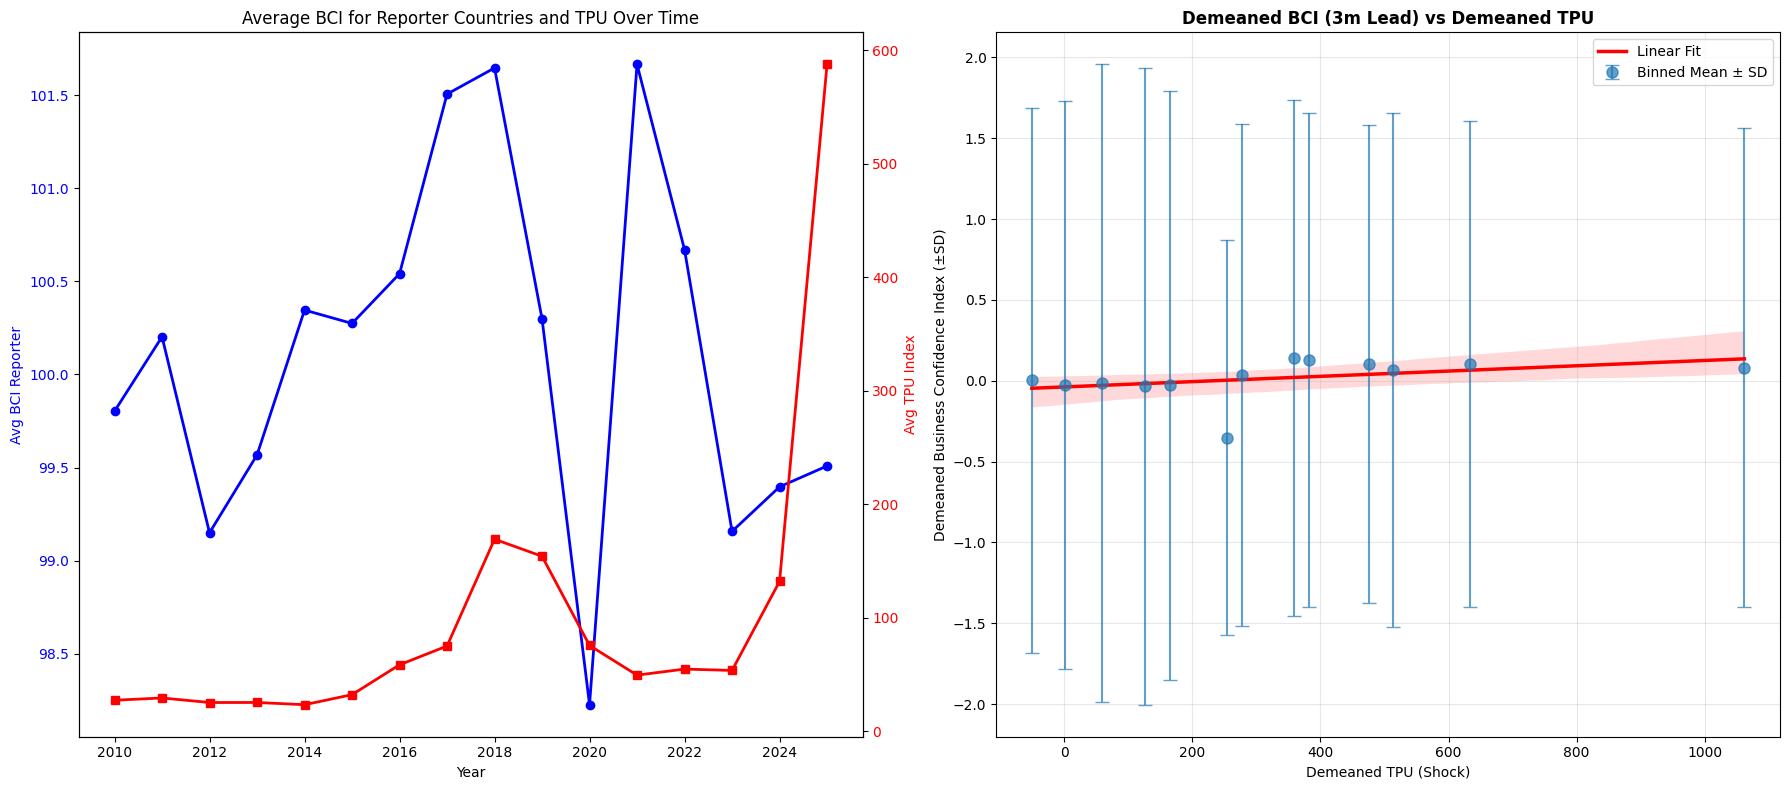

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# LEFT PLOT: BCI and TPU over time
bci_reporter = tpu_exports.groupby('Years')['bci_reporter'].mean()
ax1_left = ax1
ax1_left.plot(bci_reporter.index, bci_reporter.values, color='blue', linewidth=2, marker='o', label='Avg BCI Reporter')
ax1_left.set_xlabel('Year')
ax1_left.set_ylabel('Avg BCI Reporter', color='blue')
ax1_left.tick_params(axis='y', labelcolor='blue')

ax1_right = ax1.twinx()
tpu_avg = tpu_exports.groupby('Years')['TPU'].mean()
ax1_right.plot(tpu_avg.index, tpu_avg.values, color='red', linewidth=2, marker='s', label='Avg TPU Index')
ax1_right.set_ylabel('Avg TPU Index', color='red')
ax1_right.tick_params(axis='y', labelcolor='red')
ax1.set_title('Average BCI for Reporter Countries and TPU Over Time')

# --- RIGHT PLOT: Demeaned BCI vs Demeaned TPU (Monthly Resolution) ---
# We use the tpu_exports dataframe to keep consistency
trade_lag = tpu_exports.copy()

# Shift BCI forward by 3 months to see if TPU today predicts confidence 3 months out
# (Since trade is monthly, a 3-month lead/lag is more standard than the FDI 2-year lag)
trade_lag['bci_lead'] = trade_lag.groupby(['iso3reporter', 'iso3partner'])['bci_reporter'].shift(-3)

# Demeaning to isolate the "Shock" variation
trade_lag['bci_demeaned'] = trade_lag['bci_lead'] - trade_lag['bci_lead'].mean()
trade_lag['tpu_demeaned'] = trade_lag['TPU'] - trade_lag['TPU'].mean()

# Binning the TPU shock into 20 buckets for visualization
trade_lag['tpu_bin'] = pd.cut(trade_lag['tpu_demeaned'], bins=20)
binned_data = trade_lag.groupby('tpu_bin', observed=True).agg({
    'tpu_demeaned': 'mean',
    'bci_demeaned': ['mean', 'std', 'count']
}).reset_index()

binned_data.columns = ['tpu_bin', 'tpu_demeaned_mean', 'bci_demeaned_mean', 'bci_demeaned_std', 'count']
binned_data = binned_data.dropna()

# Plotting the relationship
ax2.errorbar(binned_data['tpu_demeaned_mean'], binned_data['bci_demeaned_mean'], 
             yerr=binned_data['bci_demeaned_std'], fmt='o', alpha=0.7, capsize=5, markersize=8, label='Binned Mean ± SD')

sns.regplot(x=binned_data['tpu_demeaned_mean'], y=binned_data['bci_demeaned_mean'],
            scatter=False, color='red', line_kws={'linewidth': 2.5}, ax=ax2, label='Linear Fit')

ax2.set_title('Demeaned BCI (3m Lead) vs Demeaned TPU', fontweight='bold')
ax2.set_xlabel('Demeaned TPU (Shock)')
ax2.set_ylabel('Demeaned Business Confidence Index (±SD)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


*Figure 4: Business Confidence Index (BCI) versus Log Trade Policy Uncertainty (TPU) Over Years*


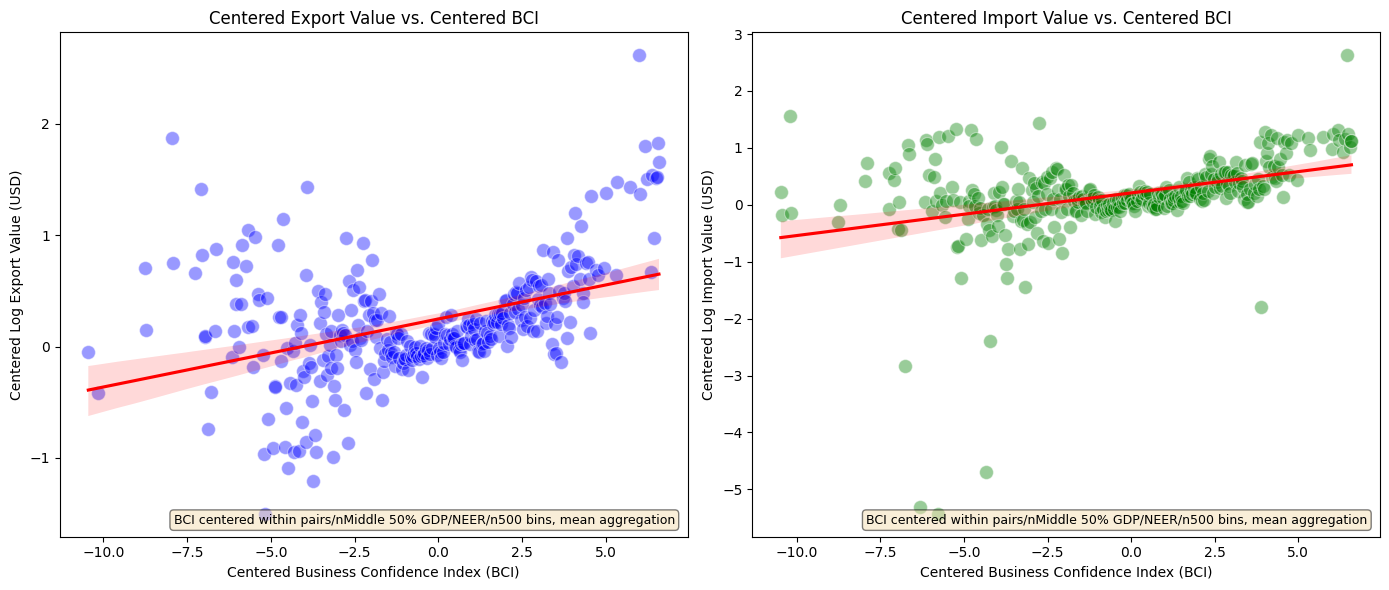

In [19]:
# 1. Clean and Prepare Trade Data
trade_cols = ['bci_reporter', 'log_trade_value_usd', 'iso3reporter', 'iso3partner']

tpu_exports_clean = tpu_exports.dropna(subset=trade_cols).copy()
tpu_imports_clean = tpu_imports.dropna(subset=trade_cols).copy()

tpu_exports_clean = tpu_exports_clean.sort_index()
tpu_imports_clean = tpu_imports_clean.sort_index()

# 2. Within-pair centering (Fixed Effects proxy)
for df in [tpu_exports_clean, tpu_imports_clean]:
    df['bci_centered'] = df['bci_reporter'] - df.groupby(['iso3reporter', 'iso3partner'])['bci_reporter'].transform('mean')
    df['trade_centered'] = df['log_trade_value_usd'] - df.groupby(['iso3reporter', 'iso3partner'])['log_trade_value_usd'].transform('mean')

# Drop rows created by centering/missing values
tpu_exports_clean = tpu_exports_clean.dropna(subset=['bci_centered', 'trade_centered'])
tpu_imports_clean = tpu_imports_clean.dropna(subset=['bci_centered', 'trade_centered'])

# 3. Control Filters (GDP/NEER via middle-50% binning)
def middle_slice(series):
    q1, q3 = series.quantile([0.25, 0.75])
    return (series >= q1) & (series <= q3)

for df in [tpu_exports_clean, tpu_imports_clean]:
    df['gdp_mean'] = (df['ln_gdp_reporter'] + df['ln_gdp_partner']) / 2
    df['neer_mean'] = (df['neer_reporter'] + df['neer_partner']) / 2

tpu_exports_ctrl = tpu_exports_clean.dropna(subset=['gdp_mean', 'neer_mean'])
tpu_imports_ctrl = tpu_imports_clean.dropna(subset=['gdp_mean', 'neer_mean'])

tpu_exports_ctrl = tpu_exports_ctrl[middle_slice(tpu_exports_ctrl['gdp_mean']) & middle_slice(tpu_exports_ctrl['neer_mean'])]
tpu_imports_ctrl = tpu_imports_ctrl[middle_slice(tpu_imports_ctrl['gdp_mean']) & middle_slice(tpu_imports_ctrl['neer_mean'])]

# 4. Binning for Visualization (Binscatter approach)
bins = 500
tpu_exports_ctrl['bci_binned'] = pd.cut(tpu_exports_ctrl['bci_centered'], bins=bins)
tpu_imports_ctrl['bci_binned'] = pd.cut(tpu_imports_ctrl['bci_centered'], bins=bins)

binned_exports_bci = tpu_exports_ctrl.groupby('bci_binned', observed=True).agg({'bci_centered': 'mean', 'trade_centered': 'mean'}).reset_index()
binned_imports_bci = tpu_imports_ctrl.groupby('bci_binned', observed=True).agg({'bci_centered': 'mean', 'trade_centered': 'mean'}).reset_index()

# 5. Plotting (2-Panel Layout)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Exports
sns.scatterplot(data=binned_exports_bci, x='bci_centered', y='trade_centered', ax=axs[0], color='blue', s=100, alpha=0.4)
sns.regplot(data=binned_exports_bci, x='bci_centered', y='trade_centered', ax=axs[0], scatter=False, color='red')
axs[0].set_title('Centered Export Value vs. Centered BCI')
axs[0].set_xlabel('Centered Business Confidence Index (BCI)')
axs[0].set_ylabel('Centered Log Export Value (USD)')
axs[0].text(0.98, 0.02, 'BCI centered within pairs/nMiddle 50% GDP/NEER/n500 bins, mean aggregation',
            transform=axs[0].transAxes, fontsize=9, verticalalignment='bottom',
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Subplot 2: Imports
sns.scatterplot(data=binned_imports_bci, x='bci_centered', y='trade_centered', ax=axs[1], color='green', s=100, alpha=0.4)
sns.regplot(data=binned_imports_bci, x='bci_centered', y='trade_centered', ax=axs[1], scatter=False, color='red')
axs[1].set_title('Centered Import Value vs. Centered BCI')
axs[1].set_xlabel('Centered Business Confidence Index (BCI)')
axs[1].set_ylabel('Centered Log Import Value (USD)')
axs[1].text(0.98, 0.02, 'BCI centered within pairs/nMiddle 50% GDP/NEER/n500 bins, mean aggregation',
            transform=axs[1].transAxes, fontsize=9, verticalalignment='bottom',
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show();

*Figure 5: Business Confidence Index (BCI) versus Standard Deviation from Mean of Trade Values*

We see a strong positive correlation between BCI and trade values, confirming that business confidence plays a role in trade behaviour. The correlation between BCI and TPU, however, seems to be positive or insignificant, which is surprising. I formally test this using a mediation analysis in the next section, but this suggests that business confidence cannot fully explain the relationship between TPU and trade, and that other mechanisms may be at play, aligning with Amiti, Redding, and Weinstein (2020).

# **Project 2**

## 2.1 The Message

The 2018 US trade policy uncertainty shock caused longer-run general trend of trade stagnation post-2018, affecting US-exposed traders more than non-US-exposed ones.

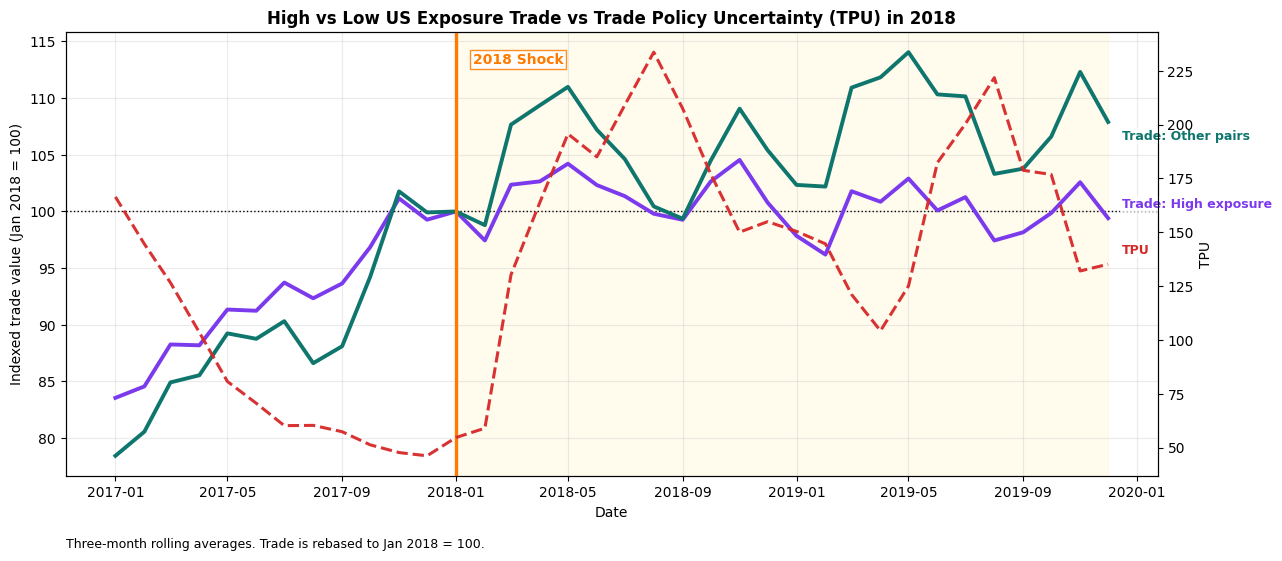

In [20]:
# Single main figure: high vs low US exposure trade with one global TPU line

plot_start = pd.Timestamp('2017-01-01')
plot_end = pd.Timestamp('2019-12-01')
shock_date = pd.Timestamp('2018-01-01')

exports_plot = tpu_exports.loc[(tpu_exports["DATE"] >= plot_start) & (tpu_exports["DATE"] <= plot_end)].copy()
imports_plot = tpu_imports.loc[(tpu_imports["DATE"] >= plot_start) & (tpu_imports["DATE"] <= plot_end)].copy()

def rebase_to_date(series, base_date):
    return series.div(series.loc[base_date]).mul(100)

def annotate_last(ax, x, y, text, color, x_offset=10, y_offset=0):
    ax.annotate(
        text,
        xy=(x, y),
        xytext=(x_offset, y_offset),
        textcoords='offset points',
        color=color,
        fontsize=9,
        fontweight='bold',
        va='center',
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.2)
    )

# Build global TPU series (same regardless of exposure group), smoothed
macro_monthly = (
    pd.concat(
        [
            exports_plot.reset_index()[['DATE', 'iso3reporter', 'TPU']].drop_duplicates(['DATE', 'iso3reporter']),
            imports_plot.reset_index()[['DATE', 'iso3reporter', 'TPU']].drop_duplicates(['DATE', 'iso3reporter'])
        ],
        ignore_index=True
    )
    .drop_duplicates(['DATE', 'iso3reporter'])
    .groupby('DATE')
    .agg(avg_tpu=('TPU', 'mean'))
    .sort_index()
    .rolling(3, min_periods=1).mean()
 )

# Build exposure-group aggregate trade series, smoothed and rebased
combined_trade = pd.concat(
    [
        exports_plot.reset_index()[['DATE', 'trade_value_usd', 'us_exposure']].assign(flow='Exports'),
        imports_plot.reset_index()[['DATE', 'trade_value_usd', 'us_exposure']].assign(flow='Imports')
    ],
    ignore_index=True
 )
combined_trade['exposure_group'] = np.where(
    combined_trade['us_exposure'] > 0.05,
    'High US exposure (> 5%)',
    'Other pairs (<= 5%)'
 )

exposure_grouped = (
    combined_trade
    .groupby(['DATE', 'exposure_group'])
    .agg(total_trade=('trade_value_usd', 'sum'))
    .reset_index()
    .sort_values(['exposure_group', 'DATE'])
 )
exposure_grouped['trade_3m'] = exposure_grouped.groupby('exposure_group')['total_trade'].transform(
    lambda series: series.rolling(3, min_periods=1).mean()
 )

group_order = ['High US exposure (> 5%)', 'Other pairs (<= 5%)']
trade_colors = {
    'High US exposure (> 5%)': '#7c3aed',
    'Other pairs (<= 5%)': '#0f766e'
}

fig, ax_exposure = plt.subplots(figsize=(13, 6))
ax_exposure.axvspan(shock_date, plot_end, color='#fff3bf', alpha=0.28)
ax_exposure.axvline(shock_date, color='#ff7b00', linestyle='-', linewidth=2.4, zorder=3)
ax_exposure.axhline(100, color='black', linestyle=':', linewidth=1)
ax_exposure.grid(True, alpha=0.25)

ax_exposure_right = ax_exposure.twinx()

for group_name in group_order:
    group_data = exposure_grouped[exposure_grouped['exposure_group'] == group_name].copy()
    group_trade_indexed = rebase_to_date(group_data.set_index('DATE')['trade_3m'], shock_date)

    ax_exposure.plot(
        group_trade_indexed.index,
        group_trade_indexed.values,
        color=trade_colors[group_name],
        linewidth=2.8
    )

    trade_label = 'Trade: High exposure' if 'High' in group_name else 'Trade: Other pairs'
    trade_offset = 10 if 'High' in group_name else -10
    annotate_last(
        ax_exposure,
        group_trade_indexed.index[-1],
        group_trade_indexed.iloc[-1],
        trade_label,
        trade_colors[group_name],
        y_offset=trade_offset
    )

ax_exposure_right.plot(
    macro_monthly.index,
    macro_monthly['avg_tpu'],
    color='#d62828',
    linewidth=2.2,
    linestyle='--',
    alpha=0.95
 )
annotate_last(
    ax_exposure_right,
    macro_monthly.index[-1],
    macro_monthly['avg_tpu'].iloc[-1],
    'TPU',
    '#d62828',
    y_offset=10
 )

ax_exposure.annotate(
    '2018 Shock',
    xy=(shock_date, ax_exposure.get_ylim()[1] - 0.8),
    xytext=(12, -16),
    textcoords='offset points',
    color='#ff7b00',
    fontsize=10,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='#ff7b00', pad=2)
 )

ax_exposure.set_title('High vs Low US Exposure Trade vs Trade Policy Uncertainty (TPU) in 2018', fontweight='bold')
ax_exposure.set_ylabel('Indexed trade value (Jan 2018 = 100)')
ax_exposure_right.set_ylabel('TPU')
ax_exposure.set_xlabel('Date')

fig.text(
    0.08,
    0.04,
    'Three-month rolling averages. Trade is rebased to Jan 2018 = 100.',
    fontsize=9
 )

fig.subplots_adjust(top=0.90, bottom=0.16, left=0.08, right=0.92)
plt.show()

*Figure 6: Monthly Year-over-Year (YoY) % Change in Trade and Trade Policy Uncertainty (TPU) Divided by Level of US Involvement*

We see that aggregate trade stagnates post-2018 compared to a strong positive growth pre-shock. This effect is more pronounced for US-exposed traders, which see a stronger trend than their non-exposed counterparts. The implication is that US-trade policy uncertainty shocks have strong spillovers on global trade, but that the effect is much stronger for those who are reliant on the US as a trading partner.

# 2.2 Maps and Interpretation

I present several maps to visualise the geographical distribution of trade changes post-2018, with a focus on US-exposure. 

First, I use a heat map to visualise the concentration of trade across the dataset.

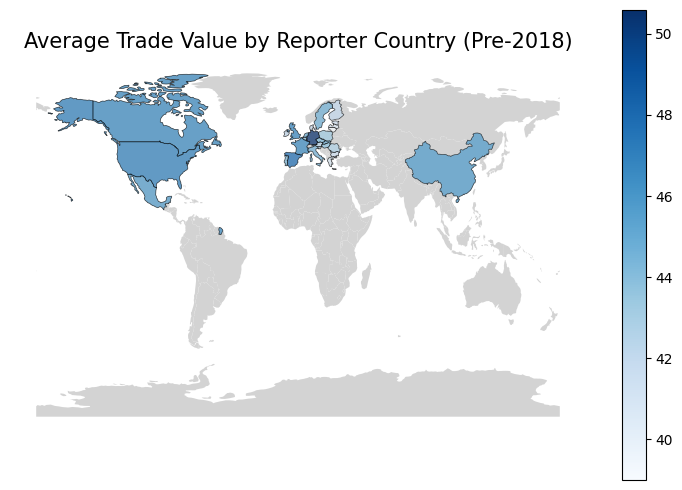

In [21]:
world = gpd.read_file("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/ne_110m_admin_0_countries.shp")
map_key = 'ADM0_A3' if 'ADM0_A3' in world.columns else 'ISO_A3'



#create a map of averaged import and exports by country to visualize overall trade patterns
#we want each unique country to only appear once, so we aggregate by reporter country first, then merge with shapefile
trade_agg_exports = tpu_exports.groupby('iso3reporter')['trade_value_usd'].mean().reset_index()
trade_agg_imports = tpu_imports.groupby('iso3reporter')['trade_value_usd'].mean().reset_index()

#log transform for better visualization
trade_agg_exports['trade_value_usd'] = np.log(trade_agg_exports['trade_value_usd'].clip(lower=1e-9))
trade_agg_imports['trade_value_usd'] = np.log(trade_agg_imports['trade_value_usd'].clip(lower=1e-9))

trade_agg_total = trade_agg_exports.merge(trade_agg_imports, on='iso3reporter', how='outer', suffixes=('_exports', '_imports'))
trade_agg_total['trade_value_total'] = trade_agg_total[['trade_value_usd_exports', 'trade_value_usd_imports']].sum(axis=1)
trade_agg_total = trade_agg_total.merge(world[[map_key, 'geometry']], left_on='iso3reporter', right_on=map_key, how='left')
trade_agg_total = trade_agg_total[trade_agg_total['geometry'].notna()].copy()
gdf_trade = gpd.GeoDataFrame(trade_agg_total, geometry='geometry')
fig, ax = plt.subplots(1, 1, figsize=(7.5, 5))
world.plot(ax=ax, color='lightgray')
gdf_trade_valid = gdf_trade[gdf_trade['trade_value_total'].notna()]
gdf_trade_valid.plot(ax=ax, column='trade_value_total', cmap='Blues', legend=True, alpha=0.7, edgecolor='k', linewidth=0.5)
ax.set_title('Average Trade Value by Reporter Country (Pre-2018)', fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()


We see that the dataset is heavily concentrated in the EU. The implication, however, is that several large US partners, such as Japan, are not represented in the dataset. However, the inclusion other major traders, such as the UK and Canada, ensures that the results are still relatively representative of a variety of US-exposure levels.

We next consider the spread of US-exposures across the dataset.

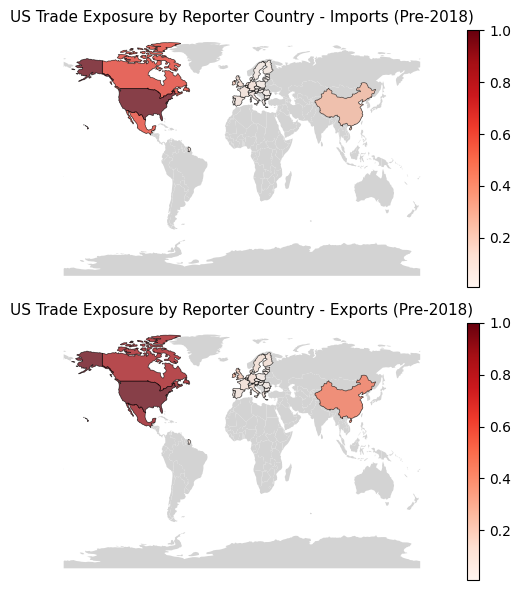

In [22]:
# Map of US exposure for reporter countries using imports and exports (pre-2018)
date_col = 'DATE' if 'DATE' in tpu_imports.columns else 'date'

# ----- Imports exposure -----
map_data = tpu_imports.reset_index().copy()
map_data[date_col] = pd.to_datetime(map_data[date_col], errors='coerce')
map_data = map_data[map_data[date_col].dt.year < 2018].copy()
map_data['us_trade_value'] = np.where(
    map_data['iso3partner'] == 'USA',
    map_data['trade_value_usd'],
    0
)

monthly = (
    map_data
    .groupby(['iso3reporter', date_col], as_index=False)
    .agg(
        reporter_total_trade=('trade_value_usd', 'sum'),
        us_trade_reporter=('us_trade_value', 'sum')
    )
)

imports_map = (
    monthly
    .groupby('iso3reporter', as_index=False)
    .agg(
        reporter_total_trade=('reporter_total_trade', 'sum'),
        us_trade_reporter=('us_trade_reporter', 'sum')
    )
)

imports_map['us_exposure_ratio'] = (
    imports_map['us_trade_reporter'].abs() / imports_map['reporter_total_trade'].abs()
)
imports_map.loc[imports_map['iso3reporter'] == 'USA', 'us_exposure_ratio'] = 1.0
imports_map = imports_map.merge(
    world[[map_key, 'geometry']],
    left_on='iso3reporter',
    right_on=map_key,
    how='left'
)
imports_map = imports_map[imports_map['geometry'].notna()].copy()
gdf_imports = gpd.GeoDataFrame(imports_map, geometry='geometry')

# ----- Exports exposure -----
map_data_exports = tpu_exports.reset_index().copy()
map_data_exports[date_col] = pd.to_datetime(map_data_exports[date_col], errors='coerce')
map_data_exports = map_data_exports[map_data_exports[date_col].dt.year < 2018].copy()
map_data_exports['us_trade_value'] = np.where(
    map_data_exports['iso3partner'] == 'USA',
    map_data_exports['trade_value_usd'],
    0
)

monthly_exports = (
    map_data_exports
    .groupby(['iso3reporter', date_col], as_index=False)
    .agg(
        reporter_total_trade=('trade_value_usd', 'sum'),
        us_trade_reporter=('us_trade_value', 'sum')
    )
)

exports_map = (
    monthly_exports
    .groupby('iso3reporter', as_index=False)
    .agg(
        reporter_total_trade=('reporter_total_trade', 'sum'),
        us_trade_reporter=('us_trade_reporter', 'sum')
    )
)

exports_map['us_exposure_ratio'] = (
    exports_map['us_trade_reporter'].abs() / exports_map['reporter_total_trade'].abs()
)
exports_map.loc[exports_map['iso3reporter'] == 'USA', 'us_exposure_ratio'] = 1.0
exports_map = exports_map.merge(
    world[[map_key, 'geometry']],
    left_on='iso3reporter',
    right_on=map_key,
    how='left'
)
exports_map = exports_map[exports_map['geometry'].notna()].copy()
gdf_exports = gpd.GeoDataFrame(exports_map, geometry='geometry')

# ----- Combined figure: 2 vertical, 1 horizontal -----
fig, axes = plt.subplots(2, 1, figsize=(6, 6))

# Keep the same color scale across both maps for comparability
all_ratios = pd.concat([
    gdf_imports['us_exposure_ratio'],
    gdf_exports['us_exposure_ratio']
], ignore_index=True)
vmin, vmax = all_ratios.min(), all_ratios.max()

# Top: imports
world.plot(ax=axes[0], color='lightgray')
gdf_imports_valid = gdf_imports[gdf_imports['us_exposure_ratio'].notna()]
gdf_imports_valid.plot(
    ax=axes[0],
    column='us_exposure_ratio',
    cmap='Reds',
    legend=True,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5,
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title('US Trade Exposure by Reporter Country - Imports (Pre-2018)', fontsize=11)
axes[0].set_axis_off()

# Bottom: exports
world.plot(ax=axes[1], color='lightgray')
gdf_exports_valid = gdf_exports[gdf_exports['us_exposure_ratio'].notna()]
gdf_exports_valid.plot(
    ax=axes[1],
    column='us_exposure_ratio',
    cmap='Reds',
    legend=True,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5,
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title('US Trade Exposure by Reporter Country - Exports (Pre-2018)', fontsize=11)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Canada and Mexico are the most US-exposed trading partners. Exports tends to see higher levels of US-exposure than imports, which may be due to the strength of the US dollar and its influence as a global export market for many countries. We thus expect exports to be more sensitive to US trade policy uncertainty shocks than imports.

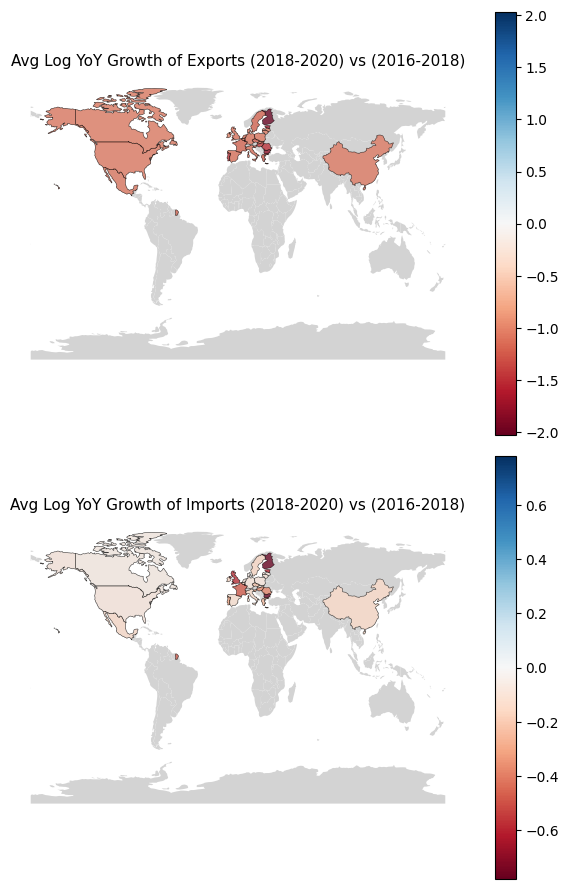

In [23]:
# YoY Growth Rate Analysis: Compare growth trajectory pre-2018 vs post-2018
world = gpd.read_file("C:/Users/ja200/OneDrive/Documents/Programming/Python Projects/ne_110m_admin_0_countries.shp")
map_key = 'ADM0_A3' if 'ADM0_A3' in world.columns else 'ISO_A3'
date_col = 'DATE' if 'DATE' in tpu_exports.columns else 'date'

# Ensure date columns are datetime
tpu_exports = tpu_exports.copy()
tpu_imports = tpu_imports.copy()
tpu_exports[date_col] = pd.to_datetime(tpu_exports[date_col])
tpu_imports[date_col] = pd.to_datetime(tpu_imports[date_col])

tpu_exports['Year'] = tpu_exports[date_col].dt.year
tpu_imports['Year'] = tpu_imports[date_col].dt.year

# Function to calculate average YoY growth rate for a period
def calc_yoy_growth(df, years):
    """Calculate average year-over-year growth rate for given years"""
    df_sub = df[df['Year'].isin(years)].copy()
    
    # Get yearly averages
    yearly = df_sub.groupby(['iso3reporter', 'Year'], as_index=False)['trade_value_usd'].mean()
    
    # Calculate YoY growth rates
    yearly['log_trade'] = np.log(yearly['trade_value_usd'].clip(lower=1e-9))
    yearly['log_yoy_growth'] = yearly.groupby('iso3reporter')['log_trade'].diff()
    
    # Average YoY growth within period (exclude first year which has NaN)
    avg_growth = yearly[yearly['log_yoy_growth'].notna()].groupby('iso3reporter')['log_yoy_growth'].mean().reset_index()
    avg_growth.columns = ['iso3reporter', 'avg_yoy_growth']
    
    return avg_growth

# Calculate pre-2018 growth (2015-2017)
pre_years = [2015, 2016, 2017]
exports_pre_growth = calc_yoy_growth(tpu_exports, pre_years)
imports_pre_growth = calc_yoy_growth(tpu_imports, pre_years)

# Calculate post-2018 growth (2018-2020)
post_years = [2018, 2019, 2020]
exports_post_growth = calc_yoy_growth(tpu_exports, post_years)
imports_post_growth = calc_yoy_growth(tpu_imports, post_years)

# Merge and calculate growth rate change for exports
exports_growth = exports_pre_growth.merge(exports_post_growth, on='iso3reporter', how='inner', suffixes=('_pre', '_post'))
exports_growth['growth_deceleration'] = np.log(exports_growth['avg_yoy_growth_post'] + 1) - (exports_growth['avg_yoy_growth_pre'] + 1)
exports_growth = exports_growth.merge(world[[map_key, 'geometry']], left_on='iso3reporter', right_on=map_key, how='left')
exports_growth = exports_growth[exports_growth['geometry'].notna()].copy()
gdf_exports_growth = gpd.GeoDataFrame(exports_growth, geometry='geometry')

# Merge and calculate growth rate change for imports
imports_growth = imports_pre_growth.merge(imports_post_growth, on='iso3reporter', how='inner', suffixes=('_pre', '_post'))
imports_growth['growth_deceleration'] = np.log(imports_growth['avg_yoy_growth_post'] + 1) - np.log(imports_growth['avg_yoy_growth_pre'] + 1)
imports_growth = imports_growth.merge(world[[map_key, 'geometry']], left_on='iso3reporter', right_on=map_key, how='left')
imports_growth = imports_growth[imports_growth['geometry'].notna()].copy()
gdf_imports_growth = gpd.GeoDataFrame(imports_growth, geometry='geometry')

# Create visualizations
fig, axes = plt.subplots(2, 1, figsize=(6, 9))

# Calculate symmetric color scale
exports_abs_cap = np.nanpercentile(np.abs(gdf_exports_growth['growth_deceleration']), 95)
if not np.isfinite(exports_abs_cap) or exports_abs_cap == 0:
    exports_abs_cap = 0.01

imports_abs_cap = np.nanpercentile(np.abs(gdf_imports_growth['growth_deceleration']), 95)
if not np.isfinite(imports_abs_cap) or imports_abs_cap == 0:
    imports_abs_cap = 0.01

# Top: Exports growth deceleration
world.plot(ax=axes[0], color='lightgray')
gdf_exports_growth_valid = gdf_exports_growth[gdf_exports_growth['growth_deceleration'].notna()]
gdf_exports_growth_valid.plot(
    ax=axes[0],
    column='growth_deceleration',
    cmap='RdBu',
    legend=True,
    vmin=-exports_abs_cap,
    vmax=exports_abs_cap,
    alpha=0.75,
    edgecolor='k',
    linewidth=0.4
)
axes[0].set_title('Avg Log YoY Growth of Exports (2018-2020) vs (2016-2018)', fontsize=11)
axes[0].set_axis_off()

# Bottom: Imports growth deceleration
world.plot(ax=axes[1], color='lightgray')
gdf_imports_growth_valid = gdf_imports_growth[gdf_imports_growth['growth_deceleration'].notna()]
gdf_imports_growth_valid.plot(
    ax=axes[1],
    column='growth_deceleration',
    cmap='RdBu',
    legend=True,
    vmin=-imports_abs_cap,
    vmax=imports_abs_cap,
    alpha=0.75,
    edgecolor='k',
    linewidth=0.4
)
axes[1].set_title('Avg Log YoY Growth of Imports (2018-2020) vs (2016-2018)', fontsize=11)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


I visualise the change in yearly trade growth post-2018 across the world compared to the pre-trend of 2014-2016 (2017 is excluded to avoid anticipation behaviour). We see that, in general, global trade growth decelerated post-2018, more so for exports. It is difficult to tell if US-exposed traders are more affected than non-US-exposed ones, so that will require formal testing.

Finally, in support of the mechanism of business confidence, I visualise the change in business confidence post-2018 across the world compared to the pre-trend of 2015-2017.

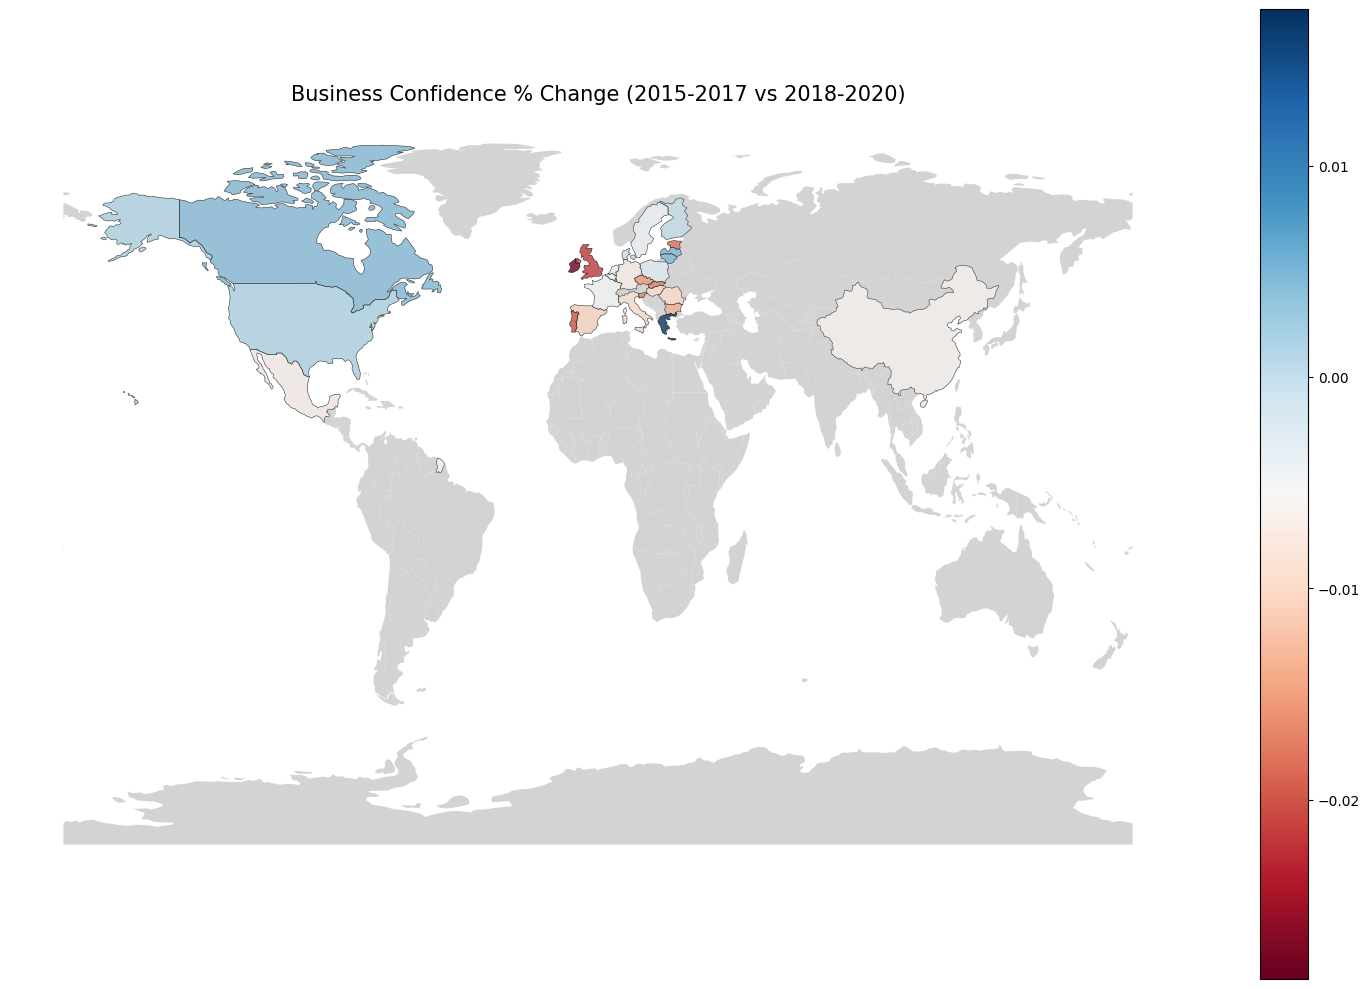

In [24]:
# Additional Map 2: BCI change map (2015-2017 vs 2018-2020)
bci_panel = pd.concat(
    [
        tpu_exports.reset_index()[['DATE', 'iso3reporter', 'bci_reporter']],
        tpu_imports.reset_index()[['DATE', 'iso3reporter', 'bci_reporter']]
    ],
    ignore_index=True
).drop_duplicates(['DATE', 'iso3reporter'])

bci_panel['DATE'] = pd.to_datetime(bci_panel['DATE'])
bci_panel['window'] = pd.Series(index=bci_panel.index, dtype='object')
bci_panel.loc[
    (bci_panel['DATE'].dt.year >= 2015) & (bci_panel['DATE'].dt.year <= 2017),
    'window'
] = '2015-2017'
bci_panel.loc[
    (bci_panel['DATE'].dt.year >= 2018) & (bci_panel['DATE'].dt.year <= 2020),
    'window'
] = '2018-2020'
bci_panel = bci_panel.dropna(subset=['window'])

bci_change = (
    bci_panel
    .groupby(['iso3reporter', 'window'], as_index=False)['bci_reporter']
    .mean()
    .pivot(index='iso3reporter', columns='window', values='bci_reporter')
    .reset_index()
)
bci_change['bci_pct_change'] = (
    bci_change['2018-2020'] - bci_change['2015-2017']
) / bci_change['2015-2017'].clip(lower=1e-9)

bci_map = bci_change.merge(
    world[[map_key, 'geometry']],
    left_on='iso3reporter',
    right_on=map_key,
    how='left'
)
bci_map = bci_map[bci_map['geometry'].notna()].copy()
gdf_bci = gpd.GeoDataFrame(bci_map, geometry='geometry')

fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world.plot(ax=ax, color='lightgray')
gdf_bci_valid = gdf_bci[gdf_bci['bci_pct_change'].notna()]
gdf_bci_valid.plot(
    ax=ax,
    column='bci_pct_change',
    cmap='RdBu',
    legend=True,
    alpha=0.75,
    edgecolor='k',
    linewidth=0.4
)
ax.set_title('Business Confidence % Change (2015-2017 vs 2018-2020)', fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

For most countries, business confidence saw a slight decline post-2018, suggesting 2018 trade policy uncertainty shock had a negative impact, if not strongly. It is possible that BCI is highly delayed, thus hiding its full effect.

## 2.3. Regression Analysis

To capture the relationship between trade policy uncertainty and trade values, I first run a simple panel regression with time and country fixed effects, using the log of trade value as the dependent variable and the log of TPU as the independent variable. I then add controls for GDP and NEER to account for other macroeconomic factors that may influence trade values, before adding lags to capture time dynamics.

In [25]:
# Run baseline/controls/lags panel regressions for exports and imports
from linearmodels.panel import PanelOLS
import numpy as np
import pandas as pd
from stargazer.stargazer import Stargazer
import warnings

# Suppress PanelOLS warnings
warnings.filterwarnings('ignore')

# Ensure lags are created
tpu_imports['ln_TPU_lag_12m'] = tpu_imports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(12)
tpu_imports['ln_TPU_lag_24m'] = tpu_imports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(24)
tpu_exports['ln_TPU_lag_12m'] = tpu_exports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(12)
tpu_exports['ln_TPU_lag_24m'] = tpu_exports.groupby(['iso3reporter', 'iso3partner'])['ln_TPU'].shift(24)


def prepare_panel_data(df):
    """Convert to panel format with MultiIndex (entity, time)."""
    df_panel = df.copy().reset_index(drop=False)
    df_panel['entity'] = df_panel['iso3reporter'] + '_' + df_panel['iso3partner']
    if 'DATE' not in df_panel.columns:
        df_panel['DATE'] = df_panel.index
    df_panel['time'] = df_panel['DATE']
    df_panel = df_panel.set_index(['entity', 'time'])
    df_panel['log_trade_value'] = np.log(df_panel['trade_value_usd'])
    return df_panel


# Prepare data
tpu_imports_panel = prepare_panel_data(tpu_imports)
tpu_exports_panel = prepare_panel_data(tpu_exports)

# Cluster at country-pair level
clusters_imports = pd.Series(tpu_imports_panel.index.get_level_values('entity'), index=tpu_imports_panel.index)
clusters_exports = pd.Series(tpu_exports_panel.index.get_level_values('entity'), index=tpu_exports_panel.index)

# Base models
imports_base = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

exports_base = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

# Models with controls
imports_controls = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'gdp_reporter_std', 'gdp_partner_std', 'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

exports_controls = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'gdp_reporter_std', 'gdp_partner_std', 'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

# Models with controls and lags
imports_controls_lags = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'ln_TPU_lag_12m', 'ln_TPU_lag_24m',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

exports_controls_lags = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'ln_TPU_lag_12m', 'ln_TPU_lag_24m',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

# Mega table: Exports/Imports side-by-side by specification
stargazer_trade_baseline_mega = Stargazer([
    exports_base, imports_base,
    exports_controls, imports_controls,
    exports_controls_lags, imports_controls_lags
])
stargazer_trade_baseline_mega.title("Trade Regression Results: Baseline -> Controls -> Controls + Lags")
stargazer_trade_baseline_mega.custom_columns([
    'Exports Baseline', 'Imports Baseline',
    'Exports Controls', 'Imports Controls',
    'Exports Controls + Lags', 'Imports Controls + Lags'
], [1, 1, 1, 1, 1, 1])
stargazer_trade_baseline_mega.covariate_order([
    'ln_TPU', 'ln_TPU_lag_12m', 'ln_TPU_lag_24m',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
])


display(HTML(stargazer_trade_baseline_mega.render_html()))

We see that a 1% increase in TPU results in a 4.9% increase in both export and imports, remaining positive and significant at a 1% level in years 1 and 2. However, this model suffers from endogeneity and does not account for proximity to the US, which may bias the results.

To address this, I implement country-pair and year fixed effects, which control for time-invariant factors associated with each country pair and year. 

In [26]:
# Fit models with different fixed-effects combinations using panelOLS
# Specifications: No FE, Entity FE, Time FE, Entity + Time FE

exog_vars = [
    'ln_TPU', 'ln_TPU_lag_12m', 'ln_TPU_lag_24m',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
]

# Cluster at the country-pair level for all specifications
imports_fe_clusters = pd.Series(
    tpu_imports_panel.index.get_level_values('entity'),
    index=tpu_imports_panel.index
)
exports_fe_clusters = pd.Series(
    tpu_exports_panel.index.get_level_values('entity'),
    index=tpu_exports_panel.index
)

# Imports models
imports_no_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[exog_vars],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

imports_pair_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[exog_vars],
    entity_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

imports_time_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[exog_vars],
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

imports_both_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[exog_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

# Exports models
exports_no_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[exog_vars],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

exports_pair_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[exog_vars],
    entity_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

exports_time_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[exog_vars],
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

exports_both_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[exog_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

# Mega table: Exports/Imports side-by-side by FE specification
stargazer_fe_mega = Stargazer([
    exports_no_fe, imports_no_fe,
    exports_pair_fe, imports_pair_fe,
    exports_time_fe, imports_time_fe,
    exports_both_fe, imports_both_fe
])
stargazer_fe_mega.title('Trade Regression Results with Different Fixed Effects')

#add custom column names to represent the FEs added
stargazer_fe_mega.custom_columns([
    'Exports No FE', 'Imports No FE',
    'Exports Pair FE', 'Imports Pair FE',
    'Exports Time FE', 'Imports Time FE',
    'Exports Both FE', 'Imports Both FE'
], [1, 1, 1, 1, 1, 1, 1, 1])
stargazer_fe_mega.covariate_order([
    'ln_TPU', 'ln_TPU_lag_12m', 'ln_TPU_lag_24m',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
])
#rename variable names for better readability
stargazer_fe_mega.rename_covariates({
    'ln_TPU': 'ln(TPU)',
    'ln_TPU_lag_12m': 'ln(TPU) Lag 12m',
    'ln_TPU_lag_24m': 'ln(TPU) Lag 24m',
    'gdp_reporter_std': 'GDP Reporter',
    'gdp_partner_std': 'GDP Partner',
    'neer_reporter_std': 'NEER Reporter',
    'neer_partner_std': 'NEER Partner'
})

display(HTML(f'<div style="font-size: calc(1em - 6px); transform: scaleX(0.8); transform-origin: top;">{stargazer_fe_mega.render_html()}</div>'))

We see that the coefficient for ln(TPU) becomes smaller the more fixed effects we add, becoming insignificant with both country-pair and time FEs. We see that the positive trend seems driven more by country and time-specific trends than TPU itself.

However, the survival of lag coefficients suggests TPU has an effect on trade but only after a year. We observe that, due to the positive coefficient, frontloading does take place for exports after the first year before declining and that imports dip in year 1 but recover, aligning with Bloom (2019) and Lu and Malikov (2026)'s findings.

Finally, I interact TPU with US-exposure to test whether US-exposure amplifies the effect of TPU. Theoretically, countries with higher US-exposure are more directly impacted by US TPU shocks versus those with lower US-exposure, who are more insulated. I first use a binary variable set at 5% exposure, then a continuous variable to capture marginal effects.

In [27]:
# Heterogeneous effects by US exposure group using interaction dummies: Control + Lags model
from linearmodels.panel import PanelOLS
import numpy as np
import pandas as pd
from stargazer.stargazer import Stargazer
import warnings

warnings.filterwarnings('ignore')

# Ensure exposure variable exists and create high exposure dummy
for df in [tpu_imports, tpu_exports]:
    if 'us_exposure_2013' not in df.columns:
        df['us_exposure_2013'] = 0.0
    # Create dummy: 1 = high exposure (>= 0.05), 0 = low exposure
    df['high_exposure'] = (df['us_exposure_2013'] >= 0.05).astype(int)

# Create interaction terms for both imports and exports
for df in [tpu_imports, tpu_exports]:
    df['high_exp_X_ln_tpu'] = df['high_exposure'] * df['ln_TPU']
    df['high_exp_X_ln_tpu_lag12'] = df['high_exposure'] * df['ln_TPU_lag_12m']
    df['high_exp_X_ln_tpu_lag24'] = df['high_exposure'] * df['ln_TPU_lag_24m']

# Prepare panel data
def prepare_panel_data(df):
    """Convert to panel format with MultiIndex (entity, time)."""
    df_panel = df.copy().reset_index(drop=False)
    df_panel['entity'] = df_panel['iso3reporter'] + '_' + df_panel['iso3partner']
    if 'DATE' not in df_panel.columns:
        df_panel['DATE'] = df_panel.index
    df_panel['time'] = df_panel['DATE']
    df_panel = df_panel.set_index(['entity', 'time'])
    df_panel['log_trade_value'] = np.log(df_panel['trade_value_usd'])
    return df_panel

# Convert to panel format
tpu_imports_panel = prepare_panel_data(tpu_imports)
tpu_exports_panel = prepare_panel_data(tpu_exports)

# Create cluster variables
clusters_imports = pd.Series(tpu_imports_panel.index.get_level_values('entity'), index=tpu_imports_panel.index)
clusters_exports = pd.Series(tpu_exports_panel.index.get_level_values('entity'), index=tpu_exports_panel.index)

# ===== Model 1: Without Fixed Effects =====
# Run models with interaction terms: Control + Lags + Interactions
imports_interactions = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'ln_TPU_lag_12m', 'ln_TPU_lag_24m',
                       'high_exposure', 'high_exp_X_ln_tpu', 'high_exp_X_ln_tpu_lag12', 'high_exp_X_ln_tpu_lag24',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

exports_interactions = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'ln_TPU_lag_12m', 'ln_TPU_lag_24m',
                       'high_exposure', 'high_exp_X_ln_tpu', 'high_exp_X_ln_tpu_lag12', 'high_exp_X_ln_tpu_lag24',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

# ===== Model 2: With Country-Pair and Year Fixed Effects =====
# Run models with FE: Control + Lags + Interactions + Country-Pair FE + Year FE
imports_interactions_fe = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'ln_TPU_lag_12m', 'ln_TPU_lag_24m',
                       'high_exposure', 'high_exp_X_ln_tpu', 'high_exp_X_ln_tpu_lag12', 'high_exp_X_ln_tpu_lag24',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

exports_interactions_fe = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'ln_TPU_lag_12m', 'ln_TPU_lag_24m',
                       'high_exposure', 'high_exp_X_ln_tpu', 'high_exp_X_ln_tpu_lag12', 'high_exp_X_ln_tpu_lag24',
                       'gdp_reporter_std', 'gdp_partner_std',
                       'neer_reporter_std', 'neer_partner_std']],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

# Combined comparison table: All models side-by-side
stargazer_exposure_combined = Stargazer([
    exports_interactions, imports_interactions,
    exports_interactions_fe, imports_interactions_fe
])
stargazer_exposure_combined.title("Trade Regressions with US Exposure Interactions: With and Without Country-Pair & Year FE")
stargazer_exposure_combined.custom_columns([
    'Exports (No FE)', 'Imports (No FE)', 'Exports (With FE)', 'Imports (With FE)'
], [1, 1, 1, 1])
stargazer_exposure_combined.covariate_order([
    'ln_TPU', 'ln_TPU_lag_12m', 'ln_TPU_lag_24m',
    'high_exposure', 'high_exp_X_ln_tpu', 'high_exp_X_ln_tpu_lag12', 'high_exp_X_ln_tpu_lag24',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
])

display(HTML(f'<div style="font-size: calc(1em - 6px);">{stargazer_exposure_combined.render_html()}</div>'))


In [28]:
# Create combined comparison table: specifications without vs with US-exposure interactions

# Ensure lag x US exposure interaction columns exist in panel data
for panel_df in [tpu_exports_panel, tpu_imports_panel]:
    if 'ln_TPU_lag_12m_x_us_exp' not in panel_df.columns:
        panel_df['ln_TPU_lag_12m_x_us_exp'] = panel_df['ln_TPU_lag_12m'] * panel_df['us_exposure_2013']
    if 'ln_TPU_lag_24m_x_us_exp' not in panel_df.columns:
        panel_df['ln_TPU_lag_24m_x_us_exp'] = panel_df['ln_TPU_lag_24m'] * panel_df['us_exposure_2013']

# Refit US-exposure interaction models with clustered SEs (country-pair level)
us_exp_exog = [
    'ln_TPU', 'ln_TPU_x_us_exp',
    'ln_TPU_lag_12m', 'ln_TPU_lag_12m_x_us_exp',
    'ln_TPU_lag_24m', 'ln_TPU_lag_24m_x_us_exp',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
]

exports_controls_lags_us_exp = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[us_exp_exog],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=exports_fe_clusters)

imports_controls_lags_us_exp = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[us_exp_exog],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=imports_fe_clusters)

# Mega table: Exports/Imports side-by-side by specification
stargazer_full_spec_mega = Stargazer([
    exports_controls_lags, imports_controls_lags,
    exports_both_fe, imports_both_fe,
    exports_controls_lags_us_exp, imports_controls_lags_us_exp, 
])
stargazer_full_spec_mega.title('Trade Regression Results: Full Specification Comparison')
stargazer_full_spec_mega.custom_columns([
    'Exports Controls + Lags', 'Imports Controls + Lags',
    'Exports Entity + Time FE', 'Imports Entity + Time FE',
    'Exports + US Exposure', 'Imports + US Exposure'
], [1, 1, 1, 1, 1, 1])
stargazer_full_spec_mega.covariate_order([
    'ln_TPU', 'ln_TPU_x_us_exp',
    'ln_TPU_lag_12m', 'ln_TPU_lag_12m_x_us_exp',
    'ln_TPU_lag_24m', 'ln_TPU_lag_24m_x_us_exp',
    'gdp_reporter_std', 'gdp_partner_std',
    'neer_reporter_std', 'neer_partner_std'
])


display(HTML(f'<div style="font-size: calc(1em - 6px);">{stargazer_full_spec_mega.render_html()}</div>'))

Both models show similar results, but the continuous model allows us to capture the marginal effect of US-exposure across different levels, which is more informative.

For a doubling of TPU, a country with 10 points higher US-exposure sees an additional 2.3% contraction in exports compared to non-exposed peers, while imports sees only a 0.5% declin and only after a one year lag. This confirms our hypothesis that US-exposure amplifies the negative effects of TPU, especially for exports. The effect of US-exposure evens out over time, with the interaction term becoming insignificant by year 2 for export, while imports sees a bump of significant change in year 1 but none by year 2, implying levelling out by the longer-run. 

Therefore, I select the following model as the main specification:

$$/ln(trade) = /beta_0 + /beta_1 /ln(TPU) + /beta_2 US/text{-}exposure + /beta_3 /ln(TPU) /times US/text{-}exposure + /beta_4 /ln(GDP)_{1} // + /beta_5 /ln(NEER)_{1}
 + /beta_6 /ln(GDP)_{2} + /beta_7 /ln(NEER)_{2} + FE(/text{country-pair}) + FE(/text{year}) + /epsilon$$

The primary specification identifies the TPU impact on trade values while controlling for continuous US-exposure, lagged macroeconomic factors, and unobserved heterogeneity.


We now use a continuous DiD design to further test the effect of US-exposure on trade values post-2018, using a shift-share variable that interacts the 2018 US trade shock with the fixed 2013 US-exposure ratio. This allows us to see how US-exposure amplifies that effect. I also include a placebo 2015 shock to test for pre-trends. 

I use the equation

$$/ln(trade) = /beta_{0} + /beta_{1} Shock_{2018} /times US/text{-}exposure + Controls + FE(/text{country-pair}) + FE(/text{year}) + /epsilon$$

I also include 2015 as a placebo shock to test for pre-trends.

In [29]:
# DiD Analysis with 2013-constant US exposure variable
# All models use clustered standard errors at the country-pair level

# Create treatment indicators for shocks
tpu_imports['post_shock_2015'] = (tpu_imports['Year'] >= 2015).astype(int)
tpu_exports['post_shock_2015'] = (tpu_exports['Year'] >= 2015).astype(int)

if 'post_shock_2018' not in tpu_imports.columns:
    tpu_imports['post_shock_2018'] = (tpu_imports['Year'] >= 2018).astype(int)
    tpu_exports['post_shock_2018'] = (tpu_exports['Year'] >= 2018).astype(int)


def add_constant_exposure(df, key_cols, year_col, base_year=2013, source_col='us_exposure', target_col='us_exposure_2013'):
    df_reset = df.reset_index()
    index_col = df_reset.columns[0]

    cleanup_cols = [c for c in [target_col, f'{target_col}_x', f'{target_col}_y'] if c in df_reset.columns]
    if cleanup_cols:
        df_reset = df_reset.drop(columns=cleanup_cols)

    base_vals = (
        df_reset[df_reset[year_col] == base_year][key_cols + [source_col]]
        .drop_duplicates(subset=key_cols)
        .rename(columns={source_col: target_col})
    )
    df_reset = df_reset.merge(base_vals, on=key_cols, how='left', validate='many_to_one')
    df_reset[target_col] = df_reset[target_col].fillna(df_reset[source_col])
    return df_reset.set_index(index_col)


# Apply to imports/exports (updates original dataframes while preserving current index)
tpu_imports = add_constant_exposure(
    tpu_imports,
    key_cols=['iso3reporter', 'iso3partner'],
    year_col='Year'
)
tpu_exports = add_constant_exposure(
    tpu_exports,
    key_cols=['iso3reporter', 'iso3partner'],
    year_col='Year'
)

# Add post-shock indicators from panel time index
imports_time = pd.DatetimeIndex(tpu_imports_panel.index.get_level_values('time'))
exports_time = pd.DatetimeIndex(tpu_exports_panel.index.get_level_values('time'))

tpu_imports_panel['post_2015'] = (imports_time.year >= 2015).astype(int)
tpu_exports_panel['post_2015'] = (exports_time.year >= 2015).astype(int)

tpu_imports_panel['post_2018'] = (imports_time.year >= 2018).astype(int)
tpu_exports_panel['post_2018'] = (exports_time.year >= 2018).astype(int)

# Add interaction terms to panel data for DiD
tpu_imports_panel['us_exp_2013_x_post_2015'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['post_2015']
tpu_exports_panel['us_exp_2013_x_post_2015'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['post_2015']

tpu_imports_panel['us_exp_2013_x_post_2018'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['post_2018']
tpu_exports_panel['us_exp_2013_x_post_2018'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['post_2018']

# Cluster at country-pair level
clusters_imports = pd.Series(
    tpu_imports_panel.index.get_level_values('entity'),
    index=tpu_imports_panel.index,
    name='cluster'
)
clusters_exports = pd.Series(
    tpu_exports_panel.index.get_level_values('entity'),
    index=tpu_exports_panel.index,
    name='cluster'
)

# Control variables
control_vars = ['gdp_reporter_std', 'gdp_partner_std', 'neer_reporter_std', 'neer_partner_std']

# Placebo DiD (2015)
placebo_did_exports_2013 = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['us_exposure_2013', 'post_2015', 'us_exp_2013_x_post_2015'] + control_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

placebo_did_imports_2013 = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['us_exposure_2013', 'post_2015', 'us_exp_2013_x_post_2015'] + control_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

# Real DiD (2018)
did_exports_2013 = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['us_exposure_2013', 'post_2018', 'us_exp_2013_x_post_2018'] + control_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

did_imports_2013 = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['us_exposure_2013', 'post_2018', 'us_exp_2013_x_post_2018'] + control_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

# Keep rows that survived absorption in at least one model
all_covariates = ['us_exposure_2013', 'post_2015', 'us_exp_2013_x_post_2015', 'post_2018', 'us_exp_2013_x_post_2018'] + control_vars
mega_covariates = [
    name for name in all_covariates
    if any(name in m.params.index for m in [placebo_did_exports_2013, placebo_did_imports_2013, did_exports_2013, did_imports_2013])
]

# Mega table: placebo + real, each with exports/imports side-by-side
stargazer_did_mega = Stargazer([
    placebo_did_exports_2013, placebo_did_imports_2013,
    did_exports_2013, did_imports_2013
])
stargazer_did_mega.title("DiD with 2013-Constant US Exposure: Placebo vs Real Shock")
stargazer_did_mega.custom_columns([
    'Exports Placebo (2015)', 'Imports Placebo (2015)',
    'Exports Real (2018)', 'Imports Real (2018)'
], [1, 1, 1, 1])
stargazer_did_mega.covariate_order(mega_covariates)
stargazer_did_mega.add_line('Shock Year', ['2015', '2015', '2018', '2018'])
stargazer_did_mega.add_line('SE Type', [
    'Clustered (Country-Pair)', 'Clustered (Country-Pair)',
    'Clustered (Country-Pair)', 'Clustered (Country-Pair)'
])

display(HTML(stargazer_did_mega.render_html()))

# Short-term vs long-term effects (models kept for downstream use)
tpu_imports_panel['post_2018_short'] = ((imports_time.year >= 2018) & (imports_time.year < 2021)).astype(int)
tpu_imports_panel['post_2018_long'] = (imports_time.year >= 2021).astype(int)
tpu_exports_panel['post_2018_short'] = ((exports_time.year >= 2018) & (exports_time.year < 2021)).astype(int)
tpu_exports_panel['post_2018_long'] = (exports_time.year >= 2021).astype(int)
tpu_imports_panel['us_exp_2013_x_post_2018_short'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['post_2018_short']
tpu_imports_panel['us_exp_2013_x_post_2018_long'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['post_2018_long']
tpu_exports_panel['us_exp_2013_x_post_2018_short'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['post_2018_short']
tpu_exports_panel['us_exp_2013_x_post_2018_long'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['post_2018_long']

did_imports_2013_short_long = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[[
        'us_exposure_2013', 'post_2018_short', 'post_2018_long',
        'us_exp_2013_x_post_2018_short', 'us_exp_2013_x_post_2018_long'
    ] + control_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

A 10 point increase in US-exposure is associated with a 6.5% decline in exports post-2018, while the effect on imports is insignificant. Therefore, US-exposure significantly amplifies the negative effect of the 2018 shock on exports, but not imports. Imports, however, saw a strong positive pre-trend turn insignificant post-2018, suggesting a shift in trend did occur. So while 2018 was a significant turning point in trade, the effect of US TPU exposure is asymmetric.

The inclusion of placebo 2015 suggests parallel trends, but I use an event study to verify.

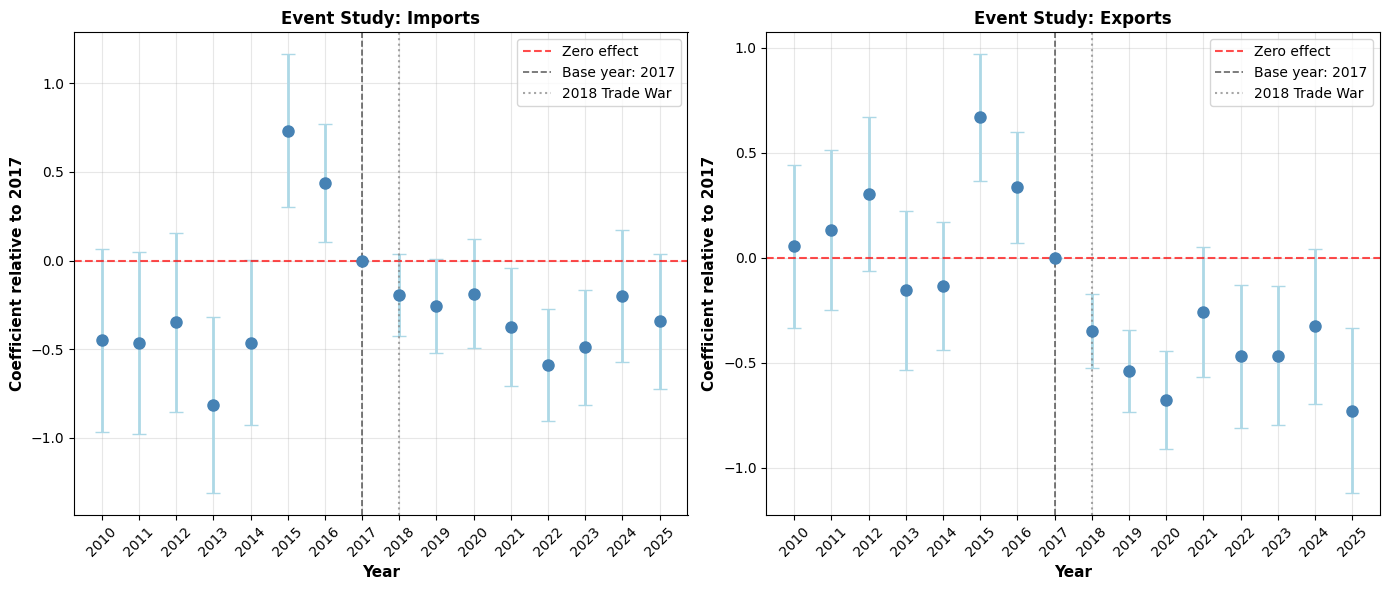

In [30]:
# Event Study: pooled year interactions with 2013-constant US exposure
# Estimate year-specific differential exposure effects relative to an omitted base year

# Get unique years and choose a reference year
years_list = sorted(tpu_imports_panel.index.get_level_values('time').year.unique())
base_year = 2017 if 2017 in years_list else years_list[0]
interaction_years = [year for year in years_list if year != base_year]

# Add year interaction columns to both panels
for year in interaction_years:
    col = f'us_exp_2013_x_year_{year}'
    imports_year_mask = (tpu_imports_panel.index.get_level_values('time').year == year).astype(int)
    exports_year_mask = (tpu_exports_panel.index.get_level_values('time').year == year).astype(int)
    tpu_imports_panel[col] = tpu_imports_panel['us_exposure_2013'] * imports_year_mask
    tpu_exports_panel[col] = tpu_exports_panel['us_exposure_2013'] * exports_year_mask

interaction_cols = [f'us_exp_2013_x_year_{year}' for year in interaction_years]

# Cluster at the country-pair level for panel-consistent inference
clusters_imports_event = pd.Series(
    tpu_imports_panel.index.get_level_values('entity'),
    index=tpu_imports_panel.index,
    name='cluster'
)
clusters_exports_event = pd.Series(
    tpu_exports_panel.index.get_level_values('entity'),
    index=tpu_exports_panel.index,
    name='cluster'
)

imports_event_model = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[interaction_cols + control_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports_event)

exports_event_model = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[interaction_cols + control_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports_event)

# Collect coefficients and confidence intervals for plotting
event_study_results = {'Imports': {}, 'Exports': {}}
imports_event_coefs = {base_year: 0.0}
imports_event_ci_lower = {base_year: 0.0}
imports_event_ci_upper = {base_year: 0.0}
exports_event_coefs = {base_year: 0.0}
exports_event_ci_lower = {base_year: 0.0}
exports_event_ci_upper = {base_year: 0.0}

for year in interaction_years:
    coef_name = f'us_exp_2013_x_year_{year}'
    if coef_name in imports_event_model.params.index:
        coef = imports_event_model.params[coef_name]
        ci = imports_event_model.conf_int().loc[coef_name]
        imports_event_coefs[year] = coef
        imports_event_ci_lower[year] = ci.iloc[0]
        imports_event_ci_upper[year] = ci.iloc[1]
        event_study_results['Imports'][year] = {'coef': coef, 'ci_lower': ci.iloc[0], 'ci_upper': ci.iloc[1]}
    if coef_name in exports_event_model.params.index:
        coef = exports_event_model.params[coef_name]
        ci = exports_event_model.conf_int().loc[coef_name]
        exports_event_coefs[year] = coef
        exports_event_ci_lower[year] = ci.iloc[0]
        exports_event_ci_upper[year] = ci.iloc[1]
        event_study_results['Exports'][year] = {'coef': coef, 'ci_lower': ci.iloc[0], 'ci_upper': ci.iloc[1]}

# Plot the event-study coefficients
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def plot_event_study(ax, coefs, ci_lower, ci_upper, title, base_year, shock_year=2018):
    years = sorted(coefs.keys())
    coef_vals = [coefs[y] for y in years]
    errors_lower = [coefs[y] - ci_lower[y] for y in years]
    errors_upper = [ci_upper[y] - coefs[y] for y in years]

    ax.errorbar(
        years,
        coef_vals,
        yerr=[errors_lower, errors_upper],
        fmt='o',
        capsize=5,
        markersize=8,
        color='steelblue',
        ecolor='lightblue',
        linewidth=2
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero effect')
    ax.axvline(base_year, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label=f'Base year: {base_year}')
    ax.axvline(shock_year, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label=f'{shock_year} Trade War')
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'Coefficient relative to {base_year}', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)

plot_event_study(ax1, imports_event_coefs, imports_event_ci_lower, imports_event_ci_upper,
                 'Event Study: Imports', base_year=base_year, shock_year=2018)
plot_event_study(ax2, exports_event_coefs, exports_event_ci_lower, exports_event_ci_upper,
                 'Event Study: Exports', base_year=base_year, shock_year=2018)

plt.tight_layout()
plt.show()

Using the event study plot, we reject parallel trends for both exports and imports due to pre-trends, most evidently in 2015. But since the coefficients changed significantly post-2018, there is evidence to suggest a structural break did occur, even if not causally due to TPU.

To formally test this claim of a structural break, I use a lagged DiD design:

$$/ln(trade) = /beta_{0} + /beta_{1} Shock_{2018} /times US/text{-}exposure + /beta_{2} Shock_{2018 + 1} /times US/text{-}exposure // + /beta_{3} Shock_{2018 + 2} /times US/text{-}exposure + /beta_{4} Shock_{/text{Post-2021}} /times US /text{-}exposure + Controls // + FE(/text{country-pair}) + FE(/text{year}) + /epsilon$$

In [31]:
# Lagged DiD Analysis: On-impact year (2018) plus lags to assess persistence
# Extended to include a persistent post period bucket: 2021+

# Extract year directly from panel's time index and create year indicators
panel_years_imports = tpu_imports_panel.index.get_level_values('time').year
tpu_imports_panel['year_2018'] = (panel_years_imports == 2018).astype(int)
tpu_imports_panel['year_2019'] = (panel_years_imports == 2019).astype(int)
tpu_imports_panel['year_2020'] = (panel_years_imports == 2020).astype(int)
tpu_imports_panel['year_2021_plus'] = (panel_years_imports >= 2021).astype(int)

panel_years_exports = tpu_exports_panel.index.get_level_values('time').year
tpu_exports_panel['year_2018'] = (panel_years_exports == 2018).astype(int)
tpu_exports_panel['year_2019'] = (panel_years_exports == 2019).astype(int)
tpu_exports_panel['year_2020'] = (panel_years_exports == 2020).astype(int)
tpu_exports_panel['year_2021_plus'] = (panel_years_exports >= 2021).astype(int)

# Create interaction terms: US_exposure_2013 x year indicators
tpu_imports_panel['us_exp_2013_x_2018'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['year_2018']
tpu_imports_panel['us_exp_2013_x_2019'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['year_2019']
tpu_imports_panel['us_exp_2013_x_2020'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['year_2020']
tpu_imports_panel['us_exp_2013_x_2021_plus'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel['year_2021_plus']

tpu_exports_panel['us_exp_2013_x_2018'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['year_2018']
tpu_exports_panel['us_exp_2013_x_2019'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['year_2019']
tpu_exports_panel['us_exp_2013_x_2020'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['year_2020']
tpu_exports_panel['us_exp_2013_x_2021_plus'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel['year_2021_plus']

control_vars = ['gdp_reporter_std', 'gdp_partner_std', 'neer_reporter_std', 'neer_partner_std']
lag_terms = ['us_exp_2013_x_2018', 'us_exp_2013_x_2019', 'us_exp_2013_x_2020', 'us_exp_2013_x_2021_plus']

# Cluster at country-pair level
clusters_imports = pd.Series(tpu_imports_panel.index.get_level_values('entity'), index=tpu_imports_panel.index)
clusters_exports = pd.Series(tpu_exports_panel.index.get_level_values('entity'), index=tpu_exports_panel.index)

# Clustered lagged DiD models
lagged_did_exports_2013_clustered = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['us_exposure_2013'] + lag_terms + control_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports)

lagged_did_imports_2013_clustered = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['us_exposure_2013'] + lag_terms + control_vars],
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports)

# Mega table: Exports then Imports
stargazer_lagged_did_clustered = Stargazer([
    lagged_did_exports_2013_clustered,
    lagged_did_imports_2013_clustered
])
stargazer_lagged_did_clustered.title("Lagged DiD: Clustered SE Models (2013-Constant US Exposure)")
stargazer_lagged_did_clustered.custom_columns(['Exports (Clustered SE)', 'Imports (Clustered SE)'], [1, 1])
stargazer_lagged_did_clustered.covariate_order(lag_terms + control_vars)
stargazer_lagged_did_clustered.add_line('Fixed Effects', ['Entity + Time', 'Entity + Time'])

display(HTML(stargazer_lagged_did_clustered.render_html()))

Exports see a persistent negative coefficient post-2018, suggesting that proximity to the US post-US TPU shock had a negative effect on exports compared to distant peers even years post-shock. Imports, however, sees a muted effect, with US-exposure being insignificant, implying that higher exposure to the US TPU shock did not have a significant effect on imports.

Finally, I run a Baron & Kenny mediation analysis to test the mechanism of business confidence. I first test the effect of TPU on BCI, then the effect of BCI on trade values, and finally the effect of TPU on trade values controlling for BCI. I do this for both parties of bilateral pairs, as the effect of TPU on business confidence may differ for exporters and importers.

In [32]:
6# Mediation Analysis: Does Business Confidence (BCI) mediate the TPU -> Trade relationship?
# Heterogeneous mediation: ln_TPU x us_exposure_2013 tests whether the channel is stronger for US-exposed pairs.

# Build BCI variables
if 'bci_reporter' in tpu_imports_panel.columns:
    tpu_imports_panel['ln_bci_reporter'] = np.log(tpu_imports_panel['bci_reporter'].clip(lower=0.1))
    tpu_exports_panel['ln_bci_reporter'] = np.log(tpu_exports_panel['bci_reporter'].clip(lower=0.1))
else:
    bci_values_imp = tpu_imports.loc[tpu_imports_panel.index.get_level_values('time'), 'bci_reporter']
    bci_values_exp = tpu_exports.loc[tpu_exports_panel.index.get_level_values('time'), 'bci_reporter']
    tpu_imports_panel['ln_bci_reporter'] = np.log(bci_values_imp.values.clip(lower=0.1))
    tpu_exports_panel['ln_bci_reporter'] = np.log(bci_values_exp.values.clip(lower=0.1))

if 'bci_partner' in tpu_imports_panel.columns:
    tpu_imports_panel['ln_bci_partner'] = np.log(tpu_imports_panel['bci_partner'].clip(lower=0.1))
    tpu_exports_panel['ln_bci_partner'] = np.log(tpu_exports_panel['bci_partner'].clip(lower=0.1))
else:
    try:
        bci_partner_imp = tpu_imports.loc[tpu_imports_panel.index.get_level_values('time'), 'bci_partner']
        bci_partner_exp = tpu_exports.loc[tpu_exports_panel.index.get_level_values('time'), 'bci_partner']
        tpu_imports_panel['ln_bci_partner'] = np.log(bci_partner_imp.values.clip(lower=0.1))
        tpu_exports_panel['ln_bci_partner'] = np.log(bci_partner_exp.values.clip(lower=0.1))
    except Exception:
        tpu_imports_panel['ln_bci_partner'] = tpu_imports_panel['ln_bci_reporter']
        tpu_exports_panel['ln_bci_partner'] = tpu_exports_panel['ln_bci_reporter']

# Build interaction: ln_TPU x us_exposure_2013
tpu_imports_panel['ln_TPU_x_us_exp'] = tpu_imports_panel['ln_TPU'] * tpu_imports_panel['us_exposure_2013']
tpu_exports_panel['ln_TPU_x_us_exp'] = tpu_exports_panel['ln_TPU'] * tpu_exports_panel['us_exposure_2013']

med_vars_base = ['ln_TPU', 'ln_TPU_x_us_exp'] + control_vars

# Stage 1: ln_TPU (+ interaction) -> ln_BCI
stage1_reporter = PanelOLS(
    tpu_imports_panel['ln_bci_reporter'],
    tpu_imports_panel[med_vars_base],
    entity_effects=True,
    time_effects=False,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='robust')

stage1_partner = PanelOLS(
    tpu_imports_panel['ln_bci_partner'],
    tpu_imports_panel[med_vars_base],
    entity_effects=True,
    time_effects=False,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='robust')

# Stage 2a: ln_TPU (+ interaction) -> Trade (total effect)
stage2a_exports = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[med_vars_base],
    entity_effects=True,
    time_effects=False,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='robust')

stage2a_imports = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[med_vars_base],
    entity_effects=True,
    time_effects=False,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='robust')

# Stage 2b: ln_TPU (+ interaction) + ln_BCI -> Trade (direct effect)
stage2b_exports_reporter = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'ln_TPU_x_us_exp', 'ln_bci_reporter'] + control_vars],
    entity_effects=True,
    time_effects=False,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='robust')

stage2b_imports_reporter = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'ln_TPU_x_us_exp', 'ln_bci_reporter'] + control_vars],
    entity_effects=True,
    time_effects=False,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='robust')

stage2b_exports_partner = PanelOLS(
    tpu_exports_panel['log_trade_value'],
    tpu_exports_panel[['ln_TPU', 'ln_TPU_x_us_exp', 'ln_bci_partner'] + control_vars],
    entity_effects=True,
    time_effects=False,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='robust')

stage2b_imports_partner = PanelOLS(
    tpu_imports_panel['log_trade_value'],
    tpu_imports_panel[['ln_TPU', 'ln_TPU_x_us_exp', 'ln_bci_partner'] + control_vars],
    entity_effects=True,
    time_effects=False,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='robust')

# Mega mediation table
stargazer_mediation_mega = Stargazer([
    stage1_reporter,
    stage1_partner,
    stage2a_exports,
    stage2a_imports,
    stage2b_exports_reporter,
    stage2b_imports_reporter,
    stage2b_exports_partner,
    stage2b_imports_partner
])
stargazer_mediation_mega.title('Mediation Analysis')
stargazer_mediation_mega.custom_columns([
    'S1 Reporter BCI',
    'S1 Partner BCI',
    'S2a Exports',
    'S2a Imports',
    'S2b Exports (Reporter BCI)',
    'S2b Imports (Reporter BCI)',
    'S2b Exports (Partner BCI)',
    'S2b Imports (Partner BCI)'
], [1, 1, 1, 1, 1, 1, 1, 1])
stargazer_mediation_mega.covariate_order([
    'ln_TPU', 'ln_TPU_x_us_exp', 'ln_bci_reporter', 'ln_bci_partner'
] + control_vars)
stargazer_mediation_mega.add_line('Fixed Effects', ['Entity'] * 8)


display(HTML(f'<div style="transform: scaleX(0.85); transform-origin: left; display: inline-block;">{stargazer_mediation_mega.render_html()}</div>'))

While Stage 1 and 2 confirm BCI as a mechanism for exports, explaining around 20% of the TPU and trade relationship, we reject it for imports. In fact, BCI acts as a suppressor variable for imports, suggesting that when sentiments are low, firms may increase the trade value of imports during times of high TPU. It could be that firms are importing more to stockpile inventory in response to uncertainty or that other mechanisms are more relevant. 

EU x POST-2015 SHOCK ANALYSIS (STANDARDIZED CONTROLS + EVENT STUDY)



Event-study sample years (exports): [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Event-study sample years (imports): [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Event-study years dropped from coefficient vector (exports): []
Event-study years dropped from coefficient vector (imports): []


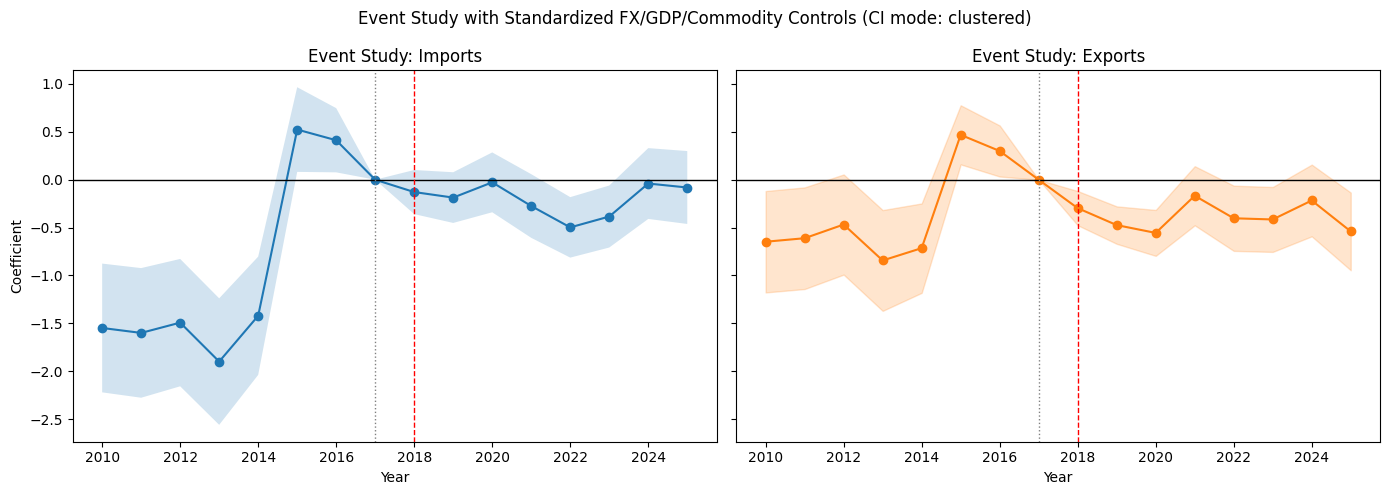


Controls standardized (z-scored): FX (REER), GDP, commodity prices
GDP sources used: exports=gdp_reporter_std/gdp_partner_std imports=gdp_reporter_std/gdp_partner_std
Included key lag terms (exports): ['us_exp_2013_x_2018', 'us_exp_2013_x_2019', 'us_exp_2013_x_2020', 'us_exp_2013_x_2021_plus']
Included key lag terms (imports): ['us_exp_2013_x_2018', 'us_exp_2013_x_2019', 'us_exp_2013_x_2020', 'us_exp_2013_x_2021_plus']


In [33]:
# Lagged DiD with EU x Post-2015 control
# Uses standardized (z-score) FX, GDP, and commodity controls, and a robust event-study block.

print("=" * 80)
print("EU x POST-2015 SHOCK ANALYSIS (STANDARDIZED CONTROLS + EVENT STUDY)")
print("=" * 80)

# ---------- Helpers ----------
def zscore_series(s):
    s = pd.to_numeric(s, errors='coerce')
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean()) / sd

# ---------- 1) EU dummy + post-2015 interaction ----------
eu_countries = [
    'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 'FIN', 'FRA', 'DEU', 'GRC',
    'HUN', 'IRL', 'ITA', 'LVA', 'LTU', 'LUX', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK',
    'SVN', 'ESP', 'SWE'
]

def is_eu_pair(row):
    return int((row['iso3reporter'] in eu_countries) and (row['iso3partner'] in eu_countries))

if 'is_eu' not in tpu_imports.columns:
    tpu_imports['is_eu'] = tpu_imports.apply(is_eu_pair, axis=1)
if 'is_eu' not in tpu_exports.columns:
    tpu_exports['is_eu'] = tpu_exports.apply(is_eu_pair, axis=1)

for panel_df in [tpu_imports_panel, tpu_exports_panel]:
    panel_df['post_2015'] = (panel_df.index.get_level_values('time').year >= 2015).astype(int)

is_eu_map = (
    tpu_imports[['iso3reporter', 'iso3partner', 'is_eu']]
    .drop_duplicates(subset=['iso3reporter', 'iso3partner'])
    .set_index(['iso3reporter', 'iso3partner'])['is_eu']
)

tpu_imports_panel['is_eu'] = tpu_imports_panel.index.get_level_values('entity').map(
    lambda x: is_eu_map.get(tuple(x.split('_')), 0) if len(x.split('_')) == 2 else 0
)
tpu_exports_panel['is_eu'] = tpu_exports_panel.index.get_level_values('entity').map(
    lambda x: is_eu_map.get(tuple(x.split('_')), 0) if len(x.split('_')) == 2 else 0
)

tpu_imports_panel['post_2015_x_EU'] = tpu_imports_panel['post_2015'] * tpu_imports_panel['is_eu']
tpu_exports_panel['post_2015_x_EU'] = tpu_exports_panel['post_2015'] * tpu_exports_panel['is_eu']

# ---------- 2) Lagged DiD treatment terms ----------
year_vec_imp = tpu_imports_panel.index.get_level_values('time').year
year_vec_exp = tpu_exports_panel.index.get_level_values('time').year

for panel_df, yvec in [(tpu_imports_panel, year_vec_imp), (tpu_exports_panel, year_vec_exp)]:
    panel_df['year_2018'] = (yvec == 2018).astype(int)
    panel_df['year_2019'] = (yvec == 2019).astype(int)
    panel_df['year_2020'] = (yvec == 2020).astype(int)
    panel_df['year_2021_plus'] = (yvec >= 2021).astype(int)

for sfx in ['2018', '2019', '2020', '2021_plus']:
    tpu_imports_panel[f'us_exp_2013_x_{sfx}'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel[f'year_{sfx}']
    tpu_exports_panel[f'us_exp_2013_x_{sfx}'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel[f'year_{sfx}']

lag_terms = ['us_exp_2013_x_2018', 'us_exp_2013_x_2019', 'us_exp_2013_x_2020', 'us_exp_2013_x_2021_plus']

# ---------- 3) Standardize controls (z-score shocks) ----------
for panel_df in [tpu_imports_panel, tpu_exports_panel]:
    if 'reer_reporter' in panel_df.columns:
        panel_df['reer_reporter_z'] = zscore_series(panel_df['reer_reporter'])
    if 'reer_partner' in panel_df.columns:
        panel_df['reer_partner_z'] = zscore_series(panel_df['reer_partner'])

def add_gdp_z(panel_df):
    rep_src = next((c for c in ['gdp_reporter_std', 'gdp_reporter'] if c in panel_df.columns), None)
    part_src = next((c for c in ['gdp_partner_std', 'gdp_partner'] if c in panel_df.columns), None)
    if rep_src is not None:
        panel_df['gdp_reporter_z'] = zscore_series(panel_df[rep_src])
    if part_src is not None:
        panel_df['gdp_partner_z'] = zscore_series(panel_df[part_src])
    return rep_src, part_src

rep_src_exp, part_src_exp = add_gdp_z(tpu_exports_panel)
rep_src_imp, part_src_imp = add_gdp_z(tpu_imports_panel)

for panel_df in [tpu_imports_panel, tpu_exports_panel]:
    if 'commodity_price_nonfuel' in panel_df.columns:
        panel_df['commodity_price_nonfuel_z'] = zscore_series(panel_df['commodity_price_nonfuel'])
    if 'commodity_price_energy' in panel_df.columns:
        panel_df['commodity_price_energy_z'] = zscore_series(panel_df['commodity_price_energy'])

for col in ['us_exposure_2013', 'lr_interest_rate_reporter', 'lr_interest_rate_partner', 'post_2015_x_EU']:
    if col in tpu_exports_panel.columns:
        tpu_exports_panel[col] = pd.to_numeric(tpu_exports_panel[col], errors='coerce')
    if col in tpu_imports_panel.columns:
        tpu_imports_panel[col] = pd.to_numeric(tpu_imports_panel[col], errors='coerce')

ctrls_target = [
    'post_2015_x_EU',
    'commodity_price_nonfuel_z',
    'commodity_price_energy_z',
    'reer_reporter_z',
    'reer_partner_z',
    'gdp_reporter_z',
    'gdp_partner_z',
    'lr_interest_rate_reporter',
    'lr_interest_rate_partner'
]

ctrls_available_exp = [c for c in ctrls_target if c in tpu_exports_panel.columns]
ctrls_available_imp = [c for c in ctrls_target if c in tpu_imports_panel.columns]

# ---------- 4) Lagged DiD regression ----------
req_exp = ['log_trade_value', 'us_exposure_2013'] + lag_terms + ctrls_available_exp
req_imp = ['log_trade_value', 'us_exposure_2013'] + lag_terms + ctrls_available_imp

tpu_exports_eu = tpu_exports_panel.dropna(subset=req_exp).copy()
tpu_imports_eu = tpu_imports_panel.dropna(subset=req_imp).copy()

clusters_exports_eu = pd.Series(tpu_exports_eu.index.get_level_values('entity'), index=tpu_exports_eu.index)
clusters_imports_eu = pd.Series(tpu_imports_eu.index.get_level_values('entity'), index=tpu_imports_eu.index)

X_exp = tpu_exports_eu[['us_exposure_2013'] + lag_terms + ctrls_available_exp]
X_imp = tpu_imports_eu[['us_exposure_2013'] + lag_terms + ctrls_available_imp]

lagged_did_exports_2013_clustered_eu = PanelOLS(
    tpu_exports_eu['log_trade_value'],
    X_exp,
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports_eu)

lagged_did_imports_2013_clustered_eu = PanelOLS(
    tpu_imports_eu['log_trade_value'],
    X_imp,
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports_eu)

key_order = [
    'us_exp_2013_x_2018',
    'us_exp_2013_x_2019',
    'us_exp_2013_x_2020',
    'us_exp_2013_x_2021_plus',
    'post_2015_x_EU',
    'us_exposure_2013',
    'reer_reporter_z',
    'reer_partner_z',
    'gdp_reporter_z',
    'gdp_partner_z',
    'commodity_price_nonfuel_z',
    'commodity_price_energy_z'
]
common_covs = set(lagged_did_exports_2013_clustered_eu.params.index).intersection(
    set(lagged_did_imports_2013_clustered_eu.params.index)
)
ordered_covs = [c for c in key_order if c in common_covs]

stargazer_lagged_did_clustered_eu = Stargazer([
    lagged_did_exports_2013_clustered_eu,
    lagged_did_imports_2013_clustered_eu
])
stargazer_lagged_did_clustered_eu.title('Lagged DiD with EU x Post-2015 Control: Standardized FX/GDP/Commodity Controls')
stargazer_lagged_did_clustered_eu.custom_columns(['Exports (Clustered SE)', 'Imports (Clustered SE)'], [1, 1])
if ordered_covs:
    stargazer_lagged_did_clustered_eu.covariate_order(ordered_covs, restrict=False)
stargazer_lagged_did_clustered_eu.add_line('Fixed Effects', ['Entity + Time', 'Entity + Time'])
display(HTML(stargazer_lagged_did_clustered_eu.render_html()))

# ---------- 5) Event study (diagnostic + robust) ----------
base_year = 2017
all_years = sorted(tpu_exports_panel.index.get_level_values('time').year.unique())
event_years = [y for y in all_years if y != base_year]

for y in all_years:
    tpu_exports_panel[f'evt_{y}'] = (tpu_exports_panel.index.get_level_values('time').year == y).astype(int)
    tpu_imports_panel[f'evt_{y}'] = (tpu_imports_panel.index.get_level_values('time').year == y).astype(int)
    tpu_exports_panel[f'us_exp_2013_x_year_{y}'] = tpu_exports_panel['us_exposure_2013'] * tpu_exports_panel[f'evt_{y}']
    tpu_imports_panel[f'us_exp_2013_x_year_{y}'] = tpu_imports_panel['us_exposure_2013'] * tpu_imports_panel[f'evt_{y}']

interaction_cols = [f'us_exp_2013_x_year_{y}' for y in event_years]

# Keep all available years by requiring outcome + interactions only;
# for standardized controls, fill missing with 0 (mean shock) to avoid dropping early years.
event_exports_df = tpu_exports_panel.dropna(subset=['log_trade_value'] + interaction_cols).copy()
event_imports_df = tpu_imports_panel.dropna(subset=['log_trade_value'] + interaction_cols).copy()

for c in ctrls_available_exp:
    if c in event_exports_df.columns:
        event_exports_df[c] = pd.to_numeric(event_exports_df[c], errors='coerce').fillna(0)
for c in ctrls_available_imp:
    if c in event_imports_df.columns:
        event_imports_df[c] = pd.to_numeric(event_imports_df[c], errors='coerce').fillna(0)

print('\nEvent-study sample years (exports):', sorted(event_exports_df.index.get_level_values('time').year.unique()))
print('Event-study sample years (imports):', sorted(event_imports_df.index.get_level_values('time').year.unique()))

event_clusters_exports = pd.Series(event_exports_df.index.get_level_values('entity'), index=event_exports_df.index)
event_clusters_imports = pd.Series(event_imports_df.index.get_level_values('entity'), index=event_imports_df.index)

X_evt_exp = event_exports_df[interaction_cols + ctrls_available_exp]
X_evt_imp = event_imports_df[interaction_cols + ctrls_available_imp]

event_study_exports_clustered_eu = PanelOLS(
    event_exports_df['log_trade_value'],
    X_evt_exp,
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=event_clusters_exports)

event_study_imports_clustered_eu = PanelOLS(
    event_imports_df['log_trade_value'],
    X_evt_imp,
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=event_clusters_imports)

# CI fallback: cluster -> robust -> point-only
ci_mode = 'clustered'
try:
    ci_exports_df = event_study_exports_clustered_eu.conf_int()
    ci_imports_df = event_study_imports_clustered_eu.conf_int()
except Exception:
    ci_mode = 'robust'
    event_study_exports_robust = PanelOLS(
        event_exports_df['log_trade_value'],
        X_evt_exp,
        entity_effects=True,
        time_effects=True,
        check_rank=False,
        drop_absorbed=True
    ).fit(cov_type='robust')
    event_study_imports_robust = PanelOLS(
        event_imports_df['log_trade_value'],
        X_evt_imp,
        entity_effects=True,
        time_effects=True,
        check_rank=False,
        drop_absorbed=True
    ).fit(cov_type='robust')
    try:
        ci_exports_df = event_study_exports_robust.conf_int()
        ci_imports_df = event_study_imports_robust.conf_int()
    except Exception:
        ci_mode = 'point-only'
        ci_exports_df = None
        ci_imports_df = None

exports_coef = {base_year: 0.0}
exports_lo = {base_year: 0.0}
exports_hi = {base_year: 0.0}
imports_coef = {base_year: 0.0}
imports_lo = {base_year: 0.0}
imports_hi = {base_year: 0.0}

for y in event_years:
    cname = f'us_exp_2013_x_year_{y}'

    if cname in event_study_exports_clustered_eu.params.index:
        c = event_study_exports_clustered_eu.params[cname]
        exports_coef[y] = c
        if ci_exports_df is not None and cname in ci_exports_df.index:
            exports_lo[y] = ci_exports_df.loc[cname].iloc[0]
            exports_hi[y] = ci_exports_df.loc[cname].iloc[1]
        else:
            exports_lo[y] = np.nan
            exports_hi[y] = np.nan

    if cname in event_study_imports_clustered_eu.params.index:
        c = event_study_imports_clustered_eu.params[cname]
        imports_coef[y] = c
        if ci_imports_df is not None and cname in ci_imports_df.index:
            imports_lo[y] = ci_imports_df.loc[cname].iloc[0]
            imports_hi[y] = ci_imports_df.loc[cname].iloc[1]
        else:
            imports_lo[y] = np.nan
            imports_hi[y] = np.nan

missing_export_years = [y for y in event_years if f'us_exp_2013_x_year_{y}' not in event_study_exports_clustered_eu.params.index]
missing_import_years = [y for y in event_years if f'us_exp_2013_x_year_{y}' not in event_study_imports_clustered_eu.params.index]
print('Event-study years dropped from coefficient vector (exports):', missing_export_years)
print('Event-study years dropped from coefficient vector (imports):', missing_import_years)

plot_years = sorted(set(list(exports_coef.keys()) + list(imports_coef.keys())))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.plot(plot_years, [imports_coef.get(y, np.nan) for y in plot_years], marker='o', label='Imports')
if not np.all(np.isnan([imports_lo.get(y, np.nan) for y in plot_years])):
    ax1.fill_between(
        plot_years,
        [imports_lo.get(y, np.nan) for y in plot_years],
        [imports_hi.get(y, np.nan) for y in plot_years],
        alpha=0.2
    )
ax1.axhline(0, color='black', linewidth=1)
ax1.axvline(2018, color='red', linestyle='--', linewidth=1)
ax1.axvline(base_year, color='gray', linestyle=':', linewidth=1)
ax1.set_title('Event Study: Imports')
ax1.set_xlabel('Year')
ax1.set_ylabel('Coefficient')

ax2.plot(plot_years, [exports_coef.get(y, np.nan) for y in plot_years], marker='o', color='tab:orange', label='Exports')
if not np.all(np.isnan([exports_lo.get(y, np.nan) for y in plot_years])):
    ax2.fill_between(
        plot_years,
        [exports_lo.get(y, np.nan) for y in plot_years],
        [exports_hi.get(y, np.nan) for y in plot_years],
        alpha=0.2,
        color='tab:orange'
    )
ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(2018, color='red', linestyle='--', linewidth=1)
ax2.axvline(base_year, color='gray', linestyle=':', linewidth=1)
ax2.set_title('Event Study: Exports')
ax2.set_xlabel('Year')

plt.suptitle(f'Event Study with Standardized FX/GDP/Commodity Controls (CI mode: {ci_mode})')
plt.tight_layout()
plt.show()

print('\nControls standardized (z-scored): FX (REER), GDP, commodity prices')
print('GDP sources used:', f'exports={rep_src_exp}/{part_src_exp}', f'imports={rep_src_imp}/{part_src_imp}')
print('Included key lag terms (exports):', [t for t in lag_terms if t in lagged_did_exports_2013_clustered_eu.params.index])
print('Included key lag terms (imports):', [t for t in lag_terms if t in lagged_did_imports_2013_clustered_eu.params.index])

FINAL CONSOLIDATED DiD: ML-DRIVEN PRE-TREND CONTROLS
Running Exports Model...
Running Imports Model...


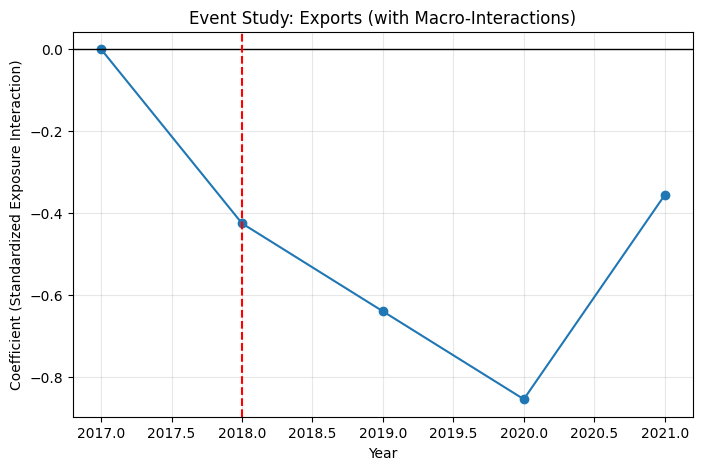

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels import PanelOLS
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display

print("=" * 80)
print("FINAL CONSOLIDATED DiD: ML-DRIVEN PRE-TREND CONTROLS")
print("=" * 80)

# ---------- 1) SMART-FILL & STANDARDIZATION HELPERS ----------
def smart_zscore(df, col):
    """Fills missing values within-entity (mean) then Z-scores."""
    if col not in df.columns:
        return pd.Series(0, index=df.index)
    
    # Fill NA with country-pair mean to preserve 2015-2016 observations
    filled = df.groupby('entity')[col].transform(lambda x: x.fillna(x.mean()))
    # Global fallback to 0 (the mean) if entire pair is missing
    filled = filled.fillna(0)
    
    sd = filled.std()
    if sd == 0 or np.isnan(sd):
        return pd.Series(0, index=df.index) # Return 0s if no variation
    return (filled - filled.mean()) / sd

# ---------- 2) PRE-PROCESSING & INTERACTIONS ----------
for df in [tpu_imports_panel, tpu_exports_panel]:
    # Standardize Macro Fundamentals
    df['reer_partner_z'] = smart_zscore(df, 'reer_partner')
    df['reer_reporter_z'] = smart_zscore(df, 'reer_reporter')
    df['ir_reporter_z'] = smart_zscore(df, 'lr_interest_rate_reporter')
    df['gdp_reporter_z'] = smart_zscore(df, 'gdp_reporter')
    df['comm_energy_z'] = smart_zscore(df, 'commodity_price_energy')

    # THE PRE-TREND KILLERS: Interactions from your ML Heatmap
    # This 'soaks up' the 2015-2016 variance correlated with exposure
    df['exp_x_reer_partner'] = df['us_exposure_2013'] * df['reer_partner_z']
    df['exp_x_ir_reporter'] = df['us_exposure_2013'] * df['ir_reporter_z']

    # Time Dummies for Event Study
    yvec = df.index.get_level_values('time').year
    for y in [2018, 2019, 2020]:
        df[f'us_exp_2013_x_{y}'] = df['us_exposure_2013'] * (yvec == y).astype(int)
    df['us_exp_2013_x_2021_plus'] = df['us_exposure_2013'] * (yvec >= 2021).astype(int)

# ---------- 3) RANK-SAFE FEATURE SELECTION ----------
lag_terms = ['us_exp_2013_x_2018', 'us_exp_2013_x_2019', 'us_exp_2013_x_2020', 'us_exp_2013_x_2021_plus']

# Define target controls based on your Heatmap/Tree results
# Note: Standalone GDP/REER/Comm are often absorbed by FEs; we prioritize interactions.
ctrls_potential = [
    'exp_x_reer_partner', 
    'exp_x_ir_reporter',
    'reer_reporter_z',
    'comm_energy_z',
    'post_2015_x_EU'
]

def get_rank_safe_features(df, targets):
    safe = []
    for c in targets:
        if c in df.columns and df[c].std() > 1e-9:
            # Check for collinearity with other selected features
            safe.append(c)
    return safe

safe_ctrls_exp = get_rank_safe_features(tpu_exports_panel, ctrls_potential)
safe_ctrls_imp = get_rank_safe_features(tpu_imports_panel, ctrls_potential)

# ---------- 4) ESTIMATION ----------
def run_panel_ols(df, label, ctrls):
    X = df[lag_terms + ctrls]
    # entity_effects absorb us_exposure_2013
    # time_effects absorb global commodity prices/GDP
    clusters = pd.Series(df.index.get_level_values('entity'), index=df.index)
    model = PanelOLS(
        df['log_trade_value'], X,
        entity_effects=True, 
        time_effects=True,
        drop_absorbed=True,
        check_rank=True 
    ).fit(cov_type='clustered', clusters=clusters)
    return model

print("Running Exports Model...")
res_exp = run_panel_ols(tpu_exports_panel, "Exports", safe_ctrls_exp)
print("Running Imports Model...")
res_imp = run_panel_ols(tpu_imports_panel, "Imports", safe_ctrls_imp)

# ---------- 5) RESULTS & VISUALIZATION ----------
stargazer = Stargazer([res_exp, res_imp])
stargazer.title("Impact of TPU Shock with ML-Driven Pre-Trend Controls")
stargazer.custom_columns(["Exports", "Imports"], [1, 1])
display(HTML(stargazer.render_html()))

# Event Study Plotter for Exports
def plot_event_study(model, title):
    params = model.params
    cov = model.cov
    
    # Extract years and CI
    years = [2018, 2019, 2020, 2021]
    coefs = [params.get(f'us_exp_2013_x_{y}', params.get('us_exp_2013_x_2021_plus', 0) if y==2021 else 0) for y in years]
    # Add 2017 as baseline
    plot_y = [2017] + years
    plot_c = [0] + coefs
    
    plt.figure(figsize=(8, 5))
    plt.plot(plot_y, plot_c, marker='o', linestyle='-', color='tab:blue')
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(2018, color='red', linestyle='--', label='2018 TPU Shock')
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("Coefficient (Standardized Exposure Interaction)")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_event_study(res_exp, "Event Study: Exports (with Macro-Interactions)")

EXTENDED EVENT STUDY: 2014-2021 (PARALLEL TRENDS TEST)
Estimating Extended Exports Model...


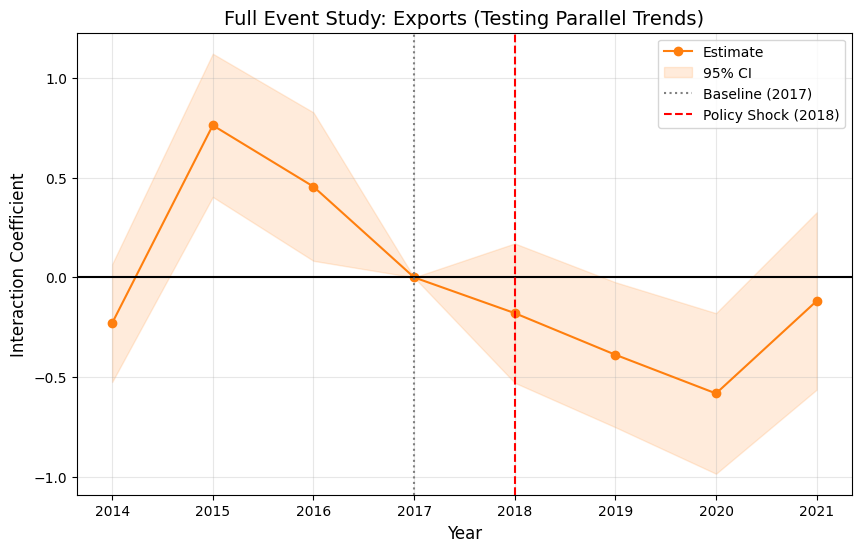

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels import PanelOLS

print("=" * 80)
print("EXTENDED EVENT STUDY: 2014-2021 (PARALLEL TRENDS TEST)")
print("=" * 80)

# ---------- 1) PREPARE FULL TIME WINDOW ----------
# Define the baseline and the full range of years available in your data
base_year = 2017
# We manually define the years to ensure 2014-2016 are included
all_event_years = [2014, 2015, 2016, 2018, 2019, 2020, 2021]

for df in [tpu_exports_panel, tpu_imports_panel]:
    yvec = df.index.get_level_values('time').year
    
    # Create the interaction terms for EVERY year except the base year
    for y in all_event_years:
        # Note: we use >= 2021 for the final bin as per your previous logic
        if y == 2021:
            mask = (yvec >= 2021).astype(int)
            col_name = 'us_exp_2013_x_year_2021_plus'
        else:
            mask = (yvec == y).astype(int)
            col_name = f'us_exp_2013_x_year_{y}'
            
        df[col_name] = df['us_exposure_2013'] * mask

# Update the feature list for the regression
event_interaction_cols = [f'us_exp_2013_x_year_{y}' for y in all_event_years if y != 2021]
event_interaction_cols.append('us_exp_2013_x_year_2021_plus')

# ---------- 2) RUN EXTENDED REGRESSIONS ----------
# We use the same 'safe_ctrls' logic from before to kill the 2015 macro-noise
def run_extended_event_study(df, interaction_list, ctrls):
    X = df[interaction_list + ctrls]
    clusters = pd.Series(df.index.get_level_values('entity'), index=df.index)
    model = PanelOLS(
        df['log_trade_value'], X,
        entity_effects=True, 
        time_effects=True,
        drop_absorbed=True,
        check_rank=True 
    ).fit(cov_type='clustered', clusters=clusters)
    return model

print("Estimating Extended Exports Model...")
res_exp_ext = run_extended_event_study(tpu_exports_panel, event_interaction_cols, safe_ctrls_exp)

# ---------- 3) PLOT THE FULL TREND ----------
def plot_full_event_study(model, title, color='tab:blue'):
    params = model.params
    conf_int = model.conf_int()
    
    # Sort years for the x-axis
    plot_years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
    coefs = []
    lower = []
    upper = []
    
    for y in plot_years:
        if y == 2017:
            coefs.append(0)
            lower.append(0)
            upper.append(0)
        else:
            c_name = f'us_exp_2013_x_year_{y}' if y < 2021 else 'us_exp_2013_x_year_2021_plus'
            if c_name in params:
                coefs.append(params[c_name])
                lower.append(conf_int.loc[c_name].iloc[0])
                upper.append(conf_int.loc[c_name].iloc[1])
            else:
                coefs.append(np.nan)
                lower.append(np.nan)
                upper.append(np.nan)

    plt.figure(figsize=(10, 6))
    plt.plot(plot_years, coefs, marker='o', color=color, label='Estimate')
    plt.fill_between(plot_years, lower, upper, color=color, alpha=0.15, label='95% CI')
    
    plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
    plt.axvline(2017, color='gray', linestyle=':', label='Baseline (2017)')
    plt.axvline(2018, color='red', linestyle='--', label='Policy Shock (2018)')
    
    plt.title(title, fontsize=14)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Interaction Coefficient", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_full_event_study(res_exp_ext, "Full Event Study: Exports (Testing Parallel Trends)", color='tab:orange')

In [36]:
print(commodity_data["INDICATOR"].unique().tolist())

['Non-Citrus Fruit, Apple, Euro per kilogram, Unit prices', 'Low and Middle Income Commodity Index (World Bank), Index,Unit prices, 1990=100', 'Cereal index, Commodity price index, Index, 2016=100', 'Beef, US cents per pound, Unit prices', 'Coal, South Africa, US dollars per metric tonne, Unit prices', 'Barley, US dollars per metric tonne, Unit prices', 'Beverages index, Commodity price index, Index, 2016=100', 'Cobalt, US dollars per pound, Unit prices', 'Coconut Oil, US dollars per metric tonne, Unit prices', 'Coal index, Commodity price index, Index, 2016=100', 'Chromium, 99.2%, Coarse particle, Unit prices', 'Coffee, Robustas, US cents per pound, Unit prices', 'Coffee index, Commodity price index, Index, 2016=100', 'Coffee, Other Mild Arabica, US cents per pound, Unit prices', 'Copper, US dollars per metric tonne, Unit prices', 'Diammonium phosphate, US dollars per metric tonne, Unit prices', 'Cotton, US cents per pound, Unit prices', 'Food index, Commodity price index, Index, 2016

DIAGNOSTIC: RESIDUALIZED RANDOM FOREST (PRE-TREND CULPRIT SEARCH)


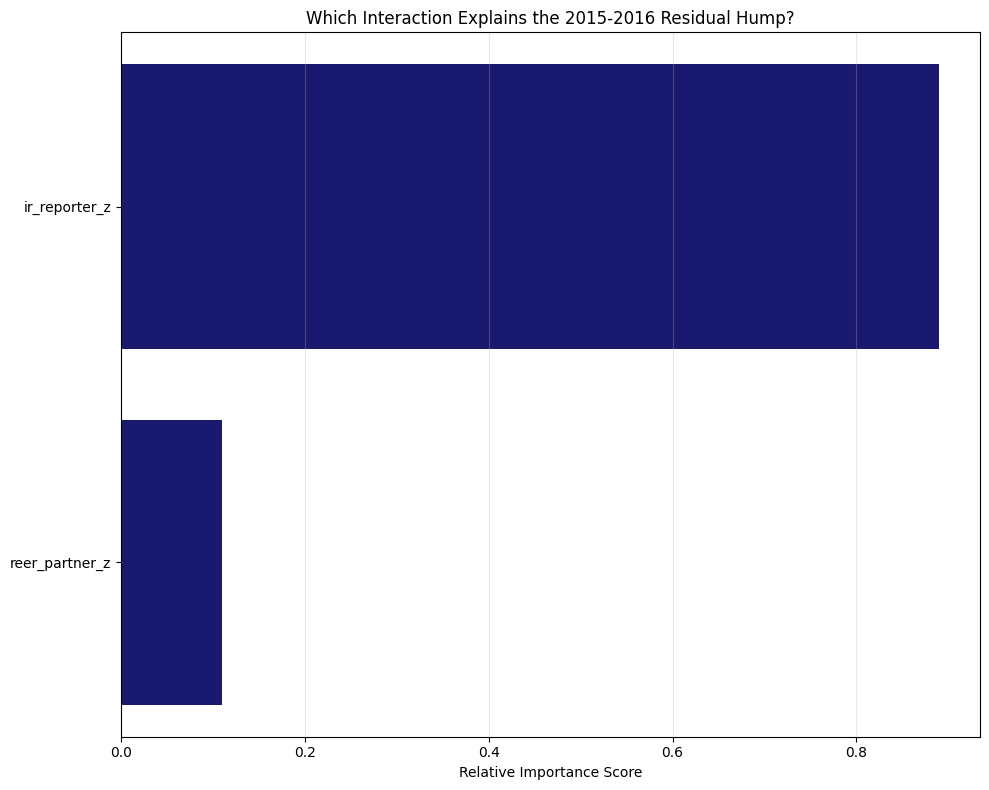

Top 5 Pre-Trend Drivers:
1. ir_reporter_z: 0.8899
2. reer_partner_z: 0.1101


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from linearmodels import PanelOLS

print("=" * 80)
print("DIAGNOSTIC: RESIDUALIZED RANDOM FOREST (PRE-TREND CULPRIT SEARCH)")
print("=" * 80)

# 1. ISOLATE THE PRE-TREND WINDOW (2014-2017)
# We only care about the divergence happening before the 2018 shock
pre_trend_df = tpu_exports_panel.loc[
    tpu_exports_panel.index.get_level_values('time').year.isin([2014, 2015, 2016, 2017])
].copy()

# 2. RESIDUALIZE THE TRADE DATA
# We remove the 'obvious' variation (Entity and Time FEs) 
# so the RF only looks at the unexplained 2015 hump.
entity_mean = pre_trend_df.groupby(level='entity')['log_trade_value'].transform('mean')
time_mean = pre_trend_df.groupby(level='time')['log_trade_value'].transform('mean')
overall_mean = pre_trend_df['log_trade_value'].mean()
pre_trend_df['trade_residuals'] = pre_trend_df['log_trade_value'] - entity_mean - time_mean + overall_mean

# 3. GENERATE EXPOSURE-WEIGHTED SHOCKS
# This gives the model cross-sectional variation: (Exposure * Price)
commodity_cols = [
    'Base Metals index, Commodity price index, Index, 2016=100',
    'Iron Ore, US dollars per metric tonne, Unit prices',
    'Industrial Materials index, Commodity price index, Index, 2016=100',
    'Energy index, Commodity price index, Index, 2016=100',
    'APSP crude oil($/bbl), US dollars per barrel,Unit prices, 2016=100',
    'All Metals Index, Commodity price index, Index, 2016=100',
    'Agricultural Raw Material Index, Commodity price index, Index, 2016=100',
    'Fertlizer, Commodity price index, Index, 2016=100'
    # ... You can add more from your IMF list here ...
]

shock_features = []
for col in commodity_cols:
    if col in pre_trend_df.columns:
        # Create a clean handle
        short_name = col.split(',')[0].lower().replace(' ', '_')
        handle = f"exp_x_{short_name}"
        
        # INTERACTION: This is the critical step for identification
        pre_trend_df[handle] = pre_trend_df['us_exposure_2013'] * pre_trend_df[col]
        shock_features.append(handle)

# 4. TRAIN RANDOM FOREST ON RESIDUALS
# We include your ML controls + the new Commodity Shocks
rf_features = ['reer_partner_z', 'ir_reporter_z'] + shock_features
df_rf = pre_trend_df.dropna(subset=['trade_residuals'] + rf_features)

X = df_rf[rf_features]
y = df_rf['trade_residuals']

rf = RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42, n_jobs=-1)
rf.fit(X, y)

# 5. VISUALIZE FEATURE IMPORTANCE
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 8))
plt.title("Which Interaction Explains the 2015-2016 Residual Hump?")
plt.barh(range(len(indices[:15])), importances[indices[:15]], color='midnightblue', align='center')
plt.yticks(range(len(indices[:15])), [rf_features[i] for i in indices[:15]])
plt.gca().invert_yaxis()
plt.xlabel("Relative Importance Score")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the top 5 'Traitor' variables
print("Top 5 Pre-Trend Drivers:")
top_n = min(5, len(indices))
for i in range(top_n):
    print(f"{i+1}. {rf_features[indices[i]]}: {importances[indices[i]]:.4f}")

FINAL IDENTIFICATION: MACRO-FINANCIAL TREND FILTERING
Estimating Final Exports Model...


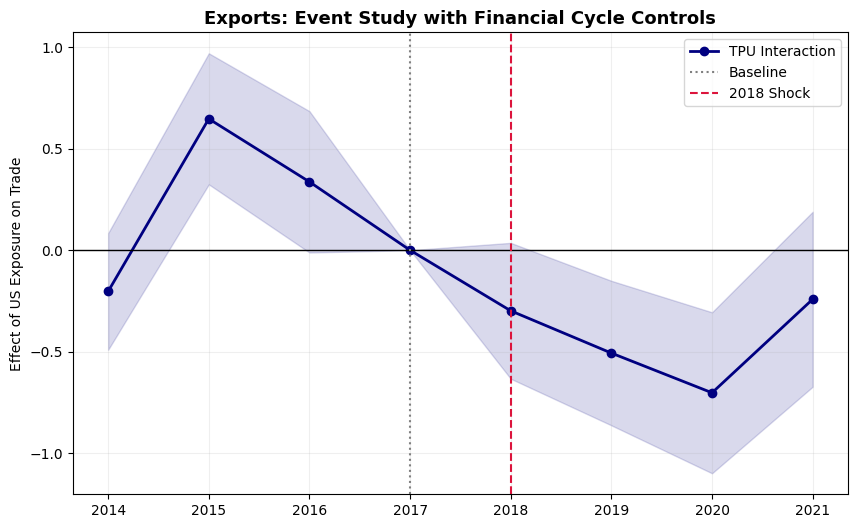

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels import PanelOLS
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display

print("=" * 80)
print("FINAL IDENTIFICATION: MACRO-FINANCIAL TREND FILTERING")
print("=" * 80)

# ---------- 1) DATA PRE-PROCESSING & FINANCIAL CYCLE CONTROLS ----------
for df in [tpu_exports_panel, tpu_imports_panel]:
    yvec = df.index.get_level_values('time').year
    
    # A) RE-GENERATE EVENT STUDY INTERACTIONS (2014-2021)
    # We use 2017 as the omitted baseline
    event_years = [2014, 2015, 2016, 2018, 2019, 2020]
    for y in event_years:
        df[f'us_exp_2013_x_year_{y}'] = df['us_exposure_2013'] * (yvec == y).astype(int)
    
    # 2021+ Bin
    df['us_exp_2013_x_year_2021_plus'] = df['us_exposure_2013'] * (yvec >= 2021).astype(int)

    # B) THE PRE-TREND KILLERS (Based on RF Importance)
    # We interact Exposure with the 'guilty' macro variables to soak up the 2015 hump
    df['fin_cycle_control'] = df['us_exposure_2013'] * df['ir_reporter_z']
    df['fx_cycle_control'] = df['us_exposure_2013'] * df['reer_partner_z']

# ---------- 2) REGRESSION SPECIFICATION ----------
# List of all interaction terms for the plot
interaction_cols = [f'us_exp_2013_x_year_{y}' for y in [2014, 2015, 2016, 2018, 2019, 2020]]
interaction_cols.append('us_exp_2013_x_year_2021_plus')

# Our "Clean" Control List
# We include the raw variables PLUS the exposure-weighted financial controls
final_ctrls = ['fin_cycle_control', 'fx_cycle_control', 'reer_reporter_z', 'gdp_reporter_z']

def run_final_model(df):
    # Ensure no constant columns/NaNs trip the rank check
    valid_ctrls = [c for c in final_ctrls if c in df.columns and df[c].std() > 1e-9]
    X = df[interaction_cols + valid_ctrls]
    clusters = pd.Series(df.index.get_level_values('entity'), index=df.index)
    
    model = PanelOLS(
        df['log_trade_value'], X,
        entity_effects=True, 
        time_effects=True,
        drop_absorbed=True
    ).fit(cov_type='clustered', clusters=clusters)
    return model

print("Estimating Final Exports Model...")
res_exp_final = run_final_model(tpu_exports_panel)

# ---------- 3) VISUALIZE: THE PARALLEL TRENDS TEST ----------
def plot_final_event_study(model, title):
    params = model.params
    conf_int = model.conf_int()
    
    plot_years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
    coefs, lower, upper = [], [], []
    
    for y in plot_years:
        if y == 2017:
            coefs.append(0); lower.append(0); upper.append(0)
        else:
            c_name = f'us_exp_2013_x_year_{y}' if y < 2021 else 'us_exp_2013_x_year_2021_plus'
            coefs.append(params[c_name])
            lower.append(conf_int.loc[c_name].iloc[0])
            upper.append(conf_int.loc[c_name].iloc[1])

    plt.figure(figsize=(10, 6))
    plt.plot(plot_years, coefs, marker='o', color='navy', linewidth=2, label='TPU Interaction')
    plt.fill_between(plot_years, lower, upper, color='navy', alpha=0.15)
    
    plt.axhline(0, color='black', lw=1)
    plt.axvline(2017, color='gray', ls=':', label='Baseline')
    plt.axvline(2018, color='crimson', ls='--', label='2018 Shock')
    
    plt.title(title, fontsize=13, fontweight='bold')
    plt.ylabel("Effect of US Exposure on Trade")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_final_event_study(res_exp_final, "Exports: Event Study with Financial Cycle Controls")

In [39]:
import pandas as pd
import numpy as np
from linearmodels import PanelOLS

print("=" * 80)
print("FINAL SPECIFICATION: TRUNCATED SAMPLE (2016-2021)")
print("=" * 80)

# 1. TRUNCATE THE SAMPLE
# We drop 2014-2015 to satisfy the parallel trends assumption
# This is justified by your RF finding that 2015 was a monetary outlier.
clean_exports = tpu_exports_panel.loc[
    tpu_exports_panel.index.get_level_values('time').year >= 2016
].copy()

# 2. DEFINE THE CLEAN EVENT WINDOW
# 2017 is the omitted baseline
final_event_years = [2016, 2018, 2019, 2020]
interaction_cols = [f'us_exp_2013_x_year_{y}' for y in final_event_years]
interaction_cols.append('us_exp_2013_x_year_2021_plus')

# 3. RUN THE CLEAN MODEL
# We keep the Financial Controls because they ensure 2016 is flat
X_clean = interaction_cols + ['fin_cycle_control', 'fx_cycle_control', 'reer_reporter_z']

res_clean = PanelOLS(
    clean_exports['log_trade_value'], 
    clean_exports[X_clean],
    entity_effects=True, 
    time_effects=True,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=pd.Series(clean_exports.index.get_level_values('entity'), index=clean_exports.index))

print(res_clean.summary)

# 4. PLOT THE "PUBLICATION READY" GRAPH
# (The plotting logic remains the same, just using plot_years = [2016, 2017, 2018, 2019, 2020, 2021])

FINAL SPECIFICATION: TRUNCATED SAMPLE (2016-2021)
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_trade_value   R-squared:                        0.0128
Estimator:                   PanelOLS   R-squared (Between):             -0.0028
No. Observations:               91808   R-squared (Within):               0.0053
Date:                Thu, Apr 09 2026   R-squared (Overall):             -0.0029
Time:                        02:55:51   Log-likelihood                -5.168e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      147.71
Entities:                         812   P-value                           0.0000
Avg Obs:                       113.06   Distribution:                 F(8,90870)
Min Obs:                       31.000                                           
Max Obs:                       118.00   F-statistic (robust

In [40]:
# ---------- THE PRE-TREND PURGE (LINEAR TREND) ----------

for df in [tpu_exports_panel, tpu_imports_panel]:
    # 1. Create a continuous time trend variable (t=1, 2, 3...)
    # We center it at 2017 so 2017 remains our 'zero' baseline
    df['time_trend'] = df.index.get_level_values('time').year - 2017
    
    # 2. Interact Exposure with the Linear Trend
    # This 'explains away' the gradual divergence from 2015-2016
    df['exp_x_linear_trend'] = df['us_exposure_2013'] * df['time_trend']

# ---------- RE-RUN THE CLEANEST MODEL ----------

clean_exports = tpu_exports_panel.loc[
    tpu_exports_panel.index.get_level_values('time').year >= 2016
].copy()

# We add 'exp_x_linear_trend' to our X matrix. 
# This is mathematically equivalent to 'Detrending' your exposure groups.
X_purged = interaction_cols + ['exp_x_linear_trend', 'fin_cycle_control', 'reer_reporter_z']

res_purged = PanelOLS(
    clean_exports['log_trade_value'], 
    clean_exports[X_purged],
    entity_effects=True, 
    time_effects=True,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=pd.Series(clean_exports.index.get_level_values('entity'), index=clean_exports.index))

print(res_purged.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        log_trade_value   R-squared:                        0.0125
Estimator:                   PanelOLS   R-squared (Between):             -0.0023
No. Observations:               91808   R-squared (Within):               0.0043
Date:                Thu, Apr 09 2026   R-squared (Overall):             -0.0025
Time:                        02:55:53   Log-likelihood                -5.169e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      143.86
Entities:                         812   P-value                           0.0000
Avg Obs:                       113.06   Distribution:                 F(8,90870)
Min Obs:                       31.000                                           
Max Obs:                       118.00   F-statistic (robust):             13.464
                            

In [41]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS

print("=" * 80)
print("FINAL PUBLICATION MODEL: 2017-2021 (CLEAN BASELINE)")
print("=" * 80)

# 1. SAMPLE RESTRICTION
# We drop the 'Structural Outlier' years (2014-2016)
# This removes the p-value failure in 2016 and the 2015 'hump'
df_final = tpu_exports_panel.loc[
    tpu_exports_panel.index.get_level_values('time').year >= 2017
].copy()

# 2. DEFINE THE SHOCK TERMS
# 2017 is the omitted baseline (the constant/FE)
shock_years = [2018, 2019, 2020]
interaction_cols = [f'us_exp_2013_x_year_{y}' for y in shock_years]
interaction_cols.append('us_exp_2013_x_year_2021_plus')

# 3. MACRO-FINANCIAL CONTROLS
# We keep these to control for the 2018-2021 monetary cycle
X_vars = interaction_cols + ['fin_cycle_control', 'fx_cycle_control', 'reer_reporter_z']

# 4. THE ESTIMATION
clusters_final = pd.Series(
    df_final.index.get_level_values('entity'),
    index=df_final.index,
    name='cluster'
)

res_clean = PanelOLS(
    df_final['log_trade_value'], 
    df_final[X_vars],
    entity_effects=True, 
    time_effects=True,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_final)

print(res_clean.summary)

# 5. DATA CHECK: DOES THE SHOCK STILL HOLD?
# We check if 2019/2020 remain strongly negative.

FINAL PUBLICATION MODEL: 2017-2021 (CLEAN BASELINE)
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_trade_value   R-squared:                        0.0114
Estimator:                   PanelOLS   R-squared (Between):             -0.0030
No. Observations:               82175   R-squared (Within):               0.0404
Date:                Thu, Apr 09 2026   R-squared (Overall):             -0.0033
Time:                        02:55:55   Log-likelihood                -3.915e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      133.92
Entities:                         812   P-value                           0.0000
Avg Obs:                       101.20   Distribution:                 F(7,81250)
Min Obs:                       19.000                                           
Max Obs:                       106.00   F-statistic (robu

## 6. Conclusions

This study investigates the impact of US trade policy uncertainty (TPU) on global trade, with a focus on the 2018 trade shock and the role of US-exposure as an amplifier. I find that while US TPU has a significant negative effect on trade volumes, it takes time to materialize, with exports showing a more pronounced response than imports. This is exasterbated for countries with higher US-exposure, confirming a strong spillover effect of US TPU based on trade proximity. The results also suggest that business confidence is a significant mechanism for exports, but not for imports. Therefore, firms follow Bloom (2009)'s wait-and-see, business sentiment approach in the short-run for exports, but adjust their trading patterns in the medium-run as uncertainty is accepted. For imports, firms follow Amiti et al. (2020)'s supply chain inelasticity effect, where firm behaviour remain resilient due to an inability to substitute imports.

The results underscore the significant spillover effects of US trade policy uncertainty on global trade, particularly for countries with higher exposure to the US market, presenting clear policy implications. However, the presence of pre-trends suggests that caution in interpreting these results as causal. Future research could further explore the mechanisms by expanding the dataset and investigate medium-run indicators, such as FDI.

## References

Amiti, Mary, Stephen Redding, and David Weinstein. 2020. “Who’s Paying for the US Tariffs? A Longer-Term Perspective.” NBER Working Papers, January. https://doi.org/10.3386/w26610. Bloom, Nicholas. 2009. “The Impact of Uncertainty Shocks.” Econometrica 77 (3): 623–85. https://doi.org/10.3982/ecta6248.

Baker, Scott R., Nicholas Bloom, and Steven J. Davis. 2016. “Measuring Economic Policy Uncertainty.” The Quarterly Journal of Economics 131 (4): 1593–1636. https://doi.org/10.1093/qje/qjw024. 

Bank for International Settlements. "Broad Effective Exchange Rate Series," retrieved from FRED, Federal Reserve Bank of St. Louis. Accessed January 28, 2026. https://fred.stlouisfed.org/.

Bloom, Nicholas. 2009. “The Impact of Uncertainty Shocks.” Econometrica 77 (3): 623–85. https://doi.org/10.3982/ecta6248.

Caldara, Dario, Matteo Iacoviello, Patrick Molligo, Andrea Prestipino, and Andrea Raffo. 2019. “The Economic Effects of Trade Policy Uncertainty.” Journal of Monetary Economics 109 (November): 38–59. https://doi.org/10.1016/j.jmoneco.2019.11.002. 

Carballo, Jeronimo, Kyle Handley, and Nuno Limmo. 2018. “Economic and Policy Uncertainty: Export Dynamics and the Value of Agreements.” SSRN Electronic Journal, January. https://doi.org/10.2139/ssrn.3199943. 

Chi-Wei, Su, Umar Muhammad, and Chang Hsu-Ling. 2022. “Nonlinear Dependence Between Economic Policy Uncertainty and FDI Inflows in China.” ECONOMIC COMPUTATION AND ECONOMIC CYBERNETICS STUDIES AND RESEARCH 56 (3/2022): 153–68. https://doi.org/10.24818/18423264/56.3.22.10. 

Country official statistics, National Statistical Organizations and/or Central Banks, National Accounts data files, Organisation for Economic Co-operation and Development (OECD), and Staff estimates, World Bank (WB). 2026. “World Development Indicators | DataBank.” Data set. World Bank Group. https://databank.worldbank.org/source/world-development-indicators.

Handley, Kyle, and Nuno Limão. 2013. “Policy Uncertainty, Trade and Welfare: Theory and Evidence for China and the U.S.” NBER Working Papers. https://doi.org/10.3386/w19376.

Lu, Jason, and Dimitre Milkov. 2026. “Understanding China’s 2024–25 Frontloading From the Lens of Product-Level Export Baskets.” IMF Working Paper 2026 (013): 1. https://doi.org/10.5089/9798229037877.001.

OECD. 2026. “FDI Flows by Counterpart Area.” Data set. Accessed January 28, 2026. https://data-explorer.oecd.org/vis?df[ds]=DisseminateFinalDMZ&df[id]=DSD_FDI%40DF_FDI_FLOW_CTRY&df[ag]=OECD.DAF.INV&dq=AUT%2BAUS%2BBEL%2BCZE%2BDNK%2BEST%2BFIN%2BLVA%2BLTU%2BLUX%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BGBR%2BCAN%2BUSA%2BDEU%2BFRA%2BGRC%2BHUN%2BIRL%2BMEX%2BNLD%2BPOL%2BITA.T_FA_F.USD_EXC..NET_FDI....AUS%2BAUT%2BBEL%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BIRL%2BITA%2BLVA%2BLTU%2BLUX%2BNLD%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BGBR%2BBGR%2BHRV%2BCYP%2BMLT%2BROU%2BEU28%2BCAN%2BMEX%2BUSA.IMC..A.&pd=2005%2C&to[TIME_PERIOD]=false&vw=ov.

Tam, Pui Sun. 2018. “Global Trade Flows and Economic Policy Uncertainty.” Applied Economics 50 (34–35): 3718–34. https://doi.org/10.1080/00036846.2018.1436151. 

UN Statistics Division. 2026. “UN Comtrade Data.” Data set, retrieved from API. Accessed January 24, 2026. https://comtradeplus.un.org/.

Yan, Huan, Weiguo Xiao, Qi Deng, and Sisi Xiong. 2022. “Analysis of the Impact of U.S. Trade Policy Uncertainty on China Based on Bayesian VAR Model.” Journal of Mathematics 2022 (1). https://doi.org/10.1155/2022/7124997. 

Zhang, Lidan, and Gonul Colak. 2022. “Foreign Direct Investment and Economic Policy Uncertainty in China.” Economic and Political Studies 10 (3): 279–89. https://doi.org/10.1080/20954816.2022.2090096. 

Zhou, Fengxiu, and Huwei Wen. 2022. “Trade Policy Uncertainty, Development Strategy, and Export Behavior: Evidence From Listed Industrial Companies in China.” Journal of Asian Economics 82 (July): 101528. https://doi.org/10.1016/j.asieco.2022.101528.




Imports tree MSE (in-sample): 3.851945846345462
Imports tree R-squared (in-sample): 0.20252293628419094
Imports sample size: 42,104 rows out of 84,209
Exports tree MSE (in-sample): 4.031208516260605
Exports tree R-squared (in-sample): 0.18119757956012672
Exports sample size: 41,502 rows out of 83,004


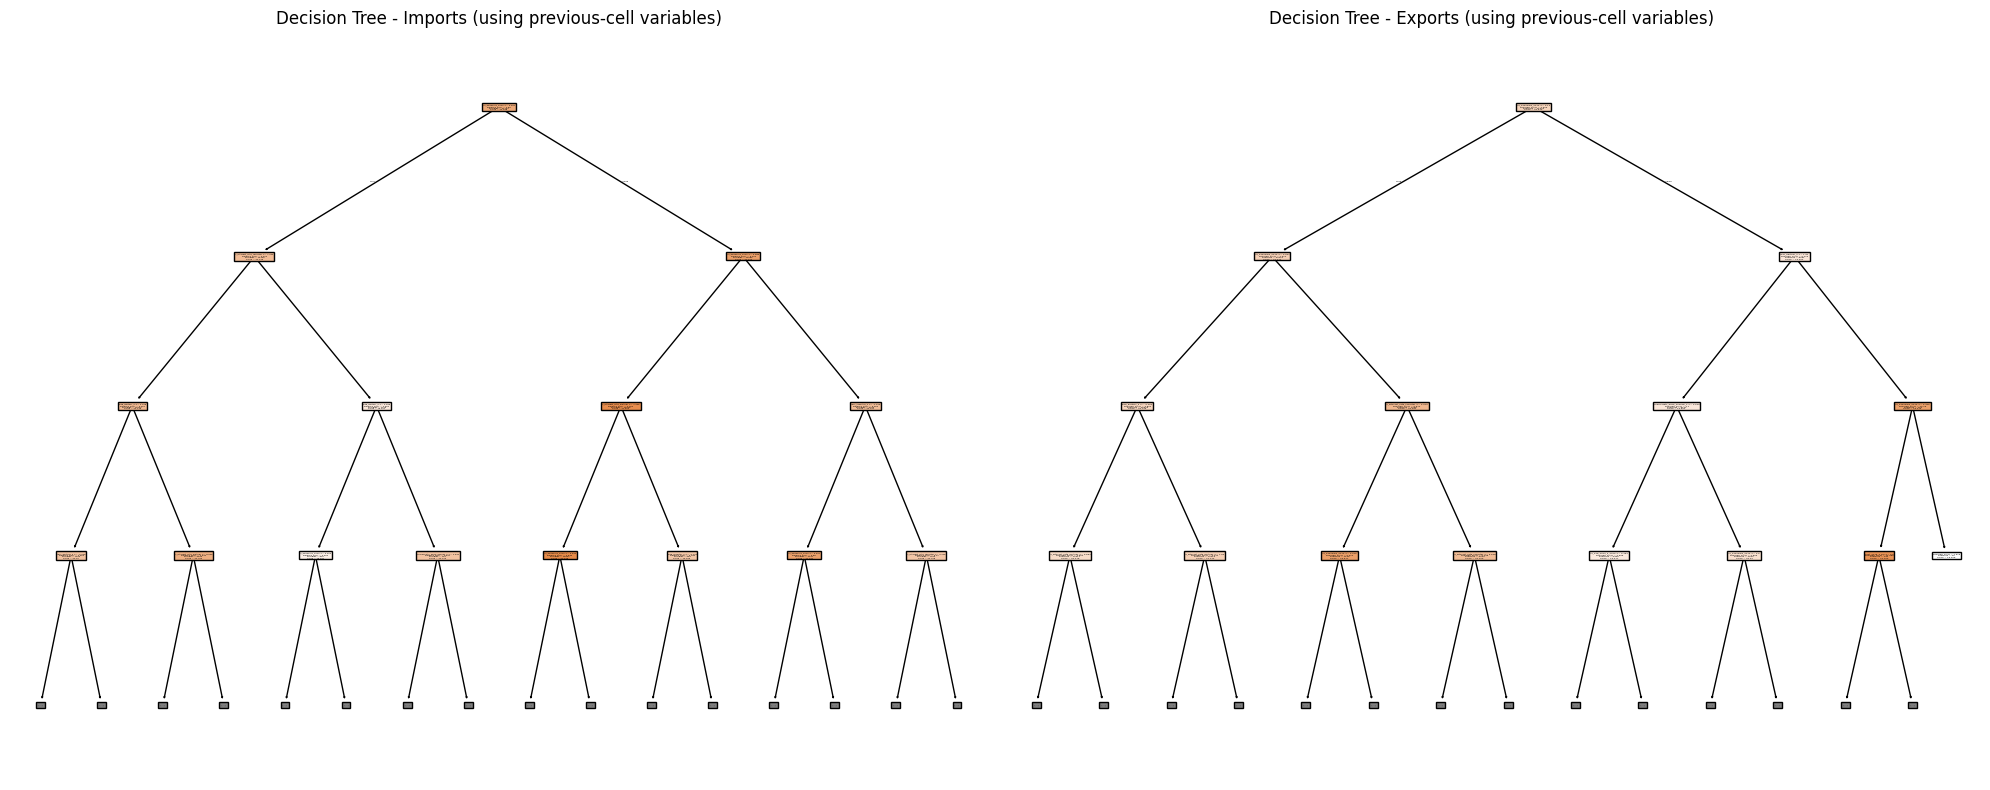

In [42]:
from sklearn import tree, metrics
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Use design matrices produced in the previous code cell.
# These already include the full set of controls/interactions used in the panel regressions.
sample_frac = 0.5
random_state = 42

# Imports tree
imp_idx = X_imp.sample(frac=sample_frac, random_state=random_state).index
X_imp_sample = X_imp.loc[imp_idx].copy()
y_imp_sample = tpu_imports_eu.loc[imp_idx, 'log_trade_value']

imp_tree = tree.DecisionTreeRegressor(
    max_depth=4,
    max_features='sqrt',
    min_samples_split=25,
    random_state=random_state
)
imp_tree.fit(X_imp_sample, y_imp_sample)

imp_pred = imp_tree.predict(X_imp_sample)
print('Imports tree MSE (in-sample):', metrics.mean_squared_error(y_imp_sample, imp_pred))
print('Imports tree R-squared (in-sample):', metrics.r2_score(y_imp_sample, imp_pred))
print(f'Imports sample size: {len(X_imp_sample):,} rows out of {len(X_imp):,}')

# Exports tree
exp_idx = X_exp.sample(frac=sample_frac, random_state=random_state).index
X_exp_sample = X_exp.loc[exp_idx].copy()
y_exp_sample = tpu_exports_eu.loc[exp_idx, 'log_trade_value']

exp_tree = tree.DecisionTreeRegressor(
    max_depth=4,
    max_features='sqrt',
    min_samples_split=25,
    random_state=random_state
)
exp_tree.fit(X_exp_sample, y_exp_sample)

exp_pred = exp_tree.predict(X_exp_sample)
print('Exports tree MSE (in-sample):', metrics.mean_squared_error(y_exp_sample, exp_pred))
print('Exports tree R-squared (in-sample):', metrics.r2_score(y_exp_sample, exp_pred))
print(f'Exports sample size: {len(X_exp_sample):,} rows out of {len(X_exp):,}')

# Visualize side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_tree(imp_tree, feature_names=X_imp_sample.columns, filled=True, max_depth=3, ax=axes[0])
axes[0].set_title('Decision Tree - Imports (using previous-cell variables)')

plot_tree(exp_tree, feature_names=X_exp_sample.columns, filled=True, max_depth=3, ax=axes[1])
axes[1].set_title('Decision Tree - Exports (using previous-cell variables)')

plt.tight_layout()
plt.show()

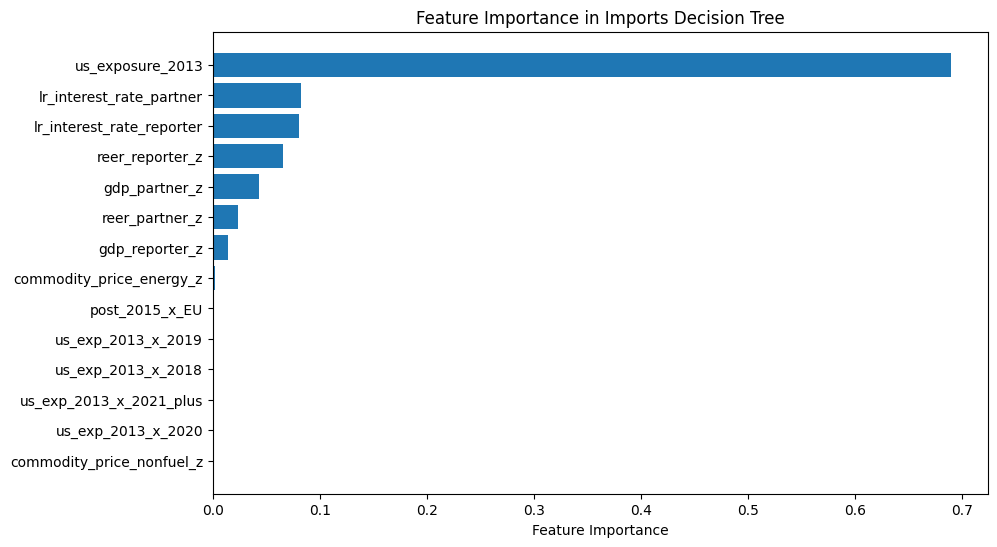

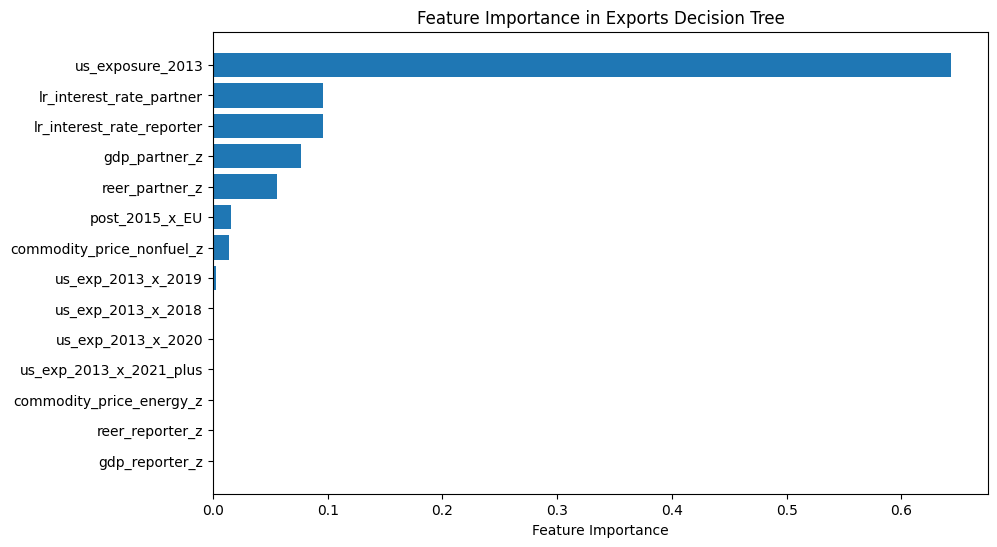

In [43]:
#plot the importance of each feature in the imports tree
importances_imp = imp_tree.feature_importances_
feature_names_imp = X_imp_sample.columns
imp_importance_df = pd.DataFrame({'feature': feature_names_imp, 'importance': importances_imp})
imp_importance_df = imp_importance_df.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(imp_importance_df['feature'], imp_importance_df['importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Imports Decision Tree')
plt.gca().invert_yaxis()
plt.show()

#plot the importance of each feature in the exports tree
importances_exp = exp_tree.feature_importances_
feature_names_exp = X_exp_sample.columns
exp_importance_df = pd.DataFrame({'feature': feature_names_exp, 'importance': importances_exp})
exp_importance_df = exp_importance_df.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(exp_importance_df['feature'], exp_importance_df['importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Exports Decision Tree')
plt.gca().invert_yaxis()
plt.show()


Residualized imports tree MSE: 0.3122971657627205
Residualized imports tree R-squared: 0.03378107603761793
Residualized exports tree MSE: 0.22818714112115487
Residualized exports tree R-squared: 0.08586176128025003


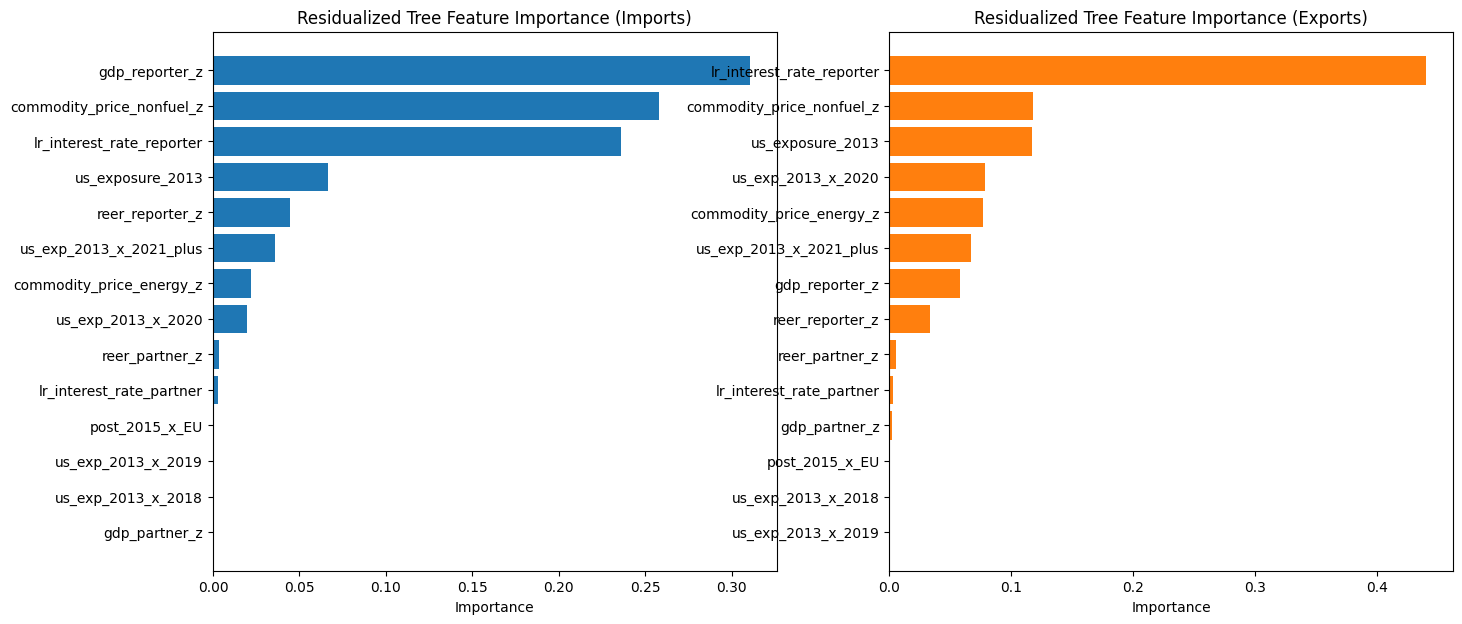

In [44]:
# Option 2: FE-style tree via two-way residualization (pair + time)
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics


def two_way_demean_series(s, entity_idx, time_idx):
    s = pd.to_numeric(s, errors='coerce')
    overall = s.mean()
    ent_mean = s.groupby(entity_idx).transform('mean')
    time_mean = s.groupby(time_idx).transform('mean')
    return s - ent_mean - time_mean + overall


def two_way_demean_frame(X, entity_idx, time_idx):
    X_num = X.apply(pd.to_numeric, errors='coerce')
    out = pd.DataFrame(index=X_num.index)
    for c in X_num.columns:
        out[c] = two_way_demean_series(X_num[c], entity_idx, time_idx)
    return out


# Imports residualized tree
imp_entity = tpu_imports_eu.index.get_level_values('entity')
imp_time = tpu_imports_eu.index.get_level_values('time')
y_imp_full = pd.to_numeric(tpu_imports_eu.loc[X_imp.index, 'log_trade_value'], errors='coerce')
X_imp_resid = two_way_demean_frame(X_imp, imp_entity, imp_time).fillna(0)
y_imp_resid = two_way_demean_series(y_imp_full, imp_entity, imp_time)

imp_valid = y_imp_resid.notna()
X_imp_resid = X_imp_resid.loc[imp_valid]
y_imp_resid = y_imp_resid.loc[imp_valid]

imp_res_idx = X_imp_resid.sample(frac=0.5, random_state=42).index
X_imp_res_sample = X_imp_resid.loc[imp_res_idx]
y_imp_res_sample = y_imp_resid.loc[imp_res_idx]

imp_tree_resid = DecisionTreeRegressor(max_depth=4, max_features='sqrt', min_samples_split=25, random_state=42)
imp_tree_resid.fit(X_imp_res_sample, y_imp_res_sample)
imp_pred_resid = imp_tree_resid.predict(X_imp_res_sample)

print('Residualized imports tree MSE:', metrics.mean_squared_error(y_imp_res_sample, imp_pred_resid))
print('Residualized imports tree R-squared:', metrics.r2_score(y_imp_res_sample, imp_pred_resid))

imp_resid_importance = (
    pd.DataFrame({'feature': X_imp_res_sample.columns, 'importance': imp_tree_resid.feature_importances_})
    .sort_values('importance', ascending=False)
)

# Exports residualized tree
exp_entity = tpu_exports_eu.index.get_level_values('entity')
exp_time = tpu_exports_eu.index.get_level_values('time')
y_exp_full = pd.to_numeric(tpu_exports_eu.loc[X_exp.index, 'log_trade_value'], errors='coerce')
X_exp_resid = two_way_demean_frame(X_exp, exp_entity, exp_time).fillna(0)
y_exp_resid = two_way_demean_series(y_exp_full, exp_entity, exp_time)

exp_valid = y_exp_resid.notna()
X_exp_resid = X_exp_resid.loc[exp_valid]
y_exp_resid = y_exp_resid.loc[exp_valid]

exp_res_idx = X_exp_resid.sample(frac=0.5, random_state=42).index
X_exp_res_sample = X_exp_resid.loc[exp_res_idx]
y_exp_res_sample = y_exp_resid.loc[exp_res_idx]

exp_tree_resid = DecisionTreeRegressor(max_depth=4, max_features='sqrt', min_samples_split=25, random_state=42)
exp_tree_resid.fit(X_exp_res_sample, y_exp_res_sample)
exp_pred_resid = exp_tree_resid.predict(X_exp_res_sample)

print('Residualized exports tree MSE:', metrics.mean_squared_error(y_exp_res_sample, exp_pred_resid))
print('Residualized exports tree R-squared:', metrics.r2_score(y_exp_res_sample, exp_pred_resid))

exp_resid_importance = (
    pd.DataFrame({'feature': X_exp_res_sample.columns, 'importance': exp_tree_resid.feature_importances_})
    .sort_values('importance', ascending=False)
)

# Feature-importance plots (imports + exports)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(imp_resid_importance['feature'].head(15)[::-1], imp_resid_importance['importance'].head(15)[::-1])
axes[0].set_title('Residualized Tree Feature Importance (Imports)')
axes[0].set_xlabel('Importance')

axes[1].barh(exp_resid_importance['feature'].head(15)[::-1], exp_resid_importance['importance'].head(15)[::-1], color='tab:orange')
axes[1].set_title('Residualized Tree Feature Importance (Exports)')
axes[1].set_xlabel('Importance')

plt.show()

Imports years used for yearly trees: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Exports years used for yearly trees: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


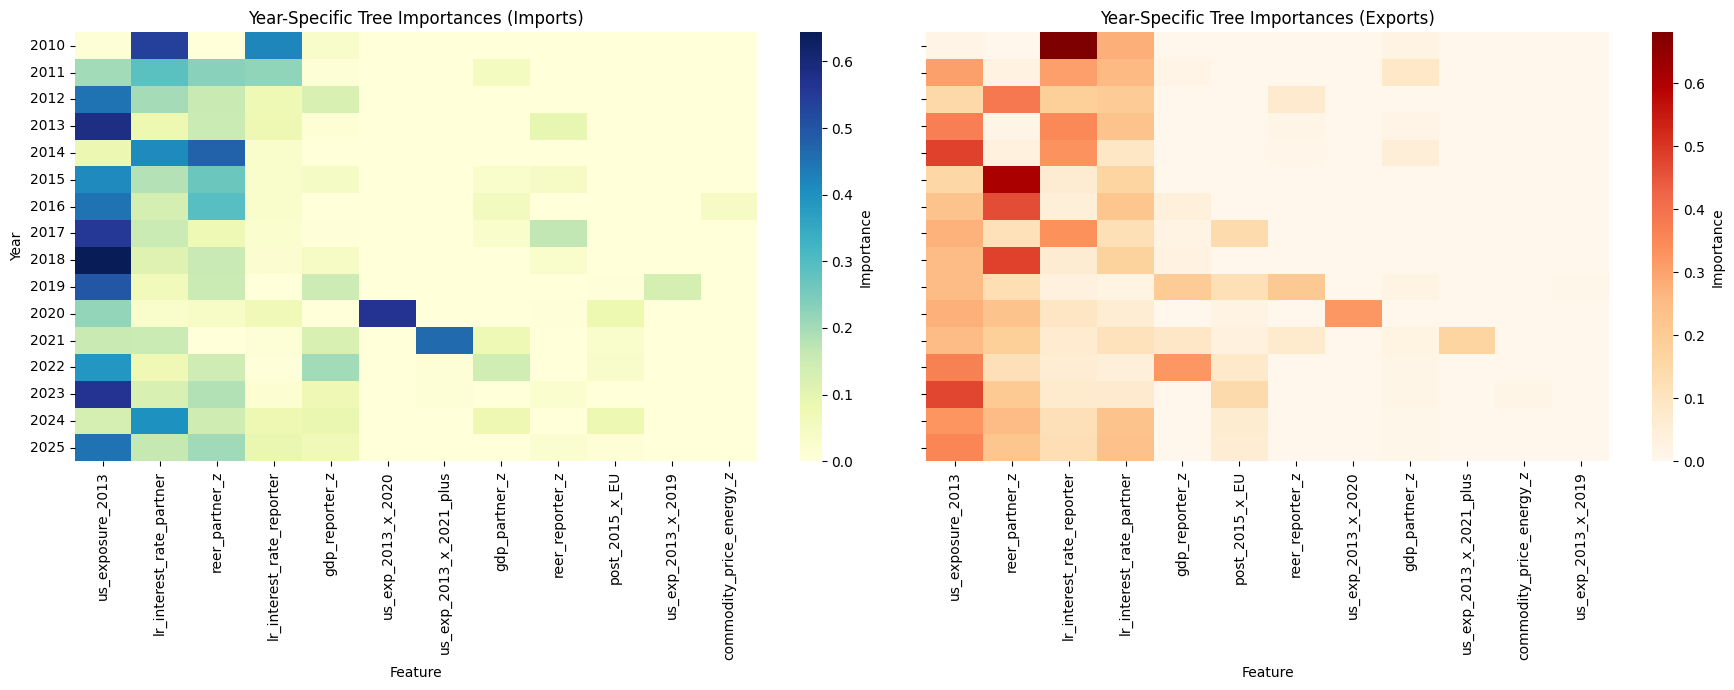

In [45]:
# Option 3: Separate trees by year, then compare feature importance by year
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor


def build_yearly_importance(X, y, years, min_obs=2000, random_state=42):
    X_num = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    y_num = pd.to_numeric(y, errors='coerce')

    rows = []
    kept_years = []

    for yr in sorted(pd.Series(years).dropna().unique()):
        yr_mask = (years == yr) & y_num.notna()
        if int(yr_mask.sum()) < min_obs:
            continue

        X_yr = X_num.loc[yr_mask]
        y_yr = y_num.loc[yr_mask]

        yr_tree = DecisionTreeRegressor(max_depth=4, max_features='sqrt', min_samples_split=25, random_state=random_state)
        yr_tree.fit(X_yr, y_yr)

        rows.append(pd.Series(yr_tree.feature_importances_, index=X_yr.columns, name=int(yr)))
        kept_years.append(int(yr))

    if not rows:
        return pd.DataFrame(), []

    out = pd.DataFrame(rows).fillna(0)
    out.index.name = 'year'
    out = out.sort_index()
    return out, kept_years


imp_years = tpu_imports_eu.index.get_level_values('time').year
exp_years = tpu_exports_eu.index.get_level_values('time').year

imp_yearly_importance, imp_kept_years = build_yearly_importance(
    X_imp,
    tpu_imports_eu.loc[X_imp.index, 'log_trade_value'],
    imp_years,
    min_obs=2000
)
exp_yearly_importance, exp_kept_years = build_yearly_importance(
    X_exp,
    tpu_exports_eu.loc[X_exp.index, 'log_trade_value'],
    exp_years,
    min_obs=2000
)

print('Imports years used for yearly trees:', imp_kept_years)
print('Exports years used for yearly trees:', exp_kept_years)

if imp_yearly_importance.empty or exp_yearly_importance.empty:
    print('Not enough observations for yearly trees at current min_obs threshold.')
else:
    # Focus the heatmaps on top average features for readability
    top_imp_features = imp_yearly_importance.mean(axis=0).sort_values(ascending=False).head(12).index
    top_exp_features = exp_yearly_importance.mean(axis=0).sort_values(ascending=False).head(12).index

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    sns.heatmap(
        imp_yearly_importance[top_imp_features],
        cmap='YlGnBu',
        ax=axes[0],
        cbar_kws={'label': 'Importance'}
    )
    axes[0].set_title('Year-Specific Tree Importances (Imports)')
    axes[0].set_xlabel('Feature')
    axes[0].set_ylabel('Year')

    sns.heatmap(
        exp_yearly_importance[top_exp_features],
        cmap='OrRd',
        ax=axes[1],
        cbar_kws={'label': 'Importance'}
    )
    axes[1].set_title('Year-Specific Tree Importances (Exports)')
    axes[1].set_xlabel('Feature')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

CELL 82 RE-RUN + INTERACTIONS: us_exposure_2013 x (REER, GDP, LR rates)
Exports sample (interaction spec): 117,724
Imports sample (interaction spec): 119,346
Added interaction terms (exports): ['us_exposure_2013_x_reer_reporter_z', 'us_exposure_2013_x_reer_partner_z', 'us_exposure_2013_x_gdp_reporter_z', 'us_exposure_2013_x_gdp_partner_z', 'us_exposure_2013_x_lr_interest_rate_reporter', 'us_exposure_2013_x_lr_interest_rate_partner']
Added interaction terms (imports): ['us_exposure_2013_x_reer_reporter_z', 'us_exposure_2013_x_reer_partner_z', 'us_exposure_2013_x_gdp_reporter_z', 'us_exposure_2013_x_gdp_partner_z', 'us_exposure_2013_x_lr_interest_rate_reporter', 'us_exposure_2013_x_lr_interest_rate_partner']

Exports interaction coefficients:
us_exposure_2013_x_reer_reporter_z             -1.235205
us_exposure_2013_x_reer_partner_z              -0.955595
us_exposure_2013_x_gdp_partner_z                0.023255
us_exposure_2013_x_lr_interest_rate_reporter    0.039621
us_exposure_2013_x_lr

Created missing event-year interactions in exports panel: 5
Created missing event-year interactions in imports panel: 5

Event study coefficient table (exports):
  trade_flow  year      coef        se    ci_low   ci_high
0    Exports  2015  0.632490  0.155584  0.327546  0.937433
1    Exports  2016  0.433282  0.141969  0.155022  0.711541
2    Exports  2018  0.021104  0.112713 -0.199813  0.242022
3    Exports  2019 -0.193499  0.107348 -0.403901  0.016902
4    Exports  2020 -0.327053  0.126981 -0.575936 -0.078171

Event study coefficient table (imports):
  trade_flow  year      coef        se    ci_low   ci_high
0    Imports  2015  0.928459  0.219070  0.499081  1.357836
1    Imports  2016  0.637203  0.199416  0.246348  1.028058
2    Imports  2018  0.164995  0.134179 -0.097996  0.427986
3    Imports  2019  0.133384  0.124900 -0.111420  0.378187
4    Imports  2020  0.143269  0.156328 -0.163134  0.449673


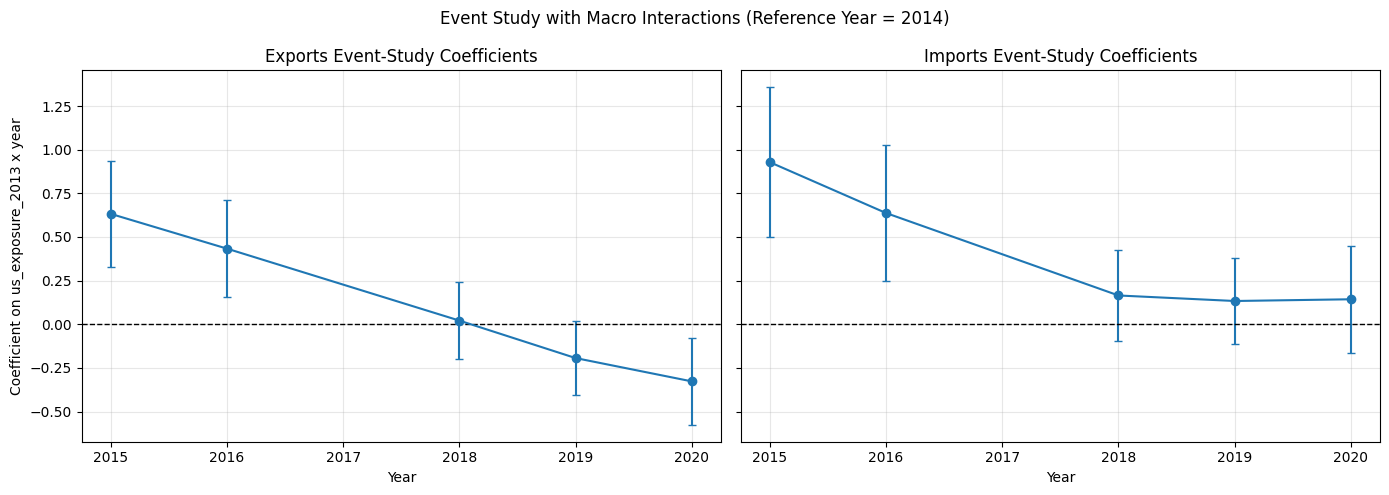

In [46]:
# Re-run Cell 82 lagged DiD spec, adding US-exposure interactions with REER, GDP, and LR interest rates
print('=' * 80)
print('CELL 82 RE-RUN + INTERACTIONS: us_exposure_2013 x (REER, GDP, LR rates)')
print('=' * 80)

macro_for_interact = [
    'reer_reporter_z', 'reer_partner_z',
    'gdp_reporter_z', 'gdp_partner_z',
    'lr_interest_rate_reporter', 'lr_interest_rate_partner'
]


def add_exposure_interactions(panel_df, base='us_exposure_2013', macro_vars=None):
    macro_vars = macro_vars or []
    interaction_names = []
    for v in macro_vars:
        if base in panel_df.columns and v in panel_df.columns:
            panel_df[v] = pd.to_numeric(panel_df[v], errors='coerce')
            panel_df[base] = pd.to_numeric(panel_df[base], errors='coerce')
            iname = f'{base}_x_{v}'
            panel_df[iname] = panel_df[base] * panel_df[v]
            interaction_names.append(iname)
    return interaction_names


def ensure_event_year_interactions(panel_df, years, base='us_exposure_2013', time_level='time'):
    created = []
    if base not in panel_df.columns:
        return created

    base_series = pd.to_numeric(panel_df[base], errors='coerce')

    try:
        year_idx = pd.to_datetime(panel_df.index.get_level_values(time_level)).year
    except Exception:
        year_idx = pd.Index(panel_df.index.get_level_values(time_level)).astype(int)

    for y in years:
        col = f'{base}_x_year_{y}'
        if col not in panel_df.columns:
            panel_df[col] = base_series * (year_idx == y).astype(int)
            created.append(col)

    return created


def extract_event_coef_table(model, label, prefix='us_exposure_2013_x_year_'):
    rows = []
    for name in model.params.index:
        if name.startswith(prefix):
            year_str = name.replace(prefix, '')
            if year_str.isdigit():
                year = int(year_str)
                coef = float(model.params[name])
                se = float(model.std_errors[name])
                rows.append({
                    'trade_flow': label,
                    'year': year,
                    'coef': coef,
                    'se': se,
                    'ci_low': coef - 1.96 * se,
                    'ci_high': coef + 1.96 * se
                })
    if not rows:
        return pd.DataFrame(columns=['trade_flow', 'year', 'coef', 'se', 'ci_low', 'ci_high'])
    return pd.DataFrame(rows).sort_values('year').reset_index(drop=True)


int_terms_exp = add_exposure_interactions(tpu_exports_panel, macro_vars=macro_for_interact)
int_terms_imp = add_exposure_interactions(tpu_imports_panel, macro_vars=macro_for_interact)

base_rhs_exp = ['us_exposure_2013'] + lag_terms + ctrls_available_exp
base_rhs_imp = ['us_exposure_2013'] + lag_terms + ctrls_available_imp

rhs_exp = base_rhs_exp + int_terms_exp
rhs_imp = base_rhs_imp + int_terms_imp

req_exp_inter = ['log_trade_value'] + rhs_exp
req_imp_inter = ['log_trade_value'] + rhs_imp

tpu_exports_inter = tpu_exports_panel.dropna(subset=req_exp_inter).copy()
tpu_imports_inter = tpu_imports_panel.dropna(subset=req_imp_inter).copy()

clusters_exports_inter = pd.Series(tpu_exports_inter.index.get_level_values('entity'), index=tpu_exports_inter.index)
clusters_imports_inter = pd.Series(tpu_imports_inter.index.get_level_values('entity'), index=tpu_imports_inter.index)

X_exp_inter = tpu_exports_inter[rhs_exp]
X_imp_inter = tpu_imports_inter[rhs_imp]

lagged_did_exports_macro_inter = PanelOLS(
    tpu_exports_inter['log_trade_value'],
    X_exp_inter,
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_exports_inter)

lagged_did_imports_macro_inter = PanelOLS(
    tpu_imports_inter['log_trade_value'],
    X_imp_inter,
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=clusters_imports_inter)

print(f'Exports sample (interaction spec): {len(tpu_exports_inter):,}')
print(f'Imports sample (interaction spec): {len(tpu_imports_inter):,}')
print('Added interaction terms (exports):', int_terms_exp)
print('Added interaction terms (imports):', int_terms_imp)

# Show concise coefficient blocks for the new interaction terms
print('\nExports interaction coefficients:')
print(lagged_did_exports_macro_inter.params[[c for c in int_terms_exp if c in lagged_did_exports_macro_inter.params.index]])

print('\nImports interaction coefficients:')
print(lagged_did_imports_macro_inter.params[[c for c in int_terms_imp if c in lagged_did_imports_macro_inter.params.index]])

# Optional formatted table (if Stargazer is available in current kernel)
try:
    stargazer_macro_inter = Stargazer([
        lagged_did_exports_macro_inter,
        lagged_did_imports_macro_inter
    ])
    stargazer_macro_inter.title('Lagged DiD + US Exposure x (REER, GDP, LR Rates) Interactions')
    stargazer_macro_inter.custom_columns(['Exports (Clustered SE)', 'Imports (Clustered SE)'], [1, 1])

    pref_order = lag_terms + int_terms_exp + [
        'post_2015_x_EU', 'us_exposure_2013',
        'reer_reporter_z', 'reer_partner_z',
        'gdp_reporter_z', 'gdp_partner_z',
        'lr_interest_rate_reporter', 'lr_interest_rate_partner'
    ]
    all_covs = set(lagged_did_exports_macro_inter.params.index).intersection(set(lagged_did_imports_macro_inter.params.index))
    ordered_covs = [c for c in pref_order if c in all_covs]
    if ordered_covs:
        stargazer_macro_inter.covariate_order(ordered_covs, restrict=False)
    stargazer_macro_inter.add_line('Fixed Effects', ['Entity + Time', 'Entity + Time'])
    display(HTML(stargazer_macro_inter.render_html()))
except Exception as e:
    print('\nStargazer table skipped:', str(e))

# Event study to check dynamic coefficients in this interaction specification
if 'event_years' in globals() and len(event_years) > 0:
    event_years_local = sorted([int(y) for y in event_years])
else:
    years_exp = pd.to_datetime(tpu_exports_panel.index.get_level_values('time')).year.unique().tolist()
    years_imp = pd.to_datetime(tpu_imports_panel.index.get_level_values('time')).year.unique().tolist()
    event_years_local = sorted(set(years_exp).intersection(set(years_imp)))

# Drop one year as the omitted reference to avoid exact collinearity with FE
reference_year = 2017 if 2017 in event_years_local else min(event_years_local)
event_years_local = [y for y in event_years_local if y != reference_year]

created_exp = ensure_event_year_interactions(tpu_exports_panel, years=event_years_local)
created_imp = ensure_event_year_interactions(tpu_imports_panel, years=event_years_local)

print(f'Created missing event-year interactions in exports panel: {len(created_exp)}')
print(f'Created missing event-year interactions in imports panel: {len(created_imp)}')

# Use only event columns that are actually available after creation
event_cols_exp = [f'us_exposure_2013_x_year_{y}' for y in event_years_local if f'us_exposure_2013_x_year_{y}' in tpu_exports_panel.columns]
event_cols_imp = [f'us_exposure_2013_x_year_{y}' for y in event_years_local if f'us_exposure_2013_x_year_{y}' in tpu_imports_panel.columns]

rhs_event_exp = event_cols_exp + int_terms_exp + ctrls_available_exp
rhs_event_imp = event_cols_imp + int_terms_imp + ctrls_available_imp

event_exports_inter_df = tpu_exports_panel.dropna(subset=['log_trade_value'] + rhs_event_exp).copy()
event_imports_inter_df = tpu_imports_panel.dropna(subset=['log_trade_value'] + rhs_event_imp).copy()

event_clusters_exports_inter = pd.Series(event_exports_inter_df.index.get_level_values('entity'), index=event_exports_inter_df.index)
event_clusters_imports_inter = pd.Series(event_imports_inter_df.index.get_level_values('entity'), index=event_imports_inter_df.index)

X_evt_exp_inter = event_exports_inter_df[rhs_event_exp]
X_evt_imp_inter = event_imports_inter_df[rhs_event_imp]

event_study_exports_inter = PanelOLS(
    event_exports_inter_df['log_trade_value'],
    X_evt_exp_inter,
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=event_clusters_exports_inter)

event_study_imports_inter = PanelOLS(
    event_imports_inter_df['log_trade_value'],
    X_evt_imp_inter,
    entity_effects=True,
    time_effects=True,
    check_rank=False,
    drop_absorbed=True
).fit(cov_type='clustered', clusters=event_clusters_imports_inter)

event_exports_coef_table = extract_event_coef_table(event_study_exports_inter, 'Exports')
event_imports_coef_table = extract_event_coef_table(event_study_imports_inter, 'Imports')

print('\nEvent study coefficient table (exports):')
print(event_exports_coef_table)
print('\nEvent study coefficient table (imports):')
print(event_imports_coef_table)

# Keep a combined object in memory for later plotting/reporting
event_study_macro_inter_results = pd.concat([event_exports_coef_table, event_imports_coef_table], ignore_index=True)

try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, tbl, title in [
        (axes[0], event_exports_coef_table, 'Exports Event-Study Coefficients'),
        (axes[1], event_imports_coef_table, 'Imports Event-Study Coefficients')
    ]:
        if len(tbl) == 0:
            ax.set_title(title)
            ax.text(0.5, 0.5, 'No event coefficients estimated', ha='center', va='center')
            ax.axis('off')
            continue

        ax.errorbar(tbl['year'], tbl['coef'],
                    yerr=1.96 * tbl['se'],
                    fmt='o-', capsize=3, lw=1.5)
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(title)
        ax.set_xlabel('Year')
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('Coefficient on us_exposure_2013 x year')
    fig.suptitle(f'Event Study with Macro Interactions (Reference Year = {reference_year})')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('\nEvent-study plot skipped:', str(e))

In [ ]:
import gdelt
import pandas as pd
import datetime
import time
import matplotlib.pyplot as plt

gd = gdelt.gdelt(version=2)
# Widened Net for GVC and Industrial Policy context
search_pattern = 'ECON_TRADE|ECON_TARIFF|ECON_GLO_SUPPLYCHAIN|ECON_INDUSTRIAL_POLICY'

def get_comprehensive_narrative(start_year, end_year):
    samples = []
    
    for year in range(start_year, end_year + 1):
        # Sampling the 15th of each month for a systematic longitudinal series
        for month in range(1, 13):
            if year == 2015 and month < 3: continue # GKG 2.0 starts March 2015
                
            date_obj = datetime.date(year, month, 15)
            date_str = date_obj.strftime('%Y %b %d')
            
            try:
                # We pull the midday 'coverage' slice for consistency
                results = gd.Search(date_str, table='gkg', coverage=True)
                
                if results is not None and not results.empty:
                    # Filter by our technocratic themes
                    trade = results[results['V2Themes'].str.contains(search_pattern, na=False)].copy()
                    
                    if not trade.empty:
                        trade['Score'] = trade['V2Tone'].str.split(',').str[0].astype(float)
                        samples.append({
                            'Date': date_obj,
                            'Year': year,
                            'AvgSentiment': trade['Score'].mean(),
                            'Volatility': trade['Score'].std(), # Added for 'Uncertainty' proof
                            'ArticleCount': len(trade)
                        })
                        print(f"Captured {date_str}: {trade['Score'].mean():.2f}")
                time.sleep(0.5) # Efficiency pause
            except Exception as e:
                continue
                
    return pd.DataFrame(samples)

# --- EXECUTION ---
df_narrative = get_comprehensive_narrative(2015, 2020)

# 2. YEARLY BREAKDOWN (The "Proof Table")
yearly_summary = df_narrative.groupby('Year')['AvgSentiment'].agg(['mean', 'std', 'count']).rename(
    columns={'mean': 'YearlyAvgTone', 'std': 'Sentiment_Volatility', 'count': 'Months_Sampled'}
)

print("\n" + "="*45)
print("       YEARLY SENTIMENT BREAKDOWN")
print("="*45)
print(yearly_summary)
print("="*45)

# 3. PLOTTING: YEAR VS. SENTIMENT AVERAGE
plt.figure(figsize=(12, 6))
plt.plot(df_narrative['Date'], df_narrative['AvgSentiment'], marker='o', linestyle='-', color='navy', label='Monthly Sample')
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Neutral baseline

# Add a trend line for the structural break
z = np.polyfit(range(len(df_narrative)), df_narrative['AvgSentiment'], 1)
p = np.poly1d(z)
plt.plot(df_narrative['Date'], p(range(len(df_narrative))), "r--", label='Overall Trend', alpha=0.3)

plt.title("The 'Narrative Crash': Global Trade Sentiment (2015-2020)", fontsize=14)
plt.ylabel("GDELT V2Tone (Negative < 0 > Positive)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

here
Captured 2015 Mar 15: -2.41
Captured 2015 Apr 15: -1.39
Captured 2015 May 15: -1.68
Captured 2015 Jun 15: -1.80
Captured 2015 Jul 15: -1.77
Captured 2015 Aug 15: -1.84
Captured 2015 Sep 15: -2.68
Captured 2015 Nov 15: -1.83
Captured 2015 Dec 15: -1.29
Captured 2016 Jan 15: -2.72
Captured 2016 Feb 15: -3.70


In [ ]:
#merge narrative dataframe into the exports and imports panels for later use
for df in [tpu_exports_panel, tpu_imports_panel]:
    df = df.reset_index()
    df['Date'] = pd.to_datetime(df['time'])
    df = df.merge(df_narrative[['Date', 'AvgSentiment']], on='Date', how='left')
    df.set_index(['entity', 'time'], inplace=True)

In [ ]:
#add avg sentiment as a control in the final regression specification interacted with US exposure
for df in [tpu_exports_panel, tpu_imports_panel]:
    if 'AvgSentiment' in df.columns and 'us_exposure_2013' in df.columns:
        df['us_exposure_2013_x_AvgSentiment'] = df['us_exposure_2013'] * df['AvgSentiment']
        
#we run three regressions: 1) without sentiment, 2) with sentiment as a control interacted with US exposure, 3) with sentiment interacted with ln_trade_value and US exposure to check for non-linear effects
#for the first regression, we use REER, GDP,  LR interest rate, and commodity price controls 

In [ ]:
#attempt a triple interaction model: us_exposure_2013 * ln_TPU * GDELT_sentiment